# Load, Preprocess, Clean

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'
plt.rc('font', family='Helvetica')

In [2]:
def parseomix(path: str):
  r = w = a = 0
  rc = wc = ac = 0
  with open(path, 'rt') as infile:
    for line in infile:
      if line.startswith('Write Time:'):
        w += float(line[len('Write Time:'):].strip())
        wc += 1
      elif line.startswith('Read Time:'):
        r += float(line[len('Read Time:'):].strip())
        rc += 1
      elif line.startswith('Average OMAP Access Time: '):
        a += float(line[len('Average OMAP Access Time: '):].strip())
        ac += 1
  res = {}
  res['r'] = 0 if r == 0 else r/rc/1E6
  res['w'] = 0 if w == 0 else w/wc/1E6
  res['a'] = 0 if a == 0 else a/ac/1E6*10
  return res

In [3]:
lns = [1 << p for p in range(8, 24)]
omixes = {}
for n in lns:
  omixes[n] = parseomix(f'data/omix-runs/{n}.out')
omixes

{256: {'r': 0.0019996700000000003, 'w': 0.00502442, 'a': 0.003512045},
 512: {'r': 0.00240554, 'w': 0.00597954, 'a': 0.004192540000000001},
 1024: {'r': 0.00302995, 'w': 0.00753951, 'a': 0.005284730000000001},
 2048: {'r': 0.00351939, 'w': 0.00866329, 'a': 0.00609134},
 4096: {'r': 0.00431821, 'w': 0.01065517, 'a': 0.00748669},
 8192: {'r': 0.00499365, 'w': 0.01217031, 'a': 0.00858198},
 16384: {'r': 0.0059859, 'w': 0.0146339, 'a': 0.010309899999999999},
 32768: {'r': 0.00676117, 'w': 0.01639352, 'a': 0.011577345000000001},
 65536: {'r': 0.00791973, 'w': 0.01923712, 'a': 0.013578424999999998},
 131072: {'r': 0.00884431,
  'w': 0.021345700000000002,
  'a': 0.015095005000000002},
 262144: {'r': 0.00984464, 'w': 0.02357706, 'a': 0.016710850000000003},
 524288: {'r': 0.01128469, 'w': 0.02696452, 'a': 0.019124605000000003},
 1048576: {'r': 0.01245827, 'w': 0.02970684, 'a': 0.021082555},
 2097152: {'r': 0.014210299999999999,
  'w': 0.03364255,
  'a': 0.023926425000000005},
 4194304: {'r': 0.

<Axes: >

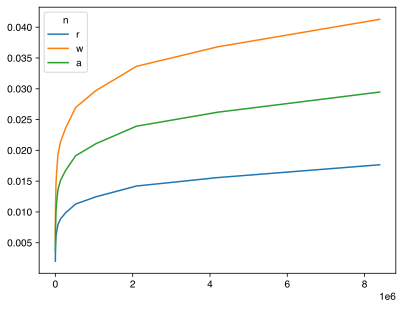

In [4]:
omix_data = pd.DataFrame(omixes).T.rename_axis('n', axis=1)
omix_data.plot()

In [5]:
data = pd.read_csv('data/all.csv')
data['nlg'] = data['n']
data['n'] = 2 ** data['n']
data['bslg'] = np.log2(data['bs']).astype(int)
data['total_size'] = data['n'] * data['bs']
data['total_size_lg'] = data['nlg'] + data['bslg']

In [6]:
data.columns

Index(['test', 'bs', 'n', 'alloc', 'init', 'init_accesses', 'init_bytes',
       'insert', 'insert_accesses', 'insert_bytes', 'search',
       'search_accesses', 'search_bytes', 'delete', 'delete_accesses',
       'delete_bytes', 'disk', 'max_mem_level', 'nlg', 'bslg', 'total_size',
       'total_size_lg'],
      dtype='object')

In [7]:
lw = 2.75
ms = 8

In [8]:
bss = [40, 160, 256, 4096]

In [9]:
def dfselect(df, col, val, drop=False):
  res = df[df[col] == val]
  return res.drop([col], axis=1) if drop else res

In [10]:
def ns(N):
  ns = []
  x = 256
  while x <= N:
    ns.append(x)
    x *= 2
  ns += [(ns[i] + ns[i+1]) // 2 for i in range(len(ns) - 1)]
  ns += [(min(ns) // 2) + 4]  # 4: to make the nextp2 512; to match naiver
  ns.sort()
  return ns

In [11]:
soram = {}
tmp = dfselect(dfselect(data, 'test', 'soram', True), 'disk', 0, True)
rbs = list(sorted(set(tmp['bs'])))
soram[rbs[0]] = dfselect(tmp, 'bs', rbs[0])
soram[rbs[1]] = dfselect(tmp, 'bs', rbs[1])
soram[rbs[2]] = dfselect(tmp, 'bs', rbs[2])
soram[rbs[3]] = dfselect(tmp, 'bs', rbs[3])

somap_ram = {}
tmp = dfselect(dfselect(data, 'test', 'somap', True), 'disk', 0, True)
mbs = list(sorted(set(tmp['bs'])))
somap_ram[mbs[0]] = dfselect(tmp, 'bs', mbs[0])
somap_ram[mbs[1]] = dfselect(tmp, 'bs', mbs[1])
somap_ram[mbs[2]] = dfselect(tmp, 'bs', mbs[2])
somap_ram[mbs[3]] = dfselect(tmp, 'bs', mbs[3])

somap_disk = {}
tmp = dfselect(dfselect(data, 'test', 'somap', True), 'disk', 1, True)
somap_disk[mbs[0]] = dfselect(tmp, 'bs', mbs[0])
somap_disk[mbs[1]] = dfselect(tmp, 'bs', mbs[1])
somap_disk[mbs[2]] = dfselect(tmp, 'bs', mbs[2])
somap_disk[mbs[3]] = dfselect(tmp, 'bs', mbs[3])

soheap = {}
tmp = dfselect(dfselect(data, 'test', 'soheap', True), 'disk', 0, True)
hbs = list(sorted(set(tmp['bs'])))
soheap[hbs[0]] = dfselect(tmp, 'bs', hbs[0])
soheap[hbs[1]] = dfselect(tmp, 'bs', hbs[1])
soheap[hbs[2]] = dfselect(tmp, 'bs', hbs[2])
soheap[hbs[3]] = dfselect(tmp, 'bs', hbs[3])

sostack = {}
tmp = dfselect(dfselect(data, 'test', 'sostack', True), 'disk', 0, True)
sbs = list(sorted(set(tmp['bs'])))
sostack[sbs[0]] = dfselect(tmp, 'bs', sbs[0])
sostack[sbs[1]] = dfselect(tmp, 'bs', sbs[1])
sostack[sbs[2]] = dfselect(tmp, 'bs', sbs[2])
sostack[sbs[3]] = dfselect(tmp, 'bs', sbs[3])

In [12]:
doram = {}
tmp = dfselect(dfselect(data, 'test', 'doram', True), 'disk', 0, True)
doram[rbs[0]] = dfselect(tmp, 'bs', rbs[0])
doram[rbs[1]] = dfselect(tmp, 'bs', rbs[1])
doram[rbs[2]] = dfselect(tmp, 'bs', rbs[2])
doram[rbs[3]] = dfselect(tmp, 'bs', rbs[3])

domap_ram = {}
tmp = dfselect(dfselect(data, 'test', 'domap', True), 'disk', 0, True)
domap_ram[mbs[0]] = dfselect(tmp, 'bs', mbs[0])
domap_ram[mbs[1]] = dfselect(tmp, 'bs', mbs[1])
domap_ram[mbs[2]] = dfselect(tmp, 'bs', mbs[2])
domap_ram[mbs[3]] = dfselect(tmp, 'bs', mbs[3])

domap_disk = {}
tmp = dfselect(dfselect(data, 'test', 'domap', True), 'disk', 1, True)
domap_disk[mbs[0]] = dfselect(tmp, 'bs', mbs[0])
domap_disk[mbs[1]] = dfselect(tmp, 'bs', mbs[1])
domap_disk[mbs[2]] = dfselect(tmp, 'bs', mbs[2])
domap_disk[mbs[3]] = dfselect(tmp, 'bs', mbs[3])

doheap = {}
tmp = dfselect(dfselect(data, 'test', 'doheap', True), 'disk', 0, True)
doheap[hbs[0]] = dfselect(tmp, 'bs', hbs[0])
doheap[hbs[1]] = dfselect(tmp, 'bs', hbs[1])
doheap[hbs[2]] = dfselect(tmp, 'bs', hbs[2])
doheap[hbs[3]] = dfselect(tmp, 'bs', hbs[3])

pstack = {}
tmp = dfselect(dfselect(data, 'test', 'pstack', True), 'disk', 0, True)
pstack[sbs[0]] = dfselect(tmp, 'bs', sbs[0])
pstack[sbs[1]] = dfselect(tmp, 'bs', sbs[1])
pstack[sbs[2]] = dfselect(tmp, 'bs', sbs[2])
pstack[sbs[3]] = dfselect(tmp, 'bs', sbs[3])

In [13]:
# Adjust omap delete costs (shrink not accounted for)
for df_group in [domap_ram, domap_disk]:
  for bs, df in df_group.items():
    for col in filter(lambda x: x.startswith('delete'), df.columns):
      df[col] *= 3

for df_group in [doram, doheap]:
  for bs, df in df_group.items():
    for col in filter(lambda x: x.startswith('delete'), df.columns):
      df[col] *= 2

In [14]:
alln = np.arange(4, (2**28)+1, 4, dtype=np.uint64)
np2_arr = (2 ** (np.ceil(np.log2(alln)))).astype(np.uint64)

naiver = pd.DataFrame(alln, columns=['n'])
naiver['nextp2'] = np2_arr
p2s = naiver['n'] == naiver['nextp2']
naiver['nisp2'] = 0
naiver['nisp2'][p2s] = 1

naiver.head()

/var/folders/nv/47mhk4rx3xg9zhjpwhjbj2lr0000gn/T/ipykernel_3531/3306160878.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  naiver['nisp2'][p2s] = 1
/var/folders/nv/47mhk4rx3xg9zhjpwhjbj2lr0000gn/T/ipykernel_3531/3306160878.py:8: SettingW

,n,nextp2,nisp2
0,4,4,1
1,8,8,1
2,12,16,0
3,16,16,1
4,20,32,0


In [15]:
def grow_naive_ram(df):
  df_copy = df.copy(deep=True).drop(columns=['total_size_lg'])

  res = (pd.merge(naiver, df_copy, left_on='nextp2', right_on='n', suffixes=(None, '_tmp'))
         .drop(columns=['n_tmp']))

  for op in ('insert',
             'delete'):
    for col in filter(lambda x: x.startswith(op), res.columns):
      # 1.5 for download of prev oram and upload of new one.
      # + (res['n'] * res[col])))
      res[col] = res[col] + (res['nisp2'] * 1.5 * res['init' + col[6:]])

  res['total_size'] = res['bs'] * res['n']

  return res


noram = {}
for bs in rbs:
  noram[bs] = grow_naive_ram(soram[bs])

# Compact: only po2s and points between them.
compactnoram = {}
for bs in rbs:
  # local ns
  lns = ns(max(soram[bs]['n']))
  nbs = noram[bs]
  compactnoram[bs] = nbs[nbs['n'].isin(lns)]

In [16]:
noram[rbs[0]].head()

,n,nextp2,nisp2,bs,alloc,init,init_accesses,init_bytes,insert,insert_accesses,...,search,search_accesses,search_bytes,delete,delete_accesses,delete_bytes,max_mem_level,nlg,bslg,total_size
0,4,4,1,32,1.195000e-07,0.000004,1,576,0.000011,3.5,...,0.000005,2,400,0.000011,3.5,1264.0,255,2,5,128.0
1,8,8,1,32,6.685000e-07,0.000009,1,1344,0.000019,3.5,...,0.000007,2,600,0.000020,3.5,2616.0,255,3,5,256.0
2,12,16,0,32,3.587500e-07,0.000020,1,2880,0.000007,2.0,...,0.000014,2,800,0.000010,2.0,800.0,255,4,5,384.0
3,16,16,1,32,3.587500e-07,0.000020,1,2880,0.000037,3.5,...,0.000014,2,800,0.000040,3.5,5120.0,255,4,5,512.0
4,20,32,0,32,7.300000e-07,0.000040,1,5952,0.000008,2.0,...,0.000009,2,1000,0.000009,2.0,1000.0,255,5,5,640.0


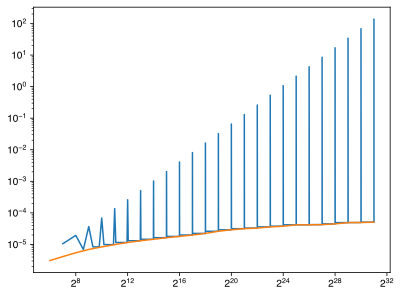

In [17]:
plt.plot(noram[rbs[0]]['total_size'], noram[rbs[0]]['insert'])
plt.plot(soram[rbs[0]]['total_size'], soram[rbs[0]]['insert'])
plt.xscale('log', base=2)
plt.yscale('log')
plt.show()

In [18]:
noram_grower = {}
for bs in noram:
  noram_grower[bs] = noram[bs][['n', 'nextp2', 'nisp2',
                                'alloc',
                                'init', 'init_accesses', 'init_bytes',
                                'total_size']]

In [19]:
def grow_naive_others(bsnoram, df):
  df_copy = df.copy(deep=True).drop(columns=['total_size_lg',
                                             'init', 'init_accesses', 'init_bytes'])

  res = (pd.merge(bsnoram, df_copy, left_on='nextp2', right_on='n', suffixes=(None, '_tmp'))
         .drop(columns=['n_tmp', 'total_size_tmp']))

  for col in filter(lambda x: any([x.startswith(c) for c in ('insert', 'delete')]), res.columns):
    # 1.5 for download of prev ods and upload of new one.
    res[col] = res[col] + (res['nisp2'] * 1.5 * res['init' + col[6:]])

  return res


nomap_ram = {}
nomap_disk = {}
noheap = {}
nostack = {}
for i in range(len(bss)):
  nomap_ram[mbs[i]] = grow_naive_others(
      noram_grower[rbs[i]], somap_ram[mbs[i]])
  nomap_disk[mbs[i]] = grow_naive_others(
      noram_grower[rbs[i]], somap_disk[mbs[i]])
  noheap[hbs[i]] = grow_naive_others(noram_grower[rbs[i]], soheap[hbs[i]])
  nostack[sbs[i]] = grow_naive_others(noram_grower[rbs[i]], sostack[sbs[i]])

In [20]:
def p2stk(m, M):
  print('here: ', m, M)
  p2 = 1 << int(np.ceil(np.log2(m)))
  res = []
  while p2 <= M:
    res += list(range(max(m, p2-4), p2+5, 4))
    res += [p2-1, p2, p2+1]
    p2 <<= 1
  # if res[0] < m:
  #   res = res[1:]
  return set(res)


for naivebatch in [noram, nomap_ram, nomap_disk, noheap, nostack]:
  for bs in naivebatch.keys():
    df = naivebatch[bs]
    nmin, nmax = df['n'].min(), df['n'].max()
    p = p2stk(nmin, nmax)
    df = df[df['n'].isin(p)]
    naivebatch[bs] = df


# for idx, bs in enumerate(mbs):
#   bs = mbs[idx]
#   df = nomap_ram[bs]

#   print(f'{idx=}')
#   print(df.size)
#   print(somap_ram[bs].size)
#   print(domap_ram[bs].size)
#   nnomaps[bs] = df
# nomap_ram = nnomaps

here:  4 67108864
here:  4 33554432
here:  4 16777216
here:  4 1048576
here:  4 67108864
here:  4 33554432
here:  4 16777216
here:  4 1048576
here:  4 8388608
here:  4 1048576
here:  4 1048576
here:  4 1048576
here:  4 67108864
here:  4 16777216
here:  4 8388608
here:  4 524288
here:  4 67108864
here:  4 33554432
here:  4 8388608
here:  4 1048576


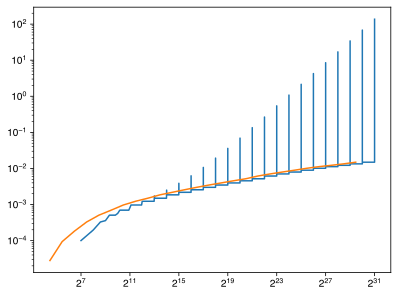

In [21]:
plt.plot(nomap_ram[mbs[0]]['total_size'], nomap_ram[mbs[0]]['delete'])
plt.plot(somap_ram[mbs[0]]['total_size'], somap_ram[mbs[0]]['delete'])
plt.xscale('log', base=2)
plt.yscale('log')
plt.show()

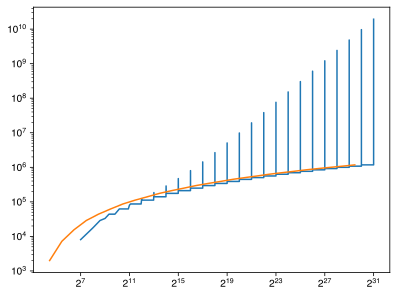

In [22]:
plt.plot(nomap_ram[mbs[0]]['total_size'], nomap_ram[mbs[0]]['delete_bytes'])
plt.plot(somap_ram[mbs[0]]['total_size'], somap_ram[mbs[0]]['delete_bytes'])
plt.xscale('log', base=2)
plt.yscale('log')
plt.show()

In [23]:
# def grow_naive_others(bsnoram, df):
#     df_copy = df.copy(deep=True).drop(columns=['total_size_lg',
#                                                'init', 'init_accesses', 'init_bytes',
#                                                'search', 'search_accesses', 'search_bytes',
#                                                'delete', 'delete_accesses', 'delete_bytes'])

#     res = (pd.merge(bsnoram, df_copy, left_on='nextp2', right_on='n', suffixes=(None, '_tmp'))
#            .drop(columns=['n_tmp', 'total_size_tmp']))

#     for col in filter(lambda x: x.startswith('insert'), res.columns):
#         # 1.5 for download of prev ods and upload of new one.
#         res[col] = res[col] + (res['nisp2'] * 1.5 * res['init' + col[6:]])# + (res['n'] * res[col])))

#     return res

# nomap_ram = {}
# nomap_disk = {}
# noheap = {}
# nostack = {}
# for i in range(0, 4):
#     nomap_ram[mbs[i]] = grow_naive_others(noram_grower[rbs[i]], somap_ram[mbs[i]])
#     nomap_disk[mbs[i]] = grow_naive_others(noram_grower[rbs[i]], somap_disk[mbs[i]])
#     noheap[hbs[i]] = grow_naive_others(noram_grower[rbs[i]], soheap[hbs[i]])
#     nostack[sbs[i]] = grow_naive_others(noram_grower[rbs[i]], sostack[sbs[i]])

In [24]:
nomap_ram[mbs[0]].head()

,n,nextp2,nisp2,alloc,init,init_accesses,init_bytes,total_size,bs,alloc_tmp,...,insert_bytes,search,search_accesses,search_bytes,delete,delete_accesses,delete_bytes,max_mem_level,nlg,bslg
0,4,4,1,1.195000e-07,0.000004,1,576,128.0,11,1.652500e-07,...,8064.0,0.000095,36,7200,0.000100,37.5,8064.0,255,2,3
1,8,8,1,6.685000e-07,0.000009,1,1344,256.0,11,8.127500e-07,...,17616.0,0.000190,52,15600,0.000197,53.5,17616.0,255,3,3
2,12,16,0,3.587500e-07,0.000020,1,2880,384.0,11,7.585000e-07,...,28800.0,0.000338,72,28800,0.000329,72.0,28800.0,255,4,3
3,16,16,1,3.587500e-07,0.000020,1,2880,512.0,11,7.585000e-07,...,33120.0,0.000338,72,28800,0.000358,73.5,33120.0,255,4,3
4,20,32,0,7.300000e-07,0.000040,1,5952,640.0,11,1.073750e-06,...,44000.0,0.000495,88,44000,0.000507,88.0,44000.0,255,5,3


In [25]:
for bs in mbs:
  ds = nomap_ram[bs]
  for c in [c for c in ds.columns if c.endswith('bytes')]:
    print(bs, c, np.log2(ds['n'].iat[-1]), np.log10(ds[c].iat[-1]))
  # for c in
  # print(bs, ['insert_bytes'])

11 init_bytes 26.0 10.11008110949557
11 insert_bytes 26.0 10.28619877503179
11 search_bytes 26.0 6.0701117827822
11 delete_bytes 26.0 10.28619877503179
131 init_bytes 25.0 10.35311915171037
131 insert_bytes 25.0 10.529257557650539
131 search_bytes 25.0 6.564902672529205
131 delete_bytes 25.0 10.529257557650539
227 init_bytes 24.0 10.248383788247374
227 insert_bytes 24.0 10.424561839777786
227 search_bytes 24.0 6.725216204633397
227 delete_bytes 24.0 10.424561839777786
4067 init_bytes 20.0 10.235866842535655
4067 insert_bytes 20.0 10.412918395457007
4067 search_bytes 20.0 7.757058180309117
4067 delete_bytes 20.0 10.412918395457007


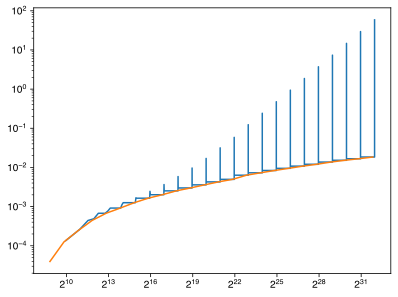

In [26]:
plt.plot(nomap_ram[mbs[2]]['total_size'], nomap_ram[mbs[2]]['insert'])
plt.plot(somap_ram[mbs[2]]['total_size'], somap_ram[mbs[2]]['insert'])
plt.xscale('log', base=2)
plt.yscale('log')
plt.show()

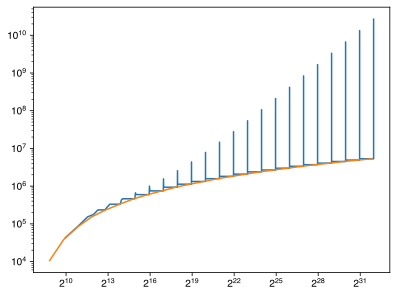

In [27]:
plt.plot(nomap_ram[mbs[2]]['total_size'], nomap_ram[mbs[2]]['insert_bytes'])
plt.plot(somap_ram[mbs[2]]['total_size'], somap_ram[mbs[2]]['insert_bytes'])
plt.xscale('log', base=2)
plt.yscale('log')
plt.show()

In [28]:
def simple_grow(df):
  df_copy = df.copy(deep=True)
  return (pd.merge(naiver, df_copy, left_on='nextp2', right_on='n', suffixes=('', '_tmp'))
          .drop(columns=['n_tmp']))

In [29]:
cutoff = 1 << 7


def gte_cutoff(df, v=cutoff):
  return df[df['n'] >= v]


def lte_cutoff(df, v):
  return df[df['n'] <= v]

# USENIX 24 / ICDE 24

## Non-SGX

#### Utils

In [30]:
# SET THESE:
rtt = 0  # IN SECONDS! 0.1 = 100ms; 100 = 100s!
nbw = 10E9


def netsimcol(df, col, printem=False):
  # print(f'{nbw=}')
  # print(f'{rtt=}')
  df = df.copy(deep=True)
  colb = col + '_bytes'
  cola = col + '_accesses'
  if colb not in df.columns or cola not in df.columns:
    raise Exception(f'({col=}) {colb} or {cola} not found in {df.columns}')
  df['rawtmp'] = df[col]
  df['btmp'] = df[colb] / nbw  # time to transmit
  df['atmp'] = rtt * df[cola]
  # print(df['atmp'])
  df[col] += df['btmp'] + df['atmp']  # sum
  if printem:
    print(df[[col, 'rawtmp', 'btmp', 'atmp']])
  df = df.drop(columns=['rawtmp', 'btmp', 'atmp'])
  return df


def netsimcols(df, cols):
  for col in cols:
    df = netsimcol(df, col)
  return df

### Throughputs

In [31]:
nbw = 1E16  # Network bandwidth -- infty

In [32]:
bs = mbs[0]
N = min([df['n'].max()
         for df in (nomap_ram[bs], somap_ram[bs], domap_ram[bs])])
N = int(N)
lns = ns(N)
tokeep = [-1]
opcount = 100
for n in lns:
  tokeep += list(range(max(0, n-opcount),
                       min(N+1, n+opcount+1)))
tokeep = set(tokeep)

actnames = ['insert', 'delete', 'search']
acts = list('ids')
sizediffs = [1, -1, 0]


def netexpand(df):
  df = df[df['n'].isin(tokeep)]
  return netsimcols(df, actnames).to_dict(orient='records')


def selrows(df, col, minv):
  return [r for r in df if r[col] >= minv]


def minrow(df, col, minn):
  return min(selrows(df, 'n', minn), key=lambda r: r['n'])[col]


class SimNonSgxs:
  def __init__(self, df, tocount='i') -> None:
    self.n = 0
    self.res = {}
    self.df = df
    self.tocount = tocount

  def __do_action(self, act: str) -> None:
    if len(act) != 1:
      raise Exception(f'Bad action size: {act}')
    if act not in acts:
      raise Exception(f'Bad action type: {act}')

    actname = actnames[acts.index(act)]
    return minrow(self.df, actname, self.n)

  def do(self, pattern: str, reps: int):
    for n in lns:
      self.n = n
      took = reps_done = 0
      for _ in range(reps):
        for act in pattern:
          if self.n == N and act == 'i':
            break
          took += self.__do_action(act)
          if act == self.tocount:
            reps_done += 1
          self.n += sizediffs[acts.index(act)]
      if reps_done == 0 or took == 0:
        continue
      throughput = reps_done / took
      self.res[n] = throughput

    return self.res


def plotrun(group: str, runs, naiveruns, sgx=False) -> None:
  print(group)
  _, ax1 = plt.subplots(figsize=(8, 3))

  l = [x for x in runs.items() if len(x[1])]
  for op, run in l:
    x, y = zip(*sorted(run.items()))
    # label = 'Dyno' + ('' if len(l) == 1 else f' - {op}')
    label = f'Dyno - {op}'
    lc = 'g'
    marker = '' if op.lower() == 'insert' else '*'
    ax1.plot(x, y, label=label, lw=1.5, color=lc, marker=marker)

  l = [x for x in naiveruns.items() if len(x[1])]
  for op, naiverun in l:
    xn, yn = zip(*sorted(naiverun.items()))
    # label = 'Naive' + ('' if len(l) == 1 else f' - {op}')
    label = f'Naive - {op}'
    lc = 'r'
    marker = '' if op.lower() == 'insert' else '*'
    ax1.plot(xn, yn, label=label, lw=1.5, color=lc, marker=marker)

  ax1.set_xlabel(f'$n_i$', fontsize=14, labelpad=5)
  ax1.set_ylabel('Throughput', fontsize=11, labelpad=10)
  # ax1.set_title(group)
  ax1.tick_params(axis='x', which='both', labelsize=12)
  ax1.tick_params(axis='y', which='both', labelsize=11)
  ax1.set_xscale('log', base=2)
  ax1.set_yscale('log')
  ax1.grid()
  ax1.legend(loc='lower left', fontsize=12)
  plt.tight_layout()
  plt.savefig(
      f'plots_usenix/{group.replace(":", "-").replace(" ", "")}_{"no" if not sgx else ""}sgx.eps', bbox_inches='tight')
  plt.show()

In [33]:
import itertools

bs = mbs[0]
fontsize = 20.5
largefont = 30
lw = 2.5
largelw = 4
opcount = 101
legendalpha = .5
lss = {
    '0:1': '-',
    '1:0': (5, (10, 3)),
    '1:1': '--',
    '1:4': '-.',
    f'1:{opcount-1}': ':',
}
default_ls = '--'
lcs = {
    'Naive': '#FF6666',
    'Dyno': 'g',
    # 'Ideal': 'b',
}
patterns = ['s', 'i', 'is', 'issss', 'i'+((opcount-1)*'s')]
schemes = ['Naive', 'Dyno']
# ndf = netexpand(nomap_ram[bs])
# sdf = netexpand(somap_ram[bs])
# ddf = netexpand(domap_ram[bs])
sims = {
    'Naive': lambda op: SimNonSgxs(netexpand(nomap_ram[bs]), op),
    'Dyno': lambda op: SimNonSgxs(netexpand(domap_ram[bs]), op),
}
ops = list('is')
figsize = (10, 8)
opnames = {'i': 'Insert', 's': 'Search'}
markers = {
    'Naive': '',
    'Dyno': '',
}


def plotruns(name, runs):
  miny = 100.
  maxy = 0.
  _, ax = plt.subplots(figsize=figsize)
  # lens = {len(run) for run in runs.values()}
  # if len(lens) != 1:
  # print(runs)
  # raise Exception(f'bad runs: {lens}')
  for group, run in runs.items():
    scheme = group.split()[0]
    ratio = group.split()[-1]
    x, y = zip(*sorted(run.items()))
    miny = float(min(miny, min(y)))
    maxy = float(max(maxy, max(y)))
    if x[-1] == N:
      x, y = x[:-1], y[:-1]
    lc = lcs[scheme]
    marker = markers[scheme]
    ls = lss.get(ratio, default_ls)
    ax.plot(x, y, label=group, lw=lw if ls != ':' else largelw,
            color=lc, linestyle=ls, marker=marker)
    # print(f'{scheme=}, {ratio=}, min={min(y):.3f}, max={max(y):.3f}')
    # if ratio == '1:0':
    #   print(y)

  ax.set_xlabel(f'$n_i$',                           fontsize=largefont)
  ax.set_ylabel(f'{name} Throughput (op / second)', fontsize=largefont)
  ax.tick_params(axis='x', which='both',           labelsize=largefont)
  ax.tick_params(axis='y', which='both',           labelsize=largefont)
  # xticks = [2**x for x in range(6, 23, 3)]
  # xlims = (2**6, 2**23)
  # ylims = ax.get_ylim()
  # print(ylims)
  # ax.set_ylim((miny/10, 2*maxy))
  # ax.set_xticks(xticks)
  # ax.set_xlim((xticks[0], xticks[-1]))
  # ax.set_xlim(xlims)
  ax.set_xscale('log', base=2)
  ax.set_yscale('log', base=10)
  ax.legend(loc='lower left', fontsize=fontsize, ncols=2)
  plt.tight_layout()
  fname = f'plots_usenix/{name.lower()}_tput_{int(rtt * 1000)}ms.eps'
  plt.savefig(fname, bbox_inches='tight')
  print(fname)
  plt.show()


def stats(runs):
  mains = 'Dyno'
  run_dfs = {g: pd.DataFrame(
      r, index=('n', 'tput')).T for g, r in runs.items()}
  ratios = {g.split()[-1] for g in runs}
  todiv = {s for s in schemes if s != mains}
  for s, r in itertools.product(todiv, ratios):
    bymains = run_dfs[f'{s} - {r}']['tput'] / run_dfs[f'{mains} - {r}']['tput']
    mainsby = 1 / bymains
    print(f'{s=}, {r=}, by {mains}: {bymains.min()}-{bymains.mean()}-{bymains.max()} --- '
          f'{mains} by: {mainsby.min()}-{mainsby.mean()}-{mainsby.max()}')

Insert
s='Naive', r='1:100', by Dyno: 0.047959961491990326-1.9051696657965431-2.4956282374825647 --- Dyno by: 0.40070070733321167-1.6550261440551837-20.850725665553494
s='Naive', r='1:4', by Dyno: 0.0568712080307288-2.2738873329264386-2.9629141529882044 --- Dyno by: 0.33750555985277686-1.3927108353171347-17.583589915299097
s='Naive', r='1:0', by Dyno: 0.09725860701790444-3.847788091660135-5.047672704262469 --- Dyno by: 0.19811110160838233-0.8163849177279491-10.281866362901013
s='Naive', r='1:1', by Dyno: 0.07166589099373254-2.86023885389464-3.7216553701148696 --- Dyno by: 0.2686976360116694-1.1053585486911195-13.953639397122041


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


plots_usenix/insert_tput_0ms.eps


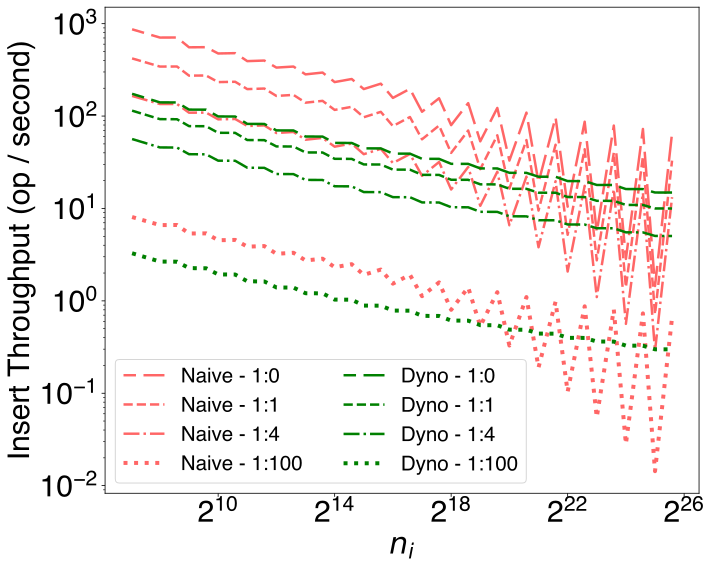

Search
s='Naive', r='1:100', by Dyno: 0.04795996149199031-1.9051696657965431-2.4956282374825642 --- Dyno by: 0.4007007073332117-1.6550261440551841-20.8507256655535
s='Naive', r='0:1', by Dyno: 2.1752481006466637-2.3149570289163885-2.471569158331611 --- Dyno by: 0.40460126176482647-0.4327099613213464-0.4597176752861971
s='Naive', r='1:4', by Dyno: 0.0568712080307288-2.2738873329264386-2.9629141529882044 --- Dyno by: 0.33750555985277686-1.3927108353171347-17.583589915299097
s='Naive', r='1:1', by Dyno: 0.07166589099373254-2.86023885389464-3.7216553701148696 --- Dyno by: 0.2686976360116694-1.1053585486911195-13.953639397122041


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


plots_usenix/search_tput_0ms.eps


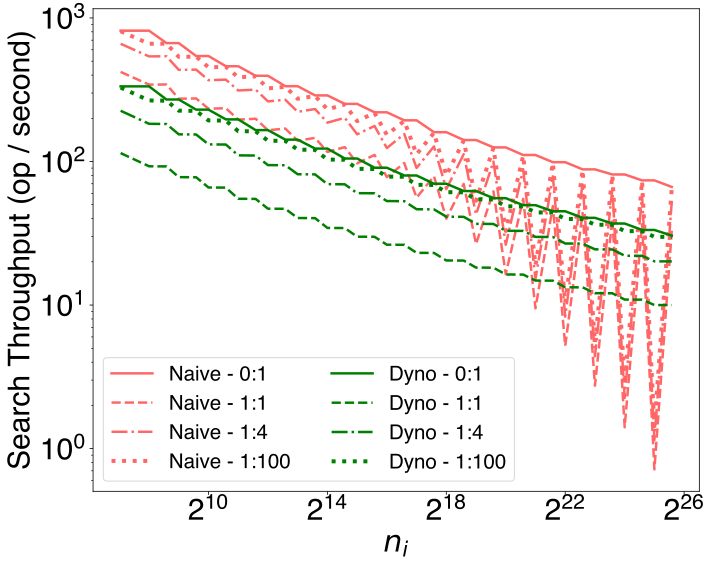

Insert
s='Naive', r='1:100', by Dyno: 1.9456825081994347-2.141334894327143-2.278854887988777 --- Dyno by: 0.43881688354564713-0.4674170457488545-0.5139584674199573
s='Naive', r='1:4', by Dyno: 2.310583744150662-2.5445497325191715-2.707813288297375 --- Dyno by: 0.3693016812945704-0.39335150016449794-0.4327910652585267
s='Naive', r='1:0', by Dyno: 3.8545494575066823-4.241928357340945-4.513062300658915 --- Dyno by: 0.22157903733214546-0.23595379605690742-0.25943369284119927
s='Naive', r='1:1', by Dyno: 2.8885761385682653-3.18100840924886-3.3847723737128503 --- Dyno by: 0.29544084197989134-0.31464969643296603-0.3461913247319332


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


plots_usenix/insert_tput_20ms.eps


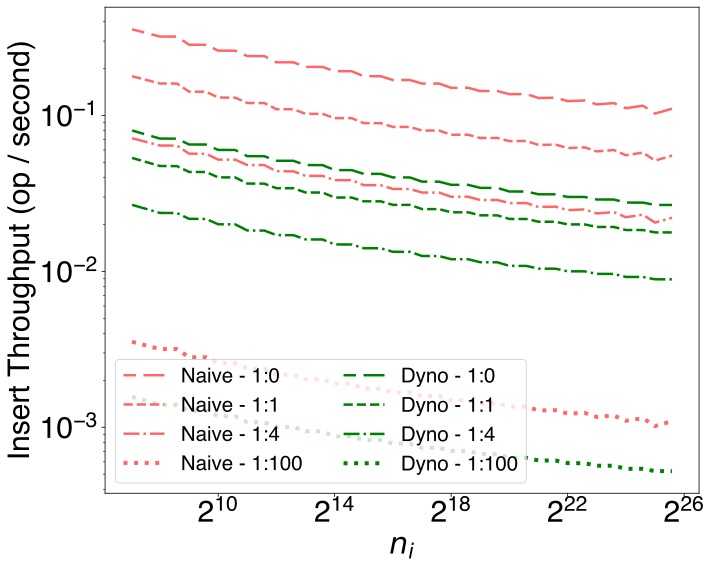

Search
s='Naive', r='1:100', by Dyno: 1.9456825081994344-2.141334894327143-2.278854887988777 --- Dyno by: 0.43881688354564713-0.4674170457488545-0.5139584674199574
s='Naive', r='0:1', by Dyno: 2.0709828648560813-2.1319285992812076-2.256513427330326 --- Dyno by: 0.4431615552951072-0.46932628873576515-0.482862517585095
s='Naive', r='1:4', by Dyno: 2.310583744150662-2.5445497325191715-2.707813288297375 --- Dyno by: 0.3693016812945704-0.39335150016449794-0.4327910652585267
s='Naive', r='1:1', by Dyno: 2.8885761385682653-3.18100840924886-3.3847723737128503 --- Dyno by: 0.29544084197989134-0.31464969643296603-0.3461913247319332


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


plots_usenix/search_tput_20ms.eps


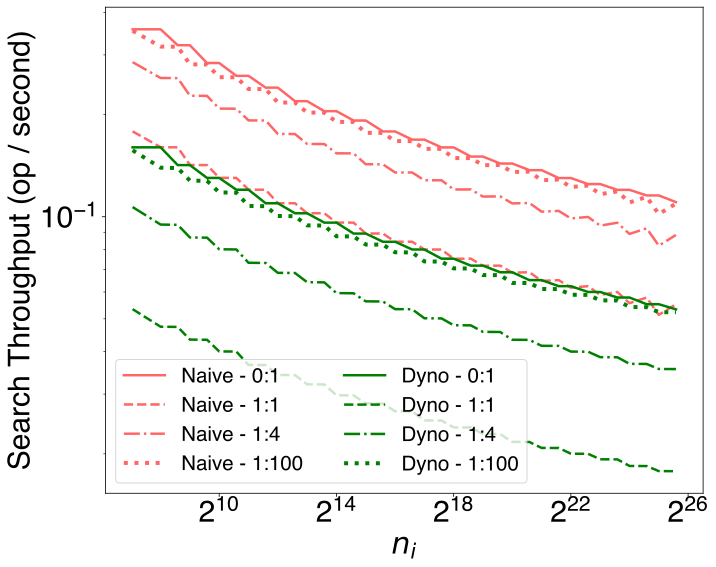

In [50]:
rtt = 0.00
for rtt in (0., 0.02):
  for op in ops:
    filtered_patterns = filter(lambda p: op in p, patterns)
    opname = opnames[op]
    print(opname)
    runs = {
        f'{scheme} - {pattern.count("i")}:{pattern.count("s")}':
        sims[scheme](op).do(pattern, opcount // len(pattern))

        for scheme, pattern in itertools.product(schemes, filtered_patterns)
    }
    stats(runs)
    plotruns(opname, runs)

In [51]:
import itertools

bs = rbs[0]
fontsize = 20.5
largefont = 30
lw = 2.5
largelw = 4
opcount = 101
legendalpha = .5
lss = {
    '0:1': '-',
    '1:0': (5, (10, 3)),
    '1:1': '--',
    '1:4': '-.',
    f'1:{opcount-1}': ':',
}
default_ls = '--'
lcs = {
    'Naive': '#FF6666',
    'Dyno': 'g',
    # 'Ideal': 'b',
}
patterns = ['s', 'i', 'is', 'issss', 'i'+((opcount-1)*'s')]
schemes = ['Naive', 'Dyno']
# ndf = netexpand(nomap_ram[bs])
# sdf = netexpand(somap_ram[bs])
# ddf = netexpand(domap_ram[bs])
sims = {
    'Naive': lambda op: SimNonSgxs(netexpand(noram[bs]), op),
    'Dyno': lambda op: SimNonSgxs(netexpand(doram[bs]), op),
}
ops = list('is')
figsize = (10, 8)
opnames = {'i': 'Insert', 's': 'Search'}
markers = {
    'Naive': '',
    'Dyno': '',
}


def plotruns(name, runs):
  miny = 100.
  maxy = 0.
  _, ax = plt.subplots(figsize=figsize)
  # lens = {len(run) for run in runs.values()}
  # if len(lens) != 1:
  # print(runs)
  # raise Exception(f'bad runs: {lens}')
  for group, run in runs.items():
    scheme = group.split()[0]
    ratio = group.split()[-1]
    x, y = zip(*sorted(run.items()))
    miny = float(min(miny, min(y)))
    maxy = float(max(maxy, max(y)))
    if x[-1] == N:
      x, y = x[:-1], y[:-1]
    lc = lcs[scheme]
    marker = markers[scheme]
    ls = lss.get(ratio, default_ls)
    ax.plot(x, y, label=group, lw=lw if ls != ':' else largelw,
            color=lc, linestyle=ls, marker=marker)
    # print(f'{scheme=}, {ratio=}, min={min(y):.3f}, max={max(y):.3f}')
    # if ratio == '1:0':
    #   print(y)

  ax.set_xlabel(f'$n_i$',                           fontsize=largefont)
  ax.set_ylabel(f'{name} Throughput (op / second)', fontsize=largefont)
  ax.tick_params(axis='x', which='both',           labelsize=largefont)
  ax.tick_params(axis='y', which='both',           labelsize=largefont)
  # xticks = [2**x for x in range(6, 23, 3)]
  # xlims = (2**6, 2**23)
  # ylims = ax.get_ylim()
  # print(ylims)
  # ax.set_ylim((miny/10, 2*maxy))
  # ax.set_xticks(xticks)
  # ax.set_xlim((xticks[0], xticks[-1]))
  # ax.set_xlim(xlims)
  ax.set_xscale('log', base=2)
  ax.set_yscale('log', base=10)
  ax.legend(loc='lower left', fontsize=fontsize, ncols=2)
  plt.tight_layout()
  fname = f'plots_usenix/oram_{name.lower()}_tput_{int(rtt * 1000)}ms.eps'
  plt.savefig(fname, bbox_inches='tight')
  print(fname)
  plt.show()


def stats(runs):
  mains = 'Dyno'
  run_dfs = {g: pd.DataFrame(
      r, index=('n', 'tput')).T for g, r in runs.items()}
  ratios = {g.split()[-1] for g in runs}
  todiv = {s for s in schemes if s != mains}
  for s, r in itertools.product(todiv, ratios):
    bymains = run_dfs[f'{s} - {r}']['tput'] / run_dfs[f'{mains} - {r}']['tput']
    mainsby = 1 / bymains
    print(f'{s=}, {r=}, by {mains}: {bymains.min()}-{bymains.mean()}-{bymains.max()} --- '
          f'{mains} by: {mainsby.min()}-{mainsby.mean()}-{mainsby.max()}')

Insert
s='Naive', r='1:100', by Dyno: 0.00019625535483464804-1.5407066307435606-2.7739126244922594 --- Dyno by: 0.36050162185012635-288.53005600774003-5095.402369237439
s='Naive', r='1:4', by Dyno: 0.00023624920404830905-1.850476628271976-3.3710307895396343 --- Dyno by: 0.29664516951403025-239.9721722638512-4232.818493625556
s='Naive', r='1:0', by Dyno: 0.00041687406652437875-3.143011440534136-5.89966553293335 --- Dyno by: 0.16950113433003275-136.36852538443634-2398.8059711589667
s='Naive', r='1:1', by Dyno: 0.0003024349191695554-2.3372352032096826-4.279701634820626 --- Dyno by: 0.2336611486800324-187.70691392267273-3306.49649433955


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


plots_usenix/oram_insert_tput_0ms.eps


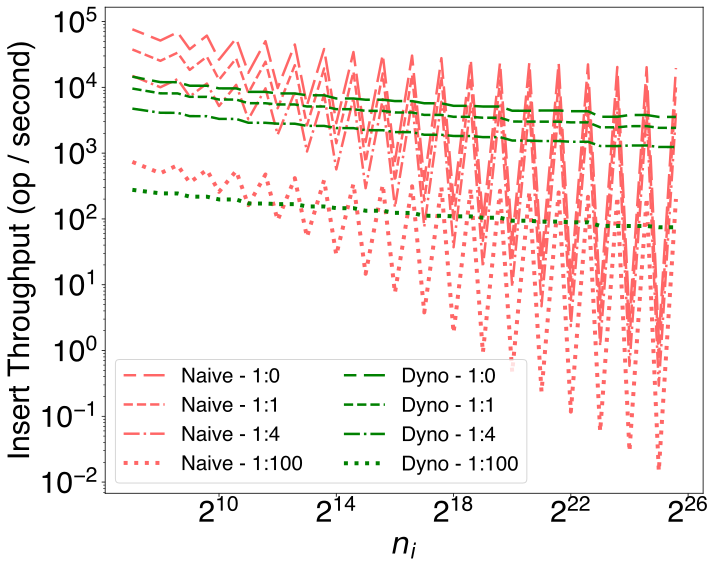

Search
s='Naive', r='1:100', by Dyno: 0.00019625535483464804-1.5407066307435606-2.7739126244922594 --- Dyno by: 0.36050162185012635-288.53005600774003-5095.402369237439
s='Naive', r='0:1', by Dyno: 2.3267743477437652-2.5912716540617438-2.7430194301605044 --- Dyno by: 0.36456176321780054-0.38677790035000087-0.42977953619339304
s='Naive', r='1:4', by Dyno: 0.00023624920404830905-1.850476628271976-3.3710307895396343 --- Dyno by: 0.29664516951403025-239.9721722638512-4232.818493625556
s='Naive', r='1:1', by Dyno: 0.0003024349191695554-2.3372352032096826-4.279701634820626 --- Dyno by: 0.2336611486800324-187.70691392267273-3306.49649433955


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


plots_usenix/oram_search_tput_0ms.eps


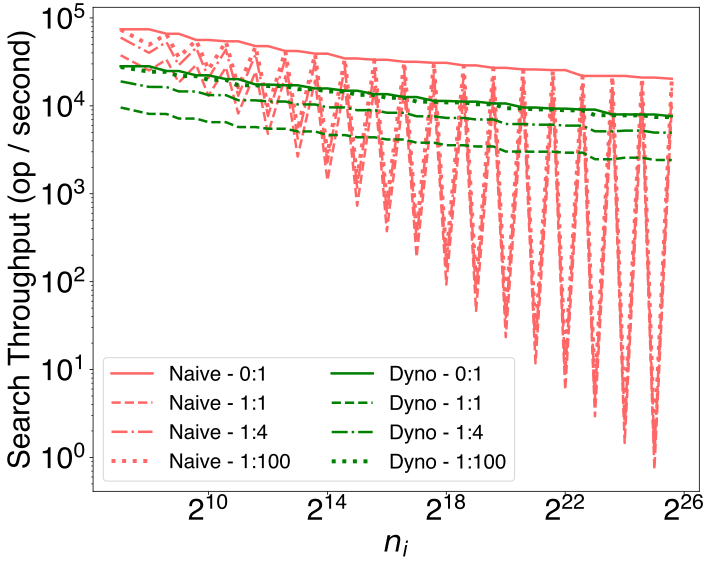

Insert
s='Naive', r='1:100', by Dyno: 0.11301492961248318-1.7625951394278014-2.0206627038450358 --- Dyno by: 0.4948871467252507-0.9476149952852071-8.84838846892972
s='Naive', r='1:4', by Dyno: 0.1330374122169439-2.093456870252871-2.401124215327141 --- Dyno by: 0.4164715817768533-0.8012885705629504-7.516682588273
s='Naive', r='1:0', by Dyno: 0.2238399817574339-3.490715971136744-4.002096345307345 --- Dyno by: 0.24986904704894203-0.4784673506518719-4.467477133212325
s='Naive', r='1:1', by Dyno: 0.16630337503840312-2.6168455666642014-3.001514656377995 --- Dyno by: 0.3331651231071201-0.641016162153887-6.01310706874757


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


plots_usenix/oram_insert_tput_20ms.eps


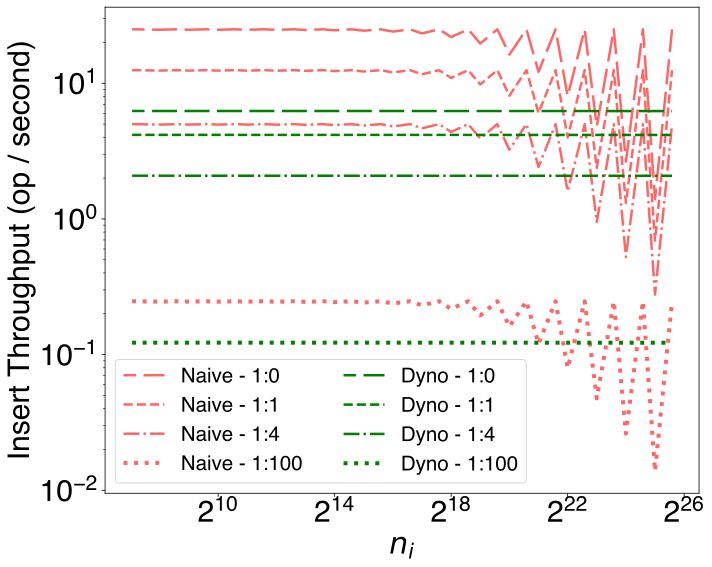

Search
s='Naive', r='1:100', by Dyno: 0.11301492961248316-1.7625951394278014-2.0206627038450358 --- Dyno by: 0.4948871467252507-0.9476149952852071-8.84838846892972
s='Naive', r='0:1', by Dyno: 2.000213183240852-2.0004659113675927-2.000846658265423 --- Dyno by: 0.49978842499950565-0.4998835546202132-0.49994670987006834
s='Naive', r='1:4', by Dyno: 0.1330374122169439-2.093456870252871-2.401124215327141 --- Dyno by: 0.4164715817768533-0.8012885705629504-7.516682588273
s='Naive', r='1:1', by Dyno: 0.16630337503840312-2.6168455666642014-3.001514656377995 --- Dyno by: 0.3331651231071201-0.641016162153887-6.01310706874757


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


plots_usenix/oram_search_tput_20ms.eps


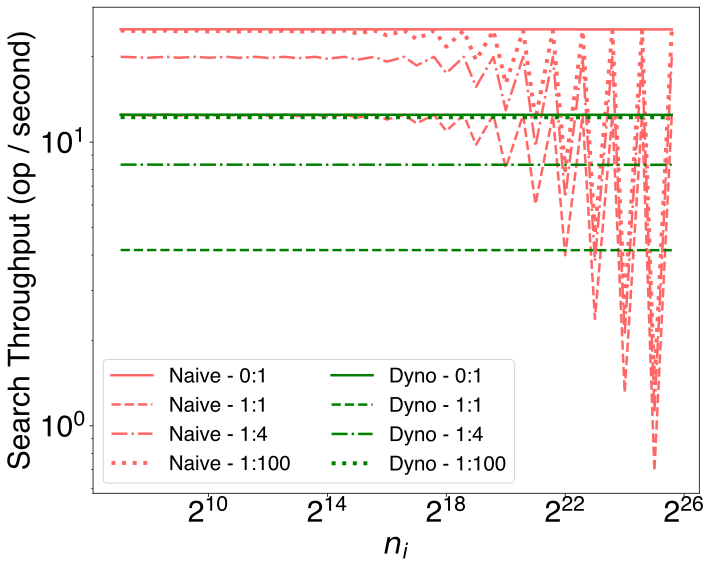

In [52]:
rtt = 0.00
for rtt in (0., 0.02):
  for op in ops:
    filtered_patterns = filter(lambda p: op in p, patterns)
    opname = opnames[op]
    print(opname)
    runs = {
        f'{scheme} - {pattern.count("i")}:{pattern.count("s")}':
        sims[scheme](op).do(pattern, opcount // len(pattern))

        for scheme, pattern in itertools.product(schemes, filtered_patterns)
    }
    stats(runs)
    plotruns(opname, runs)

### Latencies

#### Same Machine (0ms RTT):

In [34]:
rtt = 0  # Round-trip time
nbw = 1E16  # Network bandwidth -- infty

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


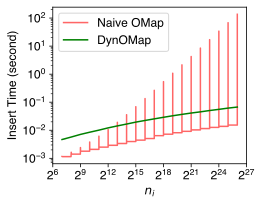

In [35]:
fig, ax1 = plt.subplots(figsize=(3.75, 3))
show_bw = False
bs = mbs[0]
lw = 1.5
ls, ms = '-', ''

ndf = netsimcol(nomap_ram[bs], 'insert')
ax1.plot(gte_cutoff(ndf)['n'],
         gte_cutoff(ndf)['insert'],
         label=f'Naive OMap', linestyle=ls,
         marker=ms, color='#FF6666', lw=lw)

ddf = netsimcol(domap_ram[bs], 'insert')
ax1.plot(gte_cutoff(ddf)['n'],
         gte_cutoff(ddf)['insert'],
         label=f'DynOMap', linestyle=ls,
         marker=ms, color='green', lw=lw)

# ax1.set_title('Insertion')
# ax1.set_xlabel(f'$n_i$', fontsize=12, labelpad=5)
# ax1.set_ylabel('Time (s)', fontsize=12, labelpad=10)
ax1.set_xlabel(f'$n_i$', fontsize=12)
ax1.set_ylabel('Insert Time (second)', fontsize=12)
ax1.tick_params(axis='x', labelsize=12)
ax1.tick_params(axis='y', labelsize=12)
ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
xticks = [2**x for x in range(6, 28, 3)]
ax1.set_xticks(xticks)
ax1.set_xlim((xticks[0], xticks[-1]))
ax1.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.savefig('plots_usenix/local-omap_insert.eps', bbox_inches='tight')
plt.show()

# div = gte_cutoff(ddf)['insert'].to_numpy() / \
#     gte_cutoff(sdf)['insert'].to_numpy()
# print(div.min(), div.max(), div.mean())
# print(
#     gte_cutoff(ndf)['insert_bytes'][gte_cutoff(ndf)['n'] == 67108864],
#     gte_cutoff(ddf)['insert_bytes'][gte_cutoff(ddf)['n'] == 67108864]
# )

nbw=1e+16
rtt=0
0           0.0
1           0.0
2           0.0
3           0.0
4           0.0
           ... 
8388606     0.0
8388607     0.0
8388608     0.0
16777214    0.0
16777215    0.0
Name: atmp, Length: 70, dtype: float64
nbw=1e+16
rtt=0
404    0
405    0
406    0
407    0
408    0
409    0
410    0
411    0
412    0
413    0
414    0
415    0
416    0
417    0
418    0
419    0
420    0
421    0
422    0
423    0
705    0
706    0
707    0
741    0
742    0
743    0
Name: atmp, dtype: int64


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


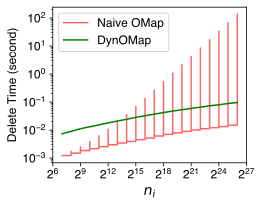

In [38]:
fig, ax1 = plt.subplots(figsize=(3.75, 3))
bs = mbs[0]
lw = 1.5
ndf = netsimcol(nomap_ram[bs], 'delete')
# sdf = netsimcol(somap_ram[bs], 'delete')
ddf = netsimcol(domap_ram[bs], 'delete')
ax1.plot(gte_cutoff(ndf)['n'], gte_cutoff(ndf)['delete'],
         label=f'Naive OMap', linestyle='-', color='#FF6666', lw=lw, marker='')
ax1.plot(gte_cutoff(ddf)['n'], gte_cutoff(ddf)['delete'],
         label=f'DynOMap', linestyle='-', color='green', lw=lw, marker='')

ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
xticks = [2**x for x in range(6, 28, 3)]
ax1.set_xticks(xticks)
ax1.set_xlim((xticks[0], xticks[-1]))
ax1.set_xlabel(f'$n_i$', fontsize=14)
ax1.set_ylabel('Delete Time (second)', fontsize=12)
ax1.tick_params(axis='x', labelsize=12)
ax1.tick_params(axis='y', labelsize=12)
ax1.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.savefig('plots_usenix/local-omap_delete.eps', bbox_inches='tight')
plt.show()

# div = gte_cutoff(ddf)['delete'].to_numpy() / \
#     gte_cutoff(sdf)['delete'].to_numpy()
# print(div.min(), div.max(), div.mean())

NameError: name 'nnomaps' is not defined

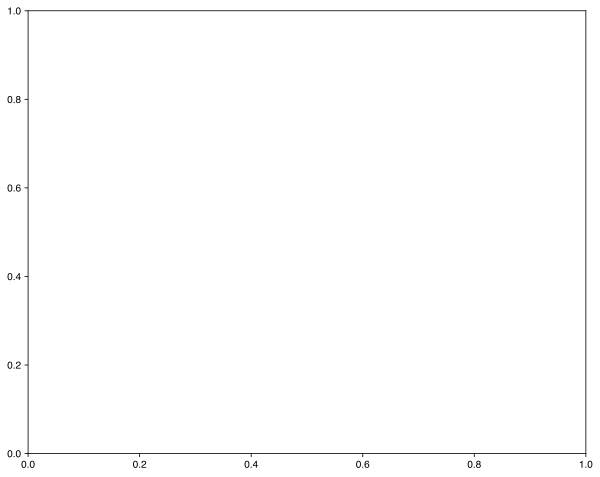

In [39]:
markers = ['x', 's', '^', 'D']
lw = 2.5
fontsize = 18
largefont = 25
fig, ax1 = plt.subplots(figsize=(10, 8))
show_bw = False

for idx, bs in enumerate(mbs):
  marker = markers[idx]

  ls, ms = '-', ''
  ndf = netsimcol(nnomaps[bs], 'insert')
  ax1.plot(gte_cutoff(ndf)['n'], gte_cutoff(ndf)[
           'insert'], label=f'Naive OMap (bs={bss[idx]})', linestyle=ls, marker=marker, color='#FF6666', lw=lw)

for idx, bs in enumerate(mbs):
  marker = markers[idx]

  ls, ms = '-', ''
  ddf = netsimcol(domap_ram[bs], 'insert')
  ax1.plot(gte_cutoff(ddf)['n'], gte_cutoff(ddf)[
           'insert'], label=f'DynOMap (bs={bss[idx]})', linestyle=ls, marker=marker, color='green', lw=lw)

ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
xticks = [2**x for x in range(6, 28, 3)]
ax1.set_xticks(xticks)
ax1.set_xlim((xticks[0], xticks[-1]))
ax1.set_ylim((8E-4, 1E3))
ax1.set_xlabel(f'$n_i$',                 fontsize=largefont)
ax1.set_ylabel('Insert Time (second)',   fontsize=largefont)
ax1.tick_params(axis='x', which='both', labelsize=largefont)
ax1.tick_params(axis='y', which='both', labelsize=largefont)
ax1.legend(loc='upper left', fontsize=fontsize, ncols=1)
plt.tight_layout()
plt.savefig('plots_usenix/local-omap_insert-multibs.eps', bbox_inches='tight')
plt.show()

nbw=1e+16
rtt=0
nbw=1e+16
rtt=0
nbw=1e+16
rtt=0
nbw=1e+16
rtt=0
nbw=1e+16
rtt=0
nbw=1e+16
rtt=0
nbw=1e+16
rtt=0
nbw=1e+16
rtt=0
nbw=1e+16
rtt=0
nbw=1e+16
rtt=0
nbw=1e+16
rtt=0
nbw=1e+16
rtt=0
nbw=1e+16
rtt=0
nbw=1e+16
rtt=0
nbw=1e+16
rtt=0
nbw=1e+16
rtt=0


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


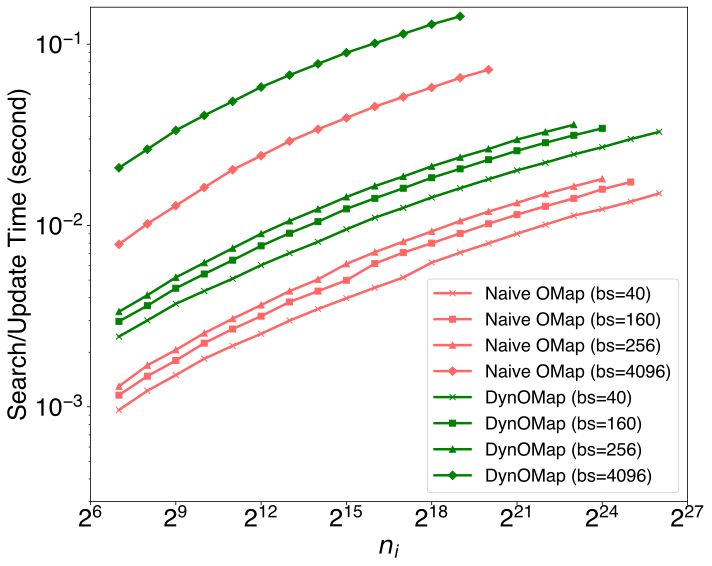

2.5400863827077607 2.6411033776577466
2.16570841366502 2.6411033776577466


In [ ]:
# Map Search Times

fig, ax1 = plt.subplots(figsize=(10, 8))
lw = 2.5
fontsize = 18
largefont = 25

markers = ['x', 's', '^', 'D']

mino, maxo = None, None
minl, maxl = None, None

for idx, bs in enumerate(mbs):
  sdf = netsimcol(somap_ram[bs], 'search')
  ddf = netsimcol(domap_ram[bs], 'search')
  ss = gte_cutoff(sdf)['search'].to_numpy()
  dd = gte_cutoff(ddf)['search'].to_numpy()
  m = (dd[0] / ss[0])
  if not mino or mino > m.min():
    mino = m.min()
  if not maxo or maxo < m.max():
    maxo = m.max()
  ll = min(len(dd), len(ss))
  mm = dd[:ll] / ss[:ll]
  mi, ma = mm.min(), mm.max()
  if not minl or minl > mi:
    minl = mi
  if not maxl or maxl < ma:
    maxl = ma

for idx, bs in enumerate(mbs):
  sdf = netsimcol(somap_ram[bs], 'search')
  ax1.plot(gte_cutoff(sdf)['n'], gte_cutoff(sdf)[
           'search'], label=f'Naive OMap (bs={bss[idx]})', linestyle='-', color='#FF6666', marker=markers[idx], lw=lw)
for idx, bs in enumerate(mbs):
  ddf = netsimcol(domap_ram[bs], 'search')
  ax1.plot(gte_cutoff(ddf)['n'], gte_cutoff(ddf)[
           'search'], label=f'DynOMap (bs={bss[idx]})', linestyle='-', color='green', marker=markers[idx], lw=lw)

ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
xticks = [2**x for x in range(6, 28, 3)]
ax1.set_xticks(xticks)
ax1.set_xlim((xticks[0], xticks[-1]))
ax1.set_ylim((3E-4, 1.6E-1))
ax1.set_xlabel(f'$n_i$',                      fontsize=largefont)
ax1.set_ylabel('Search/Update Time (second)', fontsize=largefont)
ax1.tick_params(axis='x', which='both',      labelsize=largefont)
ax1.tick_params(axis='y', which='both',      labelsize=largefont)
ax1.legend(loc='lower right', fontsize=fontsize, ncols=1)
# ax1.legend(loc='upper left')
# ax1.legend(loc='lower right')

plt.tight_layout()
plt.savefig('plots_usenix/local-omap_search_update-multibs.eps',
            bbox_inches='tight')
plt.show()
print(mino, maxo)
print(minl, maxl)

NameError: name 'nnomaps' is not defined

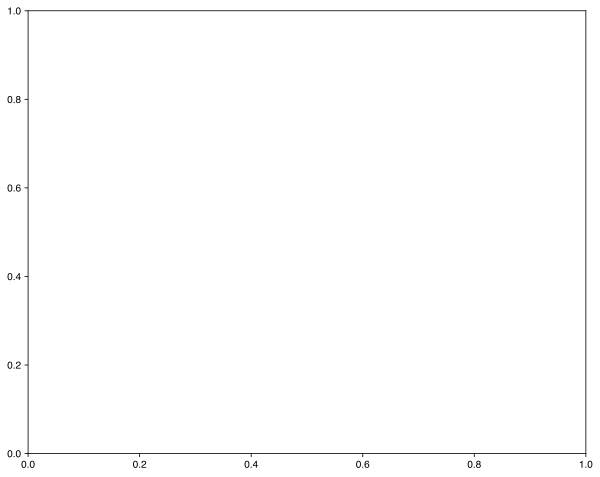

In [40]:
markers = ['x', 's', '^', 'D']
lw = 2.5
fontsize = 18
largefont = 25
fig, ax1 = plt.subplots(figsize=(10, 8))
show_bw = False
bs = mbs[0]
ls = '-'

for idx, bs in enumerate(mbs):
  marker = markers[idx]
  ndf = netsimcol(nnomaps[bs], 'delete')
  ax1.plot(gte_cutoff(ndf)['n'], gte_cutoff(ndf)['delete'],
           label=f'Naive OMap (bs={bss[idx]})', linestyle=ls, marker=marker, color='#FF6666', lw=lw)

for idx, bs in enumerate(mbs):
  marker = markers[idx]
  ddf = netsimcol(domap_ram[bs], 'delete')
  ax1.plot(gte_cutoff(ddf)['n'], gte_cutoff(ddf)['delete'],
           label=f'DynOMap (bs={bss[idx]})', linestyle=ls, marker=marker, color='green', lw=lw)

ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
xticks = [2**x for x in range(6, 28, 3)]
ax1.set_xticks(xticks)
ax1.set_xlim((xticks[0], xticks[-1]))
ax1.set_ylim((1E-3, 5E2))
ax1.set_xlabel(f'$n_i$',                 fontsize=largefont)
ax1.set_ylabel('Delete Time (second)',   fontsize=largefont)
ax1.tick_params(axis='x', which='both', labelsize=largefont)
ax1.tick_params(axis='y', which='both', labelsize=largefont)
ax1.legend(loc='upper left', fontsize=fontsize, ncols=1)
plt.tight_layout()
plt.savefig('plots_usenix/local-omap_delete-multibs.eps', bbox_inches='tight')
plt.show()

#### Multi-region:

In [31]:
rtt = 0.02  # Round-trip time: 100 ms
nbw = 5E9 // 8  # Network bandwidth

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


nbw=625000000.0
rtt=0.02
nbw=625000000.0
rtt=0.02
nbw=625000000.0
rtt=0.02
nbw=625000000.0
rtt=0.02
nbw=625000000.0
rtt=0.02
nbw=625000000.0
rtt=0.02
nbw=625000000.0
rtt=0.02
nbw=625000000.0
rtt=0.02


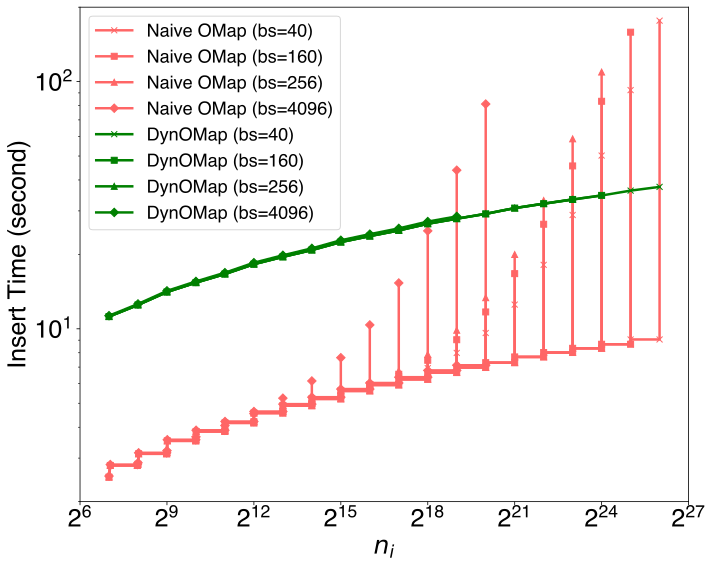

In [187]:
markers = ['x', 's', '^', 'D']
fig, ax1 = plt.subplots(figsize=(10, 8))
lw = 2.5
fontsize = 18
largefont = 25
ls = '-'

for idx, bs in enumerate(mbs):
  marker = markers[idx]
  ndf = netsimcol(nnomaps[bs], 'insert')
  ax1.plot(gte_cutoff(ndf)['n'], gte_cutoff(ndf)[
           'insert'], label=f'Naive OMap (bs={bss[idx]})', linestyle=ls, marker=marker, color='#FF6666', lw=lw)

for idx, bs in enumerate(mbs):
  marker = markers[idx]
  ddf = netsimcol(domap_ram[bs], 'insert')
  ax1.plot(gte_cutoff(ddf)['n'], gte_cutoff(ddf)[
           'insert'], label=f'DynOMap (bs={bss[idx]})', linestyle=ls, marker=marker, color='green', lw=lw)

ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
xticks = [2**x for x in range(6, 28, 3)]
ax1.set_xticks(xticks)
ax1.set_xlim((xticks[0], xticks[-1]))
ax1.set_ylim((2E0, 2E2))
ax1.set_xlabel(f'$n_i$',                 fontsize=largefont)
ax1.set_ylabel('Insert Time (second)',   fontsize=largefont)
ax1.tick_params(axis='x', which='both', labelsize=largefont)
ax1.tick_params(axis='y', which='both', labelsize=largefont)
ax1.legend(loc='upper left', fontsize=fontsize, ncols=1)
plt.tight_layout()
plt.savefig('plots_usenix/rtt20ms-omap_insert-multibs.eps',
            bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


nbw=625000000.0
rtt=0.02
nbw=625000000.0
rtt=0.02
nbw=625000000.0
rtt=0.02
nbw=625000000.0
rtt=0.02
nbw=625000000.0
rtt=0.02
nbw=625000000.0
rtt=0.02
nbw=625000000.0
rtt=0.02
nbw=625000000.0
rtt=0.02


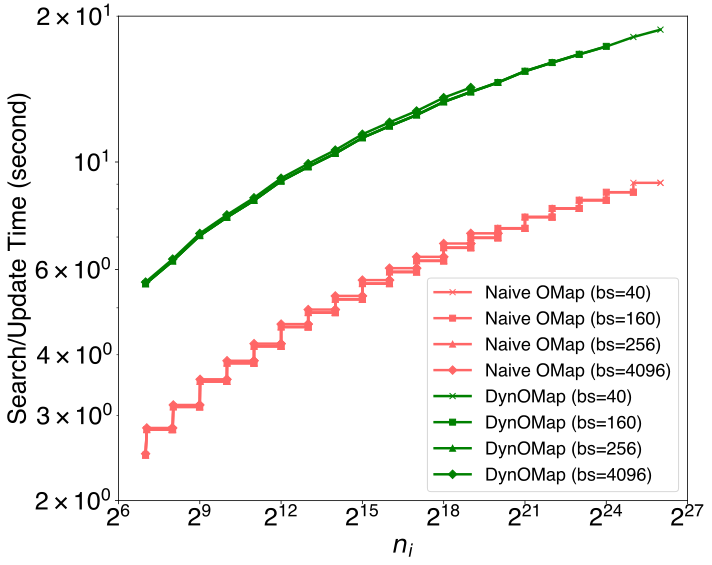

In [188]:
markers = ['x', 's', '^', 'D']
fig, ax1 = plt.subplots(figsize=(10, 8))
lw = 2.5
fontsize = 18
largefont = 25
ls = '-'

for idx, bs in enumerate(mbs):
  marker = markers[idx]
  ndf = netsimcol(nnomaps[bs], 'search')
  ax1.plot(gte_cutoff(ndf)['n'], gte_cutoff(ndf)[
           'search'], label=f'Naive OMap (bs={bss[idx]})', linestyle=ls, marker=marker, color='#FF6666', lw=lw)

for idx, bs in enumerate(mbs):
  marker = markers[idx]
  ddf = netsimcol(domap_ram[bs], 'search')
  ax1.plot(gte_cutoff(ddf)['n'], gte_cutoff(ddf)[
           'search'], label=f'DynOMap (bs={bss[idx]})', linestyle=ls, marker=marker, color='green', lw=lw)

ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
xticks = [2**x for x in range(6, 28, 3)]
ax1.set_xticks(xticks)
ax1.set_xlim((xticks[0], xticks[-1]))
ax1.set_yticks([2E0, 6E0, 1E1])
ax1.set_ylim((2E0, 2E1))
ax1.set_xlabel(f'$n_i$',                      fontsize=largefont)
ax1.set_ylabel('Search/Update Time (second)', fontsize=largefont)
ax1.tick_params(axis='x', which='both',      labelsize=largefont)
ax1.tick_params(axis='y', which='both',      labelsize=largefont)
ax1.legend(loc='lower right', fontsize=fontsize, ncols=1)
plt.tight_layout()
plt.savefig('plots_usenix/rtt20ms-omap_search_update-multibs.eps',
            bbox_inches='tight')
plt.show()

nbw=625000000.0
rtt=0.02
nbw=625000000.0
rtt=0.02
nbw=625000000.0
rtt=0.02
nbw=625000000.0
rtt=0.02
nbw=625000000.0
rtt=0.02
nbw=625000000.0
rtt=0.02
nbw=625000000.0
rtt=0.02
nbw=625000000.0
rtt=0.02


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


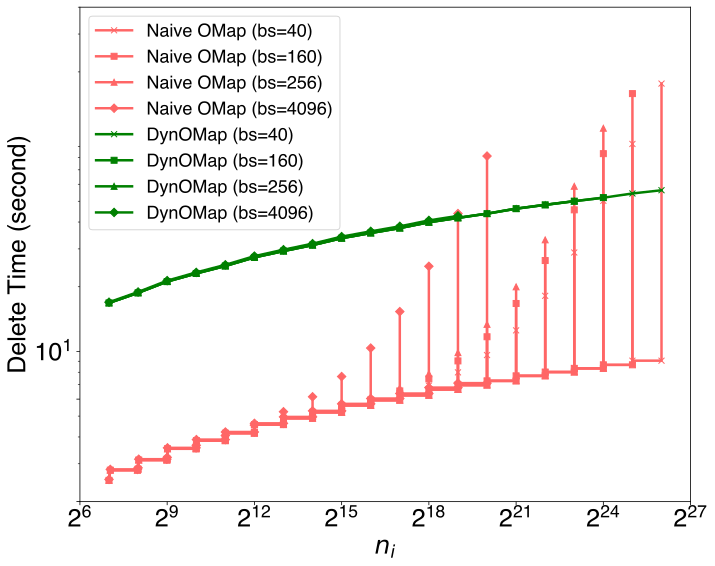

In [189]:
markers = ['x', 's', '^', 'D']
fig, ax1 = plt.subplots(figsize=(10, 8))
lw = 2.5
fontsize = 18
largefont = 25
ls = '-'

for idx, bs in enumerate(mbs):
  marker = markers[idx]
  ndf = netsimcol(nnomaps[bs], 'delete')
  ax1.plot(gte_cutoff(ndf)['n'], gte_cutoff(ndf)[
           'delete'], label=f'Naive OMap (bs={bss[idx]})', linestyle=ls, marker=marker, color='#FF6666', lw=lw)

for idx, bs in enumerate(mbs):
  marker = markers[idx]
  ddf = netsimcol(domap_ram[bs], 'delete')
  ax1.plot(gte_cutoff(ddf)['n'], gte_cutoff(ddf)[
           'delete'], label=f'DynOMap (bs={bss[idx]})', linestyle=ls, marker=marker, color='green', lw=lw)

ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
xticks = [2**x for x in range(6, 28, 3)]
ax1.set_xticks(xticks)
ax1.set_xlim((xticks[0], xticks[-1]))
ax1.set_yticks([2E0, 6E0, 1E1])
ax1.set_ylim((2E0, 4E2))
ax1.set_xlabel(f'$n_i$',                 fontsize=largefont)
ax1.set_ylabel('Delete Time (second)',   fontsize=largefont)
ax1.tick_params(axis='x', which='both', labelsize=largefont)
ax1.tick_params(axis='y', which='both', labelsize=largefont)
ax1.legend(loc='upper left', fontsize=fontsize, ncols=1)
plt.tight_layout()
plt.savefig('plots_usenix/rtt20ms-omap_delete-multibs.eps',
            bbox_inches='tight')
plt.show()

## SGX

#### Utils

In [39]:
# SET THIS:
rtt = 0

# (i, s) multipliers
op_mults = {
    'i': ((1, 0), (2, 0)),  # del k or take one -- insert two
    'd': ((3, 0), (3, 0)),  # del; 2moves -- same
    's': ((0, 1), (0, 1)),  # search -- same
}


n_diffs = {
    'i': 1,
    'd': -1,
    's': 0,
}

sgx_times = {k: dict(v) for k, v in dict(omix_data.T).items()}
sgx_times


def sgxtime(n):
  f = (0., 0.)
  for k, v in sgx_times.items():
    v = (v['w'], v['r'])  # (i, s)
    if n <= k:
      # if 383 < n < 512:
      #   print(f'sgxtime    : {n=} -- {k=}; {f=}, {v=}')
      return f, v
    f = v
  raise Exception(f'n not found in sgx_times: {n} - {sgx_times=}')


def idealsgxtime(n): return sgxtime(n)[1]


def naivesgxtime(n):
  vals = idealsgxtime(n)
  if (int(n) & int(n-1)) == 0:
    # 3., 1.44, log2(n) for getting ORAM access cost from OMap
    # n for n; 3 for two instances one with 2n space
    i = vals[0] / 3. / 1.44 / np.log2(n) * n * 3.
    s = vals[1]
    vals = (i, s)
  return vals


N = int(max(sgx_times.keys()))
print(f'{N=}')


# List of ns used in throughput tests
lns = ns(N)
print(f'{lns=}')


class SimSgx:
  def __init__(self, tocount='i') -> None:
    # Current capacity
    self.n = 0
    self.res = {}
    self.tocount = tocount

  def __do_action(self, act: str) -> None:
    if len(act) != 1:
      raise Exception(f'Bad action size: {act}')
    if act not in op_mults.keys():
      raise Exception(f'Bad action type: {act}')

    r = rtt
    times = sgxtime(self.n)
    self.n += n_diffs[act]

    if times[0] == (0., 0.):
      # Just one instance; ideal.
      (i, s) = times[1]
      return r + (s if act == 's' else i)
    mults = op_mults[act]
    for t, m in zip(times, mults):
      for tt, mm in zip(t, m):
        r += tt * mm
    return r

  def do(self, pattern: str, reps: int):
    for n in lns:
      self.n = n
      took = reps_done = 0
      for _ in range(reps):
        for act in pattern:
          # if self.n == N and act == 'i':
          if self.n == N:
            break
          took += self.__do_action(act)
          if act == self.tocount:
            reps_done += 1
      if reps_done == 0 or took == 0:
        continue
      throughput = reps_done / took
      self.res[n] = throughput

    # print(f'pattern: {pattern}')
    # print(self.res)
    return self.res


class SimNaive:
  def __init__(self, tocount='i') -> None:
    # Current capacity
    self.n = 0
    self.res = {}
    self.tocount = tocount

  def __do_action(self, act: str):
    if len(act) != 1:
      raise Exception(f'Bad action size: {act}')
    if act not in op_mults.keys():
      raise Exception(f'Bad action type: {act}')

    n0 = self.n
    self.n += n_diffs[act]
    n1 = self.n
    # if 383<self.n<512:
    #   ti0 = idealsgxtime(n0)
    #   tn0 = naivesgxtime(n0)
    #   tn1 = naivesgxtime(n1)
    #   print(f'do_action: {n0=}, {n1=} --- {ti0=}, {tn0=}, {tn1=}')

    if act == 's':
      return rtt + idealsgxtime(n0)[1]
    if act == 'd':
      return rtt + naivesgxtime(n1)[0]
    return rtt + naivesgxtime(n0)[0]

  def do(self, pattern: str, reps: int):
    for n in lns:
      self.n = n
      took = reps_done = 0
      for _ in range(reps):
        for act in pattern:
          # if self.n == N and act == 'i':
          if self.n == N:
            break
          action_took = self.__do_action(act)
          took += action_took
          # took += self.__do_action(act)
          # if 256 < n < 512:
          #   print(f'do (insid loop): {n=}, {self.n=} --- {act=}: {action_took=}, {took=:2f}')
          if act == self.tocount:
            reps_done += 1
      if reps_done == 0 or took == 0:
        continue
      # if 256 < n < 512:
      #   print(f'do (after loop): {reps_done}, {took=}')
      throughput = reps_done / took
      self.res[n] = throughput

    return self.res


class SimIdeal:
  def __init__(self, tocount='i') -> None:
    # Current capacity
    self.n = 0
    self.res = {}
    self.tocount = tocount

  def __do_action(self, act: str):
    if len(act) != 1:
      raise Exception(f'Bad action size: {act}')
    if act not in op_mults.keys():
      raise Exception(f'Bad action type: {act}')

    (i, s) = idealsgxtime(self.n)
    self.n += n_diffs[act]
    return rtt + (s if act == 's' else i)

  def do(self, pattern: str, reps: int):
    for n in lns:
      self.n = n
      took = reps_done = 0
      for _ in range(reps):
        for act in pattern:
          # if self.n == N and act == 'i':
          if self.n == N:
            break
          took += self.__do_action(act)
          if act == self.tocount:
            reps_done += 1
      if reps_done == 0 or took == 0:
        continue
      throughput = reps_done / took
      self.res[n] = throughput

    return self.res

N=8388608
lns=[132, 256, 384, 512, 768, 1024, 1536, 2048, 3072, 4096, 6144, 8192, 12288, 16384, 24576, 32768, 49152, 65536, 98304, 131072, 196608, 262144, 393216, 524288, 786432, 1048576, 1572864, 2097152, 3145728, 4194304, 6291456, 8388608]


#### Throughput

In [37]:
rtt = 0.02  # Round-trip time: 100 ms
nbw = 5E9 // 8  # Network bandwidth

In [38]:
import itertools

fontsize = 20.5
largefont = 30
lw = 2.5
largelw = 4
opcount = 101
legendalpha = .5
lss = {
    '0:1': '-',
    '1:0': (5, (10, 3)),
    '1:1': '--',
    '1:4': '-.',
    f'1:{opcount-1}': ':',
}
default_ls = '--'
lcs = {
    'Naive': '#FF6666',
    'Dyno': 'g',
    # 'Ideal': 'b',
}
patterns = ['s', 'i', 'is', 'issss', 'i'+((opcount-1)*'s')]
schemes = ['Naive', 'Dyno']
sims = {
    'Naive': SimNaive,
    'Dyno': SimSgx,
    # 'Ideal': SimIdeal,
}
rtt = 0.02  # 100ms
ops = list('is')
figsize = (10, 8)
opnames = {'i': 'Insert', 's': 'Search'}
markers = {
    'Naive': '',
    'Dyno': '',
}


def plotruns(name, runs, lat=None):
  miny = 100.
  maxy = 0.
  _, ax = plt.subplots(figsize=figsize)
  lens = {len(run) for run in runs.values()}
  if len(lens) != 1:
    raise Exception(f'bad runs: {lens}')
  for group, run in runs.items():
    scheme = group.split()[0]
    ratio = group.split()[-1]
    x, y = zip(*sorted(run.items()))
    miny = float(min(miny, min(y)))
    maxy = float(max(maxy, max(y)))
    if x[-1] >= N:
      x, y = x[:-1], y[:-1]
    lc = lcs[scheme]
    marker = markers[scheme]
    ls = lss.get(ratio, default_ls)
    ax.plot(x, y, label=group, lw=lw if ls != ':' else largelw,
            color=lc, linestyle=ls, marker=marker)
    # print(f'{scheme=}, {ratio=}, min={min(y):.3f}, max={max(y):.3f}')
    # if ratio == '1:0':
    #   print(y)

  ax.set_xlabel(f'$n_i$',                           fontsize=largefont)
  ax.set_ylabel(f'{name} Throughput (op / second)', fontsize=largefont)
  ax.tick_params(axis='x', which='both',           labelsize=largefont)
  ax.tick_params(axis='y', which='both',           labelsize=largefont)
  xticks = [2**x for x in range(6, 23, 3)]
  xlims = (2**6, 2**23)
  # ylims = ax.get_ylim()
  # print(ylims)
  # ax.set_ylim((miny/10, 2*maxy))
  ax.set_xticks(xticks)
  # ax.set_xlim((xticks[0], xticks[-1]))
  ax.set_xlim(xlims)
  ax.set_xscale('log', base=2)
  ax.set_yscale('log', base=10)
  ax.legend(loc='lower left', fontsize=fontsize, ncols=2)
  plt.tight_layout()
  fname = f'plots_usenix/{name.lower()}_tput_omix_sgx{f"_{int(lat*1000)}ms" if lat is not None else ""}.eps'
  print(fname)
  plt.savefig(fname, bbox_inches='tight')
  plt.show()


def stats(runs):
  mains = 'Dyno'
  run_dfs = {g: pd.DataFrame(
      r, index=('n', 'tput')).T for g, r in runs.items()}
  ratios = {g.split()[-1] for g in runs}
  todiv = {s for s in schemes if s != mains}
  for s, r in itertools.product(todiv, ratios):
    bymains = run_dfs[f'{s} - {r}']['tput'] / run_dfs[f'{mains} - {r}']['tput']
    mainsby = 1 / bymains
    print(f'{s=}, {r=}, by {mains}: {bymains.min()}-{bymains.mean()}-{bymains.max()} --- '
          f'{mains} by: {mainsby.min()}-{mainsby.mean()}-{mainsby.max()}')

Insert
s='Naive', r='1:100', by Dyno: 0.0007037937615193294-1.0859271603559983-1.9355473463894506 --- Dyno by: 0.5166497228111673-97.90490975690233-1420.8707929454065
s='Naive', r='1:4', by Dyno: 0.0010326022510385412-1.3064616589871145-2.2844173298034165 --- Dyno by: 0.4377483864062851-66.66469917084275-968.4270966814653
s='Naive', r='1:0', by Dyno: 0.0024695325942773612-1.7456192358527607-2.914038529618004 --- Dyno by: 0.34316636167850817-27.96520745906197-404.9349266809826
s='Naive', r='1:1', by Dyno: 0.0015624089061144076-1.528093452259866-2.6162303167156455 --- Dyno by: 0.382229344874872-44.08482613859907-640.0373142309616
plots_usenix/insert_tput_omix_sgx_0ms.eps


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


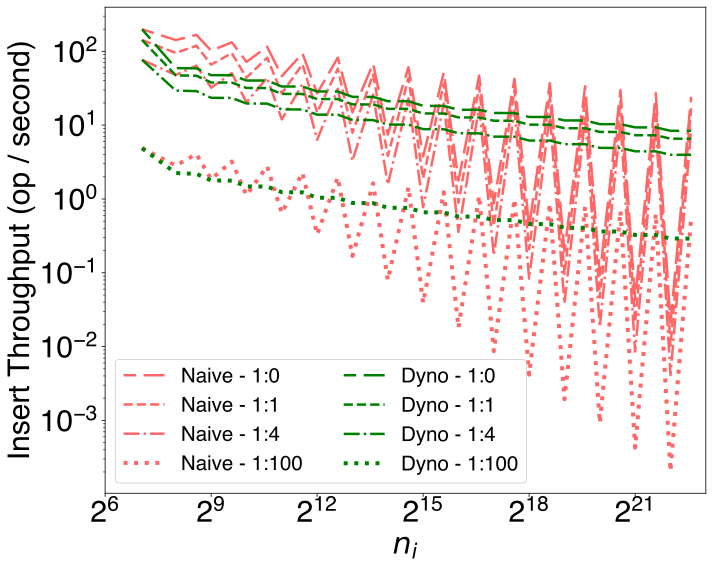

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Search
s='Naive', r='1:100', by Dyno: 0.0007037937615193294-1.0859271603559983-1.9355473463894506 --- Dyno by: 0.5166497228111673-97.90490975690233-1420.8707929454065
s='Naive', r='0:1', by Dyno: 1.0-1.8091118299083955-1.9124227490890413 --- Dyno by: 0.5228969381776793-0.5663052018229192-1.0
s='Naive', r='1:4', by Dyno: 0.0010326022510385412-1.3064616589871145-2.2844173298034165 --- Dyno by: 0.4377483864062851-66.66469917084275-968.4270966814653
s='Naive', r='1:1', by Dyno: 0.0015624089061144076-1.528093452259866-2.6162303167156455 --- Dyno by: 0.382229344874872-44.08482613859907-640.0373142309616
plots_usenix/search_tput_omix_sgx_0ms.eps


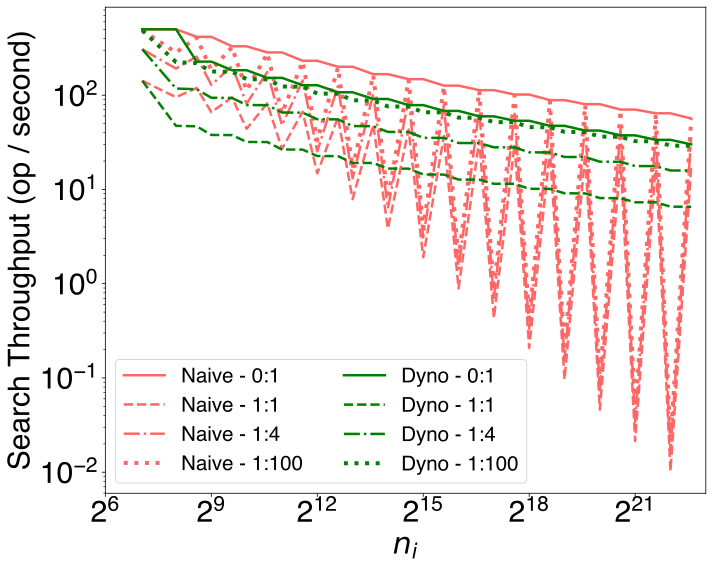

Insert
s='Naive', r='1:100', by Dyno: 0.0011177068623677354-0.8092568859247544-1.427311186910227 --- Dyno by: 0.700618063650682-59.13418458494565-894.6889686993719
s='Naive', r='1:4', by Dyno: 0.0014422478230447272-0.9040024623316971-1.6624180391124712 --- Dyno by: 0.601533414864698-46.33099623744479-693.3621143479361
s='Naive', r='1:0', by Dyno: 0.002882514295191976-1.2000831538532664-2.274248437428347 --- Dyno by: 0.4397056994928709-23.72783946166372-346.9193549770062
s='Naive', r='1:1', by Dyno: 0.0019717777439702214-1.0312100117718592-1.946626515887318 --- Dyno by: 0.5137092255954279-34.27339374114945-507.15655101496185
plots_usenix/insert_tput_omix_sgx_20ms.eps


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


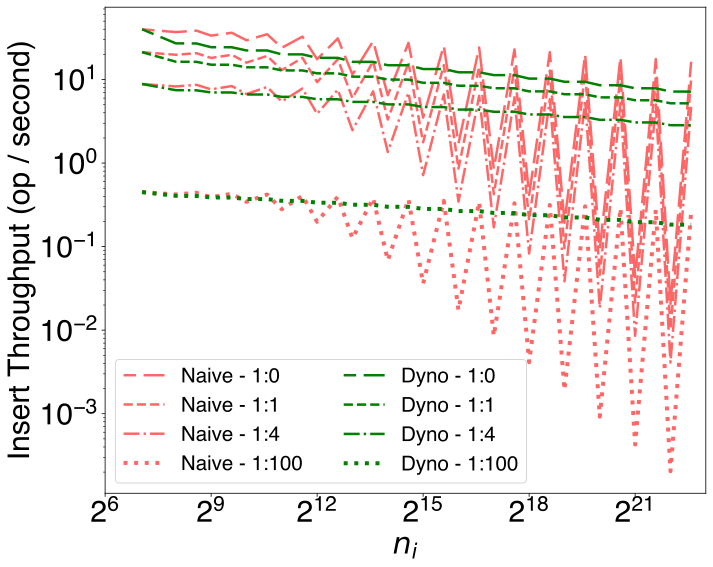

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Search
s='Naive', r='1:100', by Dyno: 0.0011177068623677352-0.8092568859247544-1.4273111869102268 --- Dyno by: 0.7006180636506821-59.134184584945665-894.6889686993721
s='Naive', r='0:1', by Dyno: 1.0-1.225914953440676-1.413530081347872 --- Dyno by: 0.7074486869401815-0.8230104255085234-1.0
s='Naive', r='1:4', by Dyno: 0.0014422478230447272-0.9040024623316971-1.6624180391124712 --- Dyno by: 0.601533414864698-46.33099623744479-693.3621143479361
s='Naive', r='1:1', by Dyno: 0.0019717777439702214-1.0312100117718592-1.946626515887318 --- Dyno by: 0.5137092255954279-34.27339374114945-507.15655101496185
plots_usenix/search_tput_omix_sgx_20ms.eps


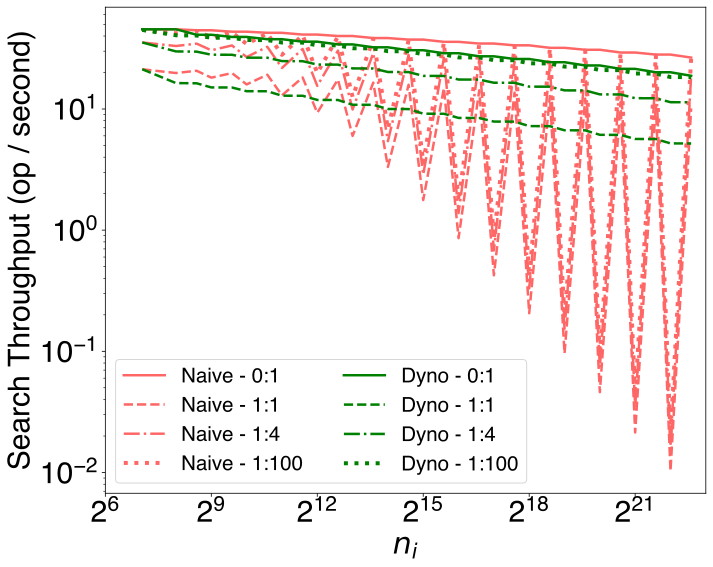

In [58]:
rtt = 0.00
for rtt in (0., 0.02):
  for op in ops:
    filtered_patterns = filter(lambda p: op in p, patterns)
    opname = opnames[op]
    print(opname)
    runs = {
        f'{scheme} - {pattern.count("i")}:{pattern.count("s")}':
        sims[scheme](op).do(pattern, opcount // len(pattern))

        for scheme, pattern in itertools.product(schemes, filtered_patterns)
    }
    stats(runs)
    plotruns(opname, runs, rtt)

In [40]:
# SET THIS:
rtt = 0

op_mults = {
    'i': (2, 2),
    'd': (3, 3),
    's': (1, 1),
}

n_diffs = {
    'i': 1,
    'd': -1,
    's': 0,
}


sgx_times = pd.DataFrame(
    np.array([
        512, 985.280000,
        1024, 1311.970000,
        2048, 1520.090000,
        4096, 1923.900000,
        8192, 2449.470000,
        16384, 3090.140000,
        32768, 3492.080000,
        65536, 4246.370000,
        131072, 5169.450000,
        262144, 5740.210000,
        524288, 6896.410000,
        1048576, 8274.160000,
        2097152, 9730.840000,
        4194304, 10597.780000,
        8388608, 12405.130000,
    ]).reshape((-1, 2)),
    columns=['n', 't'])
sgx_times['t'] *= 3
sgx_times['t'] /= 1E6
sdf = sgx_times

# converted it already; clean this if you care!
sgx_times = dict(sgx_times.values)


def sgxtime(n):
  f = 0
  for k, v in sgx_times.items():
    if n <= k:
      return f, v
    f = v
  raise Exception(f'n not found in sgx_times: {n} - {sgx_times=}')


def naivesgxtime(n):
  v = sgxtime(n)[1]
  if (int(n) & int(n-1)) != 0:
    return v
  return v / 3 / 1.44 * n * 1.5


def idealsgxtime(n): return sgxtime(n)[1]


N = int(max(sgx_times.keys()))


# List of ns used in throughput tests
lns = ns(N)
print(f'{lns=}')


class SimSgx:
  def __init__(self, tocount='i') -> None:
    # Current capacity
    self.n = 0
    self.res = {}
    self.tocount = tocount

  def __do_action(self, act: str) -> None:
    if len(act) != 1:
      raise Exception(f'Bad action size: {act}')
    if act not in op_mults.keys():
      raise Exception(f'Bad action type: {act}')

    r = rtt
    times = sgxtime(self.n)
    if times[0] > 0:
      mults = op_mults[act]
      for t, m in zip(times, mults):
        r += t * m
    else:
      r += times[1]
    self.n += n_diffs[act]
    return r

  def do(self, pattern: str, reps: int):
    for n in lns:
      self.n = n
      took = reps_done = 0
      for _ in range(reps):
        for act in pattern:
          # if self.n == N and act == 'i':
          if self.n == N:
            break
          took += self.__do_action(act)
          if act == self.tocount:
            reps_done += 1
      if reps_done == 0 or took == 0:
        continue
      throughput = reps_done / took
      self.res[n] = throughput

    return self.res


class SimNaive:
  def __init__(self, tocount='i') -> None:
    # Current capacity
    self.n = 0
    self.res = {}
    self.tocount = tocount

  def __do_action(self, act: str):
    if len(act) != 1:
      raise Exception(f'Bad action size: {act}')
    if act not in op_mults.keys():
      raise Exception(f'Bad action type: {act}')

    n0 = self.n
    self.n += n_diffs[act]
    n1 = self.n

    if act == 's':
      return rtt + idealsgxtime(n0)
    if act == 'd':
      return rtt + naivesgxtime(n1)
    return rtt + naivesgxtime(n0)

  def do(self, pattern: str, reps: int):
    for n in lns:
      self.n = n
      took = reps_done = 0
      for _ in range(reps):
        for act in pattern:
          # if self.n == N and act == 'i':
          if self.n == N:
            break
          took += self.__do_action(act)
          if act == self.tocount:
            reps_done += 1
      if reps_done == 0 or took == 0:
        continue
      throughput = reps_done / took
      self.res[n] = throughput

    return self.res


class SimIdeal:
  def __init__(self, tocount='i') -> None:
    # Current capacity
    self.n = 0
    self.res = {}
    self.tocount = tocount

  def __do_action(self, act: str):
    if len(act) != 1:
      raise Exception(f'Bad action size: {act}')
    if act not in op_mults.keys():
      raise Exception(f'Bad action type: {act}')

    r = rtt + idealsgxtime(self.n)
    self.n += n_diffs[act]
    return r

  def do(self, pattern: str, reps: int):
    for n in lns:
      self.n = n
      took = reps_done = 0
      for _ in range(reps):
        for act in pattern:
          # if self.n == N and act == 'i':
          if self.n == N:
            break
          took += self.__do_action(act)
          if act == self.tocount:
            reps_done += 1
      if reps_done == 0 or took == 0:
        continue
      throughput = reps_done / took
      self.res[n] = throughput

    return self.res

lns=[132, 256, 384, 512, 768, 1024, 1536, 2048, 3072, 4096, 6144, 8192, 12288, 16384, 24576, 32768, 49152, 65536, 98304, 131072, 196608, 262144, 393216, 524288, 786432, 1048576, 1572864, 2097152, 3145728, 4194304, 6291456, 8388608]


In [41]:
import itertools

fontsize = 20.5
largefont = 30
lw = 2.5
largelw = 4
opcount = 101
legendalpha = .5
lss = {
    '0:1': '-',
    '1:0': (5, (10, 3)),
    '1:1': '--',
    '1:4': '-.',
    f'1:{opcount-1}': ':',
}
default_ls = '--'
lcs = {
    'Naive': '#FF6666',
    'Dyno': 'g',
    # 'Ideal': 'b',
}
patterns = ['s', 'i', 'is', 'issss', 'i'+((opcount-1)*'s')]
schemes = ['Naive', 'Dyno']
sims = {
    'Naive': SimNaive,
    'Dyno': SimSgx,
    # 'Ideal': SimIdeal,
}
rtt = 0.02  # 100ms
ops = list('is')
figsize = (10, 8)
opnames = {'i': 'Insert', 's': 'Search'}
markers = {
    'Naive': '',
    'Dyno': '',
}


def plotruns(name, runs, lat=None):
  miny = 100.
  maxy = 0.
  _, ax = plt.subplots(figsize=figsize)
  lens = {len(run) for run in runs.values()}
  if len(lens) != 1:
    raise Exception(f'bad runs: {lens}')
  for group, run in runs.items():
    scheme = group.split()[0]
    ratio = group.split()[-1]
    x, y = zip(*sorted(run.items()))
    miny = float(min(miny, min(y)))
    maxy = float(max(maxy, max(y)))
    if x[-1] >= N:
      x, y = x[:-1], y[:-1]
    lc = lcs[scheme]
    marker = markers[scheme]
    ls = lss.get(ratio, default_ls)
    ax.plot(x, y, label=group, lw=lw if ls != ':' else largelw,
            color=lc, linestyle=ls, marker=marker)
    # print(f'{scheme=}, {ratio=}, min={min(y):.3f}, max={max(y):.3f}')
    # if ratio == '1:0':
    #   print(y)

  ax.set_xlabel(f'$n_i$',                           fontsize=largefont)
  ax.set_ylabel(f'{name} Throughput (op / second)', fontsize=largefont)
  ax.tick_params(axis='x', which='both',           labelsize=largefont)
  ax.tick_params(axis='y', which='both',           labelsize=largefont)
  xticks = [2**x for x in range(6, 23, 3)]
  xlims = (2**6, 2**23)
  # ylims = ax.get_ylim()
  # print(ylims)
  # ax.set_ylim((miny/10, 2*maxy))
  ax.set_xticks(xticks)
  # ax.set_xlim((xticks[0], xticks[-1]))
  ax.set_xlim(xlims)
  ax.set_xscale('log', base=2)
  ax.set_yscale('log', base=10)
  ax.legend(loc='lower left', fontsize=fontsize, ncols=2)
  plt.tight_layout()
  fname = f'plots_usenix/{name.lower()}_tput_sgx{f"_{int(lat*1000)}ms" if lat is not None else ""}.eps'
  print(fname)
  plt.savefig(fname, bbox_inches='tight')
  plt.show()


def stats(runs):
  mains = 'Dyno'
  run_dfs = {g: pd.DataFrame(
      r, index=('n', 'tput')).T for g, r in runs.items()}
  ratios = {g.split()[-1] for g in runs}
  todiv = {s for s in schemes if s != mains}
  for s, r in itertools.product(todiv, ratios):
    bymains = run_dfs[f'{s} - {r}']['tput'] / run_dfs[f'{mains} - {r}']['tput']
    mainsby = 1 / bymains
    print(f'{s=}, {r=}, by {mains}: {bymains.min()}-{bymains.mean()}-{bymains.max()} --- '
          f'{mains} by: {mainsby.min()}-{mainsby.mean()}-{mainsby.max()}')

Insert
s='Naive', r='1:100', by Dyno: 0.00015166123556890703-0.9769438590340942-1.9371881153738297 --- Dyno by: 0.5162121283234409-429.5677482791196-6593.642708031689
s='Naive', r='1:4', by Dyno: 0.0001784862760666339-1.1449646427316174-2.3018352900324337 --- Dyno by: 0.4344359495791333-365.01217753877984-5602.67165654054
s='Naive', r='1:0', by Dyno: 0.0003006884414109451-1.8550654285342945-3.8363921500540545 --- Dyno by: 0.26066156974748006-216.70720335242063-3325.7014978946904
s='Naive', r='1:1', by Dyno: 0.00022319447375040722-1.410911270303224-2.877294112540545 --- Dyno by: 0.3475487596633063-291.9121902711011-4480.397669336002
plots_usenix/insert_tput_sgx_0ms.eps


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


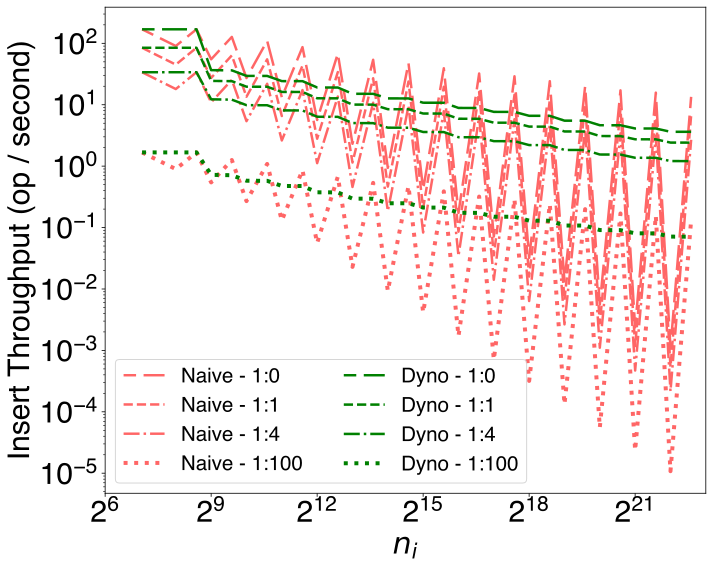

Search
s='Naive', r='1:100', by Dyno: 0.00015166123556890703-0.976943859034094-1.9371881153738295 --- Dyno by: 0.516212128323441-429.56774827911966-6593.642708031689
s='Naive', r='0:1', by Dyno: 1.0-1.7272938781533522-1.9181960750270273 --- Dyno by: 0.5213231394949601-0.6039617094499385-1.0
s='Naive', r='1:4', by Dyno: 0.0001784862760666339-1.1449646427316174-2.3018352900324337 --- Dyno by: 0.4344359495791333-365.01217753877984-5602.67165654054
s='Naive', r='1:1', by Dyno: 0.00022319447375040722-1.410911270303224-2.877294112540545 --- Dyno by: 0.3475487596633063-291.9121902711011-4480.397669336002
plots_usenix/search_tput_sgx_0ms.eps


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


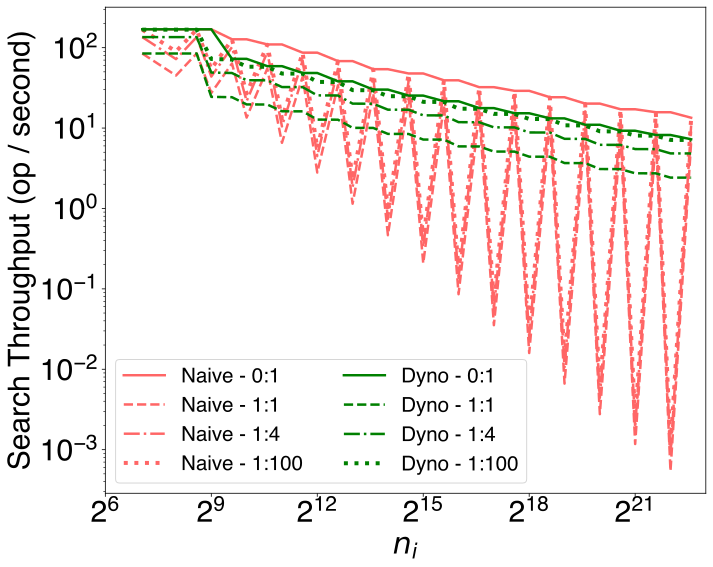

Insert
s='Naive', r='1:100', by Dyno: 0.0001734688195965003-0.839699474323131-1.712944703535058 --- Dyno by: 0.583790006727169-368.2633101165008-5764.7247633670695
s='Naive', r='1:4', by Dyno: 0.0002000773861500708-0.9351568118523542-1.9903418104415753 --- Dyno by: 0.5024262640486565-320.1602425626105-4998.066094535722
s='Naive', r='1:0', by Dyno: 0.00032249277502226415-1.3394089532599265-3.157721302006492 --- Dyno by: 0.3166840592817916-199.93475148192647-3100.844662119833
s='Naive', r='1:1', by Dyno: 0.00024478461836190325-1.0865074405640436-2.428109119778421 --- Dyno by: 0.41184310534250446-262.5067545433788-4085.2240091391045
plots_usenix/insert_tput_sgx_20ms.eps


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


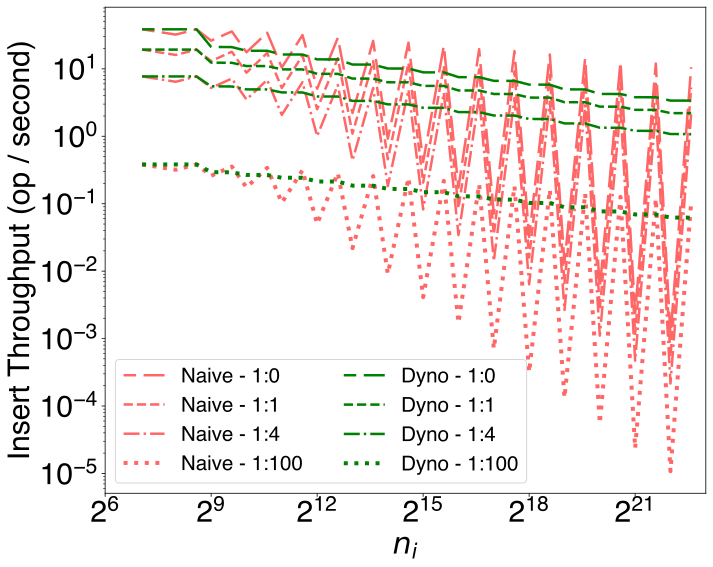

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Search
s='Naive', r='1:100', by Dyno: 0.0001734688195965003-0.839699474323131-1.7129447035350582 --- Dyno by: 0.583790006727169-368.2633101165008-5764.7247633670695
s='Naive', r='0:1', by Dyno: 1.0-1.4059336869242642-1.6984969375503436 --- Dyno by: 0.5887558451781782-0.7294719126358985-1.0
s='Naive', r='1:4', by Dyno: 0.0002000773861500708-0.9351568118523542-1.9903418104415753 --- Dyno by: 0.5024262640486565-320.1602425626105-4998.066094535722
s='Naive', r='1:1', by Dyno: 0.00024478461836190325-1.0865074405640436-2.428109119778421 --- Dyno by: 0.41184310534250446-262.5067545433788-4085.2240091391045
plots_usenix/search_tput_sgx_20ms.eps


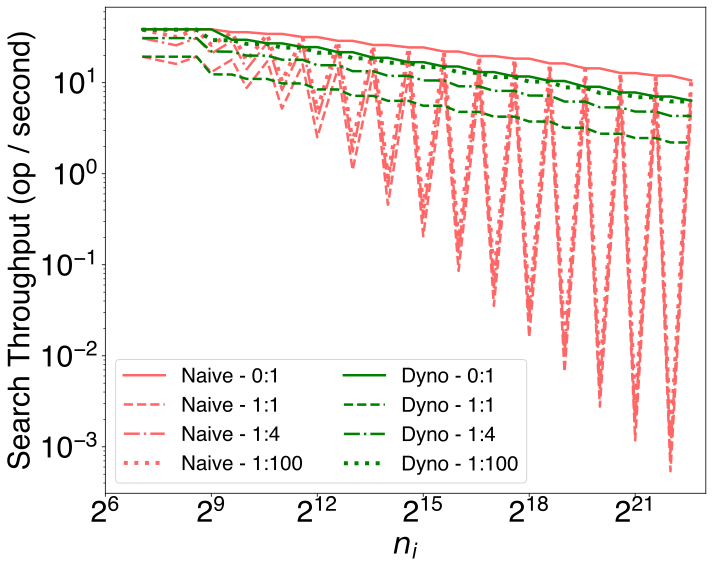

In [61]:
rtt = 0.00
for rtt in (0., 0.02):
  for op in ops:
    filtered_patterns = filter(lambda p: op in p, patterns)
    opname = opnames[op]
    print(opname)
    runs = {
        f'{scheme} - {pattern.count("i")}:{pattern.count("s")}':
        sims[scheme](op).do(pattern, opcount // len(pattern))

        for scheme, pattern in itertools.product(schemes, filtered_patterns)
    }
    stats(runs)
    plotruns(opname, runs, rtt)

In [260]:
import itertools

thread_counts = [1, 2, 8, 16, 32, 64]
opcount = 101
legendalpha = .5
# lss = {
#     '0:1': '-',
#     '1:0': (5, (10, 3)),
#     '1:1': '--',
#     '1:4': '-.',
#     f'1:{opcount-1}': ':',
# }
lss = {
    1: '-',
    2: (5, (10, 3)),
    8: '--',
    32: '-.',
    64: ':',
}
default_ls = '--'
# lcs = {
#     'Naive': '#FF6666',
#     'Dyno': 'g',
#     # 'Ideal': 'b',
# }
patterns = [
    # 's',
    # 'i',
    'is',
    'issss',
    'i'+((20)*'s'),
]
schemes = [
    'Naive',
    'Dyno',
]
sims = {
    'Naive': SimNaive,
    'Dyno': SimSgx,
    # 'Ideal': SimIdeal,
}
rtt = 0.02  # 100ms
ops = list('is')
figsize = (16, 6)
opnames = {'i': 'Insert', 's': 'Search'}
markers = {
    'Naive': '',
    'Dyno': '',
}
xlims = (2**12+2**11, 2**23+1)


def plotruns(name, runs, lat=None):
  runs = {tc: {n: t for n, t in run.items()
               if n > xlims[0]+100 and n < xlims[1]}
          for tc, run in runs.items()}
  miny = 100.
  maxy = 0.
  _, ax = plt.subplots(figsize=figsize)
  # lens = {len(run) for run in runs.values()}
  # if len(lens) != 1:
  #   raise Exception(f'bad runs: {lens}')
  for group, run in runs.items():
    scheme = group.split()[0]
    if scheme.startswith('Dyno'):
      tcount = int(scheme[4:]) if len(scheme) > 4 else 1
      scheme = 'Dyno'
    else:
      tcount = int(scheme[5:]) if len(scheme) > 5 else 1
      scheme = 'Naive'
    # ratio = group.split()[-1]

    x, y = zip(*sorted(run.items()))
    miny = float(min(miny, min(y)))
    maxy = float(max(maxy, max(y)))
    if x[-1] >= N:
      x, y = x[:-1], y[:-1]
    # lc = 'g'
    # marker = ''
    # ls = lss.get(ratio, default_ls)
    ls = lss.get(tcount, default_ls)
    ax.plot(x, y, label=group, lw=lw if ls != ':' else largelw,
            linestyle=ls)
    # print(f'{scheme=}, {ratio=}, min={min(y):.3f}, max={max(y):.3f}')
    # if ratio == '1:0':
    #   print(y)

  ax.set_xlabel(f'$n_i$', fontsize=largefont)
  ax.set_ylabel(
      f'{name[:name.index("_")]} Throughput', fontsize=largefont)
  ax.tick_params(axis='x', which='both', labelsize=largefont)
  ax.tick_params(axis='y', which='both', labelsize=largefont)
  # xticks = [2**x for x in range(6, 23, 3)]
  # ylims = ax.get_ylim()
  # print(ylims)
  # ax.set_ylim((miny/2, 1*maxy))
  # ax.set_xticks(xticks)
  # ax.set_xlim((xticks[0], xticks[-1]))
  ax.set_xlim(xlims)
  ax.set_xscale('log', base=2)
  ax.set_yscale('log', base=10)
  ax.legend(fontsize=fontsize, ncols=3, loc='center')
  plt.tight_layout()
  fname = f'plots_usenix/{name.lower()}_tput_threaded_sgx{f"_{int(lat*1000)}ms" if lat is not None else ""}.eps'
  print(fname)
  plt.savefig(fname, bbox_inches='tight')
  plt.show()


def stats(runs):
  mains = 'Dyno'
  run_dfs = {g: pd.DataFrame(
      r, index=('n', 'tput')).T for g, r in runs.items()}
  ratios = {g.split()[-1] for g in runs}
  todiv = {s for s in schemes if s != mains}
  for s, r in itertools.product(todiv, ratios):
    bymains = run_dfs[f'{s} - {r}']['tput'] / run_dfs[f'{mains} - {r}']['tput']
    mainsby = 1 / bymains
    print(f'{s=}, {r=}, by {mains}: {bymains.min()}-{bymains.mean()}-{bymains.max()} --- '
          f'{mains} by: {mainsby.min()}-{mainsby.mean()}-{mainsby.max()}')


def make_threaded_run(data, tcount):
  if tcount == 1:
    return data
  return {n*tcount: t*(1.8**np.log2(tcount)) for n, t in data.items()}

Insert
plots_usenix/insert_1i1s_tput_threaded_sgx_20ms.eps


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


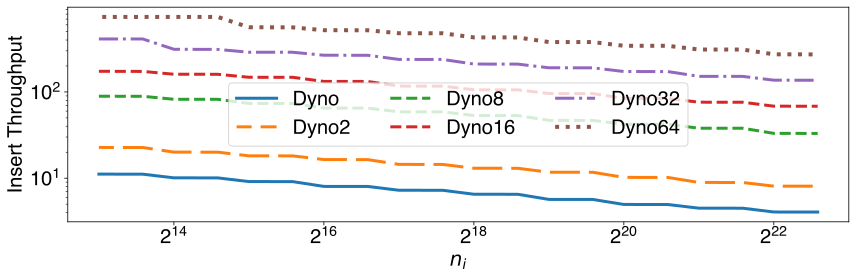

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


61.46338108726698	67.15858966107118	73.51881764107779
6291456 67.35409496072276
Search
plots_usenix/search_1i1s_tput_threaded_sgx_20ms.eps


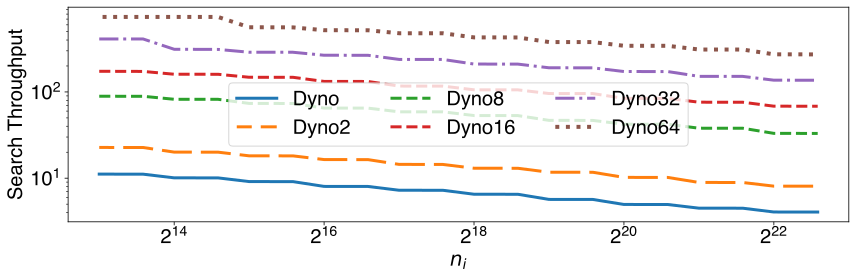

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


61.46338108726698	67.15858966107118	73.51881764107779
6291456 67.35409496072276
Insert
plots_usenix/insert_1i4s_tput_threaded_sgx_20ms.eps


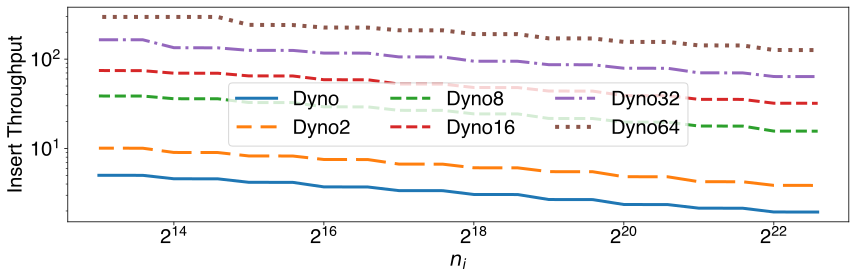

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


57.579255160967946	63.13362162899149	66.22371063196762
6291456 64.87960468077354
Search
plots_usenix/search_1i4s_tput_threaded_sgx_20ms.eps


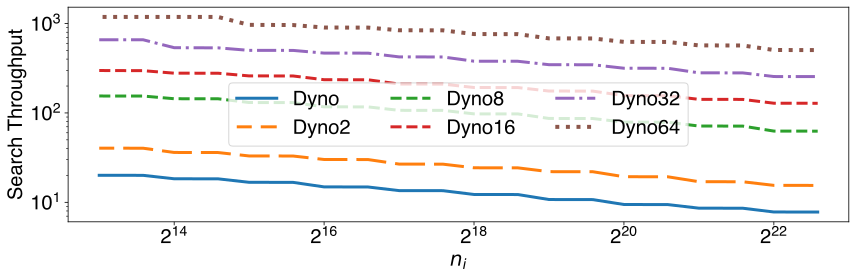

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


57.579255160967946	63.13362162899149	66.22371063196762
6291456 64.87960468077354
Insert
plots_usenix/insert_1i20s_tput_threaded_sgx_20ms.eps


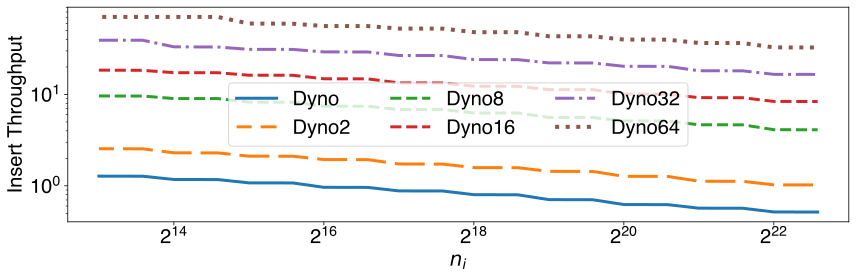

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


55.38039643161449	60.810041153557705	64.377921046239
6291456 63.2988570714111
Search
plots_usenix/search_1i20s_tput_threaded_sgx_20ms.eps


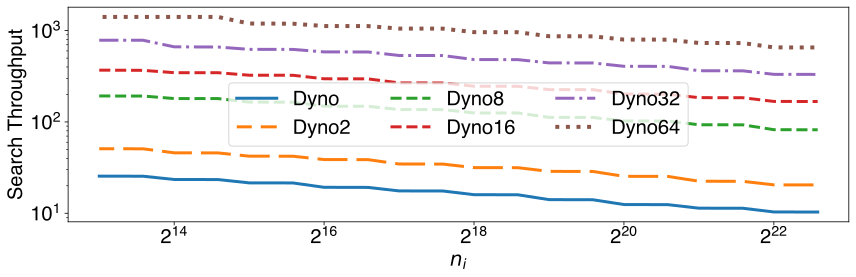

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


55.380396431614486	60.810041153557705	64.37792104623901
6291456 63.298857071411106
Insert
plots_usenix/insert_1i1s_tput_threaded_sgx_0ms.eps


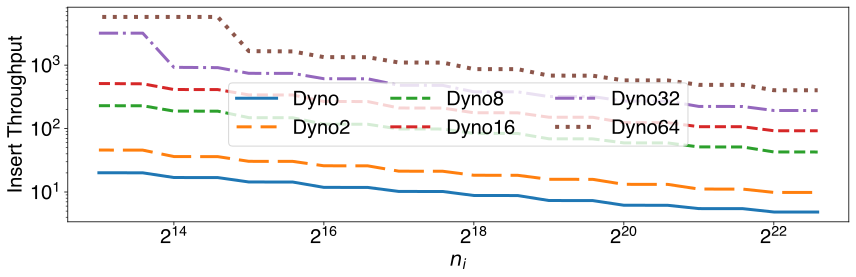

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


83.09208625184448	125.9363466035169	340.83094306788036
6291456 83.09208625184448
Search
plots_usenix/search_1i1s_tput_threaded_sgx_0ms.eps


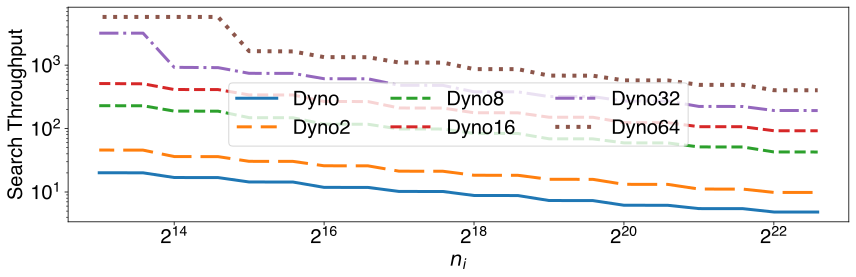

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


83.09208625184448	125.9363466035169	340.83094306788036
6291456 83.09208625184448
Insert
plots_usenix/insert_1i4s_tput_threaded_sgx_0ms.eps


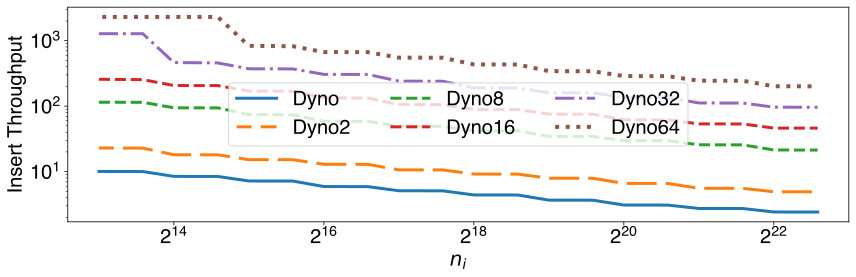

83.09208625184428	118.38089124347516	272.6647544543042
6291456 83.09208625184428
Search
plots_usenix/search_1i4s_tput_threaded_sgx_0ms.eps


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


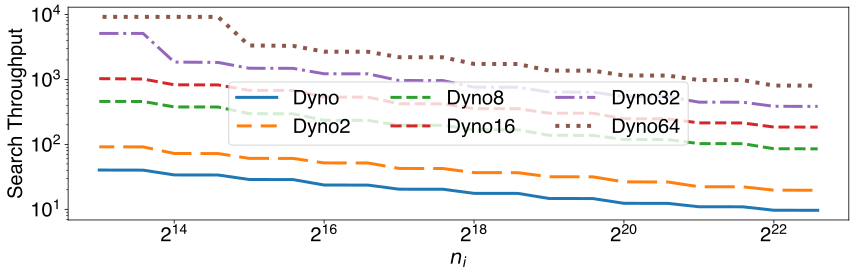

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


83.09208625184428	118.38089124347516	272.6647544543042
6291456 83.09208625184428
Insert
plots_usenix/insert_1i20s_tput_threaded_sgx_0ms.eps


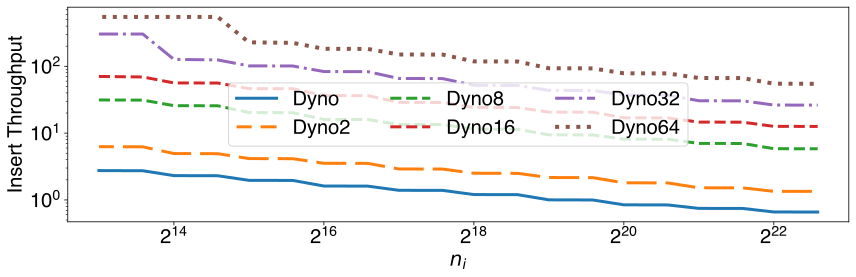

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


83.09208625184425	114.56011220464	238.04065865058303
6291456 83.09208625184425
Search
plots_usenix/search_1i20s_tput_threaded_sgx_0ms.eps


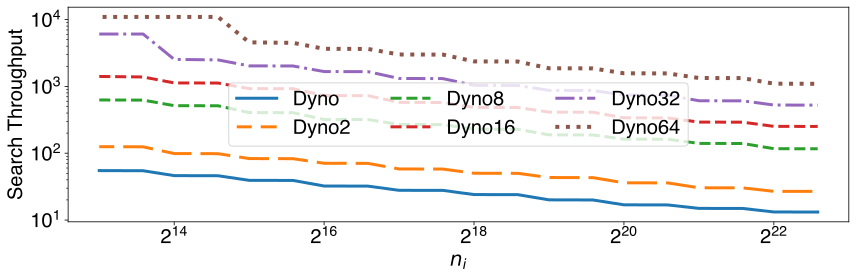

83.09208625184425	114.56011220464	238.04065865058305
6291456 83.09208625184425


In [264]:
scheme = 'Dyno'
figsize = (12, 4)
fontsize = 20
largefont = 20
lw = 3.0
largelw = 4

# for rtt in (0.02,):
for rtt in (0.02, 0.):
  for pattern in patterns:
    for op in ops:
      if op not in pattern:
        continue
      opname = opnames[op]
      print(opname)
      run1 = sims[scheme](op).do(pattern, opcount // len(pattern))
      runs = {f'{scheme}{tc if tc > 1 else ""}': make_threaded_run(run1, tc)
              for tc in thread_counts}

      # stats(runs)
      plotruns(f'{opname}_{pattern.count("i")}i{pattern.count("s")}s', runs, rtt)
      commonkeys = [k for k in runs[f'Dyno{max(thread_counts)}']
                    if k in runs['Dyno']]
      rat = [runs[f'Dyno{max(thread_counts)}'][k] / runs['Dyno'][k]
             for k in sorted(commonkeys)]
      print(np.min(rat), np.average(rat), np.max(rat), sep='\t')
      print(max(commonkeys), rat[-1])
      # break

## Latencies (SGX)

In [ ]:
fig, ax1 = plt.subplots(figsize=(3.75, 3))
bs = mbs[0]
lw = 1.5
ndf = netsimcol(nomap_ram[bs], 'delete')
# sdf = netsimcol(somap_ram[bs], 'delete')
ddf = netsimcol(domap_ram[bs], 'delete')
ax1.plot(gte_cutoff(ndf)['n'], gte_cutoff(ndf)['delete'],
         label=f'Naive OMap', linestyle='-', color='#FF6666', lw=lw, marker='')
ax1.plot(gte_cutoff(ddf)['n'], gte_cutoff(ddf)['delete'],
         label=f'DynOMap', linestyle='-', color='green', lw=lw, marker='')

ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
xticks = [2**x for x in range(6, 28, 3)]
ax1.set_xticks(xticks)
ax1.set_xlim((xticks[0], xticks[-1]))
ax1.set_xlabel(f'$n_i$', fontsize=14)
ax1.set_ylabel('Delete Time (second)', fontsize=12)
ax1.tick_params(axis='x', labelsize=12)
ax1.tick_params(axis='y', labelsize=12)
ax1.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.savefig('plots_usenix/local-omap_delete.eps', bbox_inches='tight')
plt.show()

# div = gte_cutoff(ddf)['delete'].to_numpy() / \
#     gte_cutoff(sdf)['delete'].to_numpy()
# print(div.min(), div.max(), div.mean())

#### YCSB

##### Utils

In [99]:
import random


class WLGen:
  def __init__(self, dists) -> None:
    self.dists = dists

  def genOne(self):
    u = random.uniform(0, 1)
    s = 0
    for op, w in self.dists.items():
      s += w
      if u <= s:
        return op
    return None

  def gen(self, n):
    while n != 0:
      n -= 1
      yield self.genOne()

  def genAll(self, n):
    return [x for x in self.gen(n)]


class SimYcsb:
  def __init__(self, n: int, wlgen) -> None:
    self.n = n
    self.wlgen = wlgen
    self.offset = 0
    self.res = []

  def __do_sgx(self, act: str) -> None:
    if len(act) != 1:
      raise Exception(f'Bad action size: {act}')
    if act not in op_mults.keys():
      raise Exception(f'Bad action type: {act}')

    r = rtt
    times = sgxtime(self.n)
    if times[0] > 0:
      mults = op_mults[act]
      for t, m in zip(times, mults):
        r += t * m
    else:
      r += times[1]
    self.n += n_diffs[act]
    return r

  def __do_naive(self, act: str) -> None:
    if len(act) != 1:
      raise Exception(f'Bad action size: {act}')
    if act not in op_mults.keys():
      raise Exception(f'Bad action type: {act}')

    n0 = self.n
    self.n += n_diffs[act]
    n1 = self.n

    if act == 's':
      return rtt + idealsgxtime(n0)
    if act == 'd':
      return rtt + naivesgxtime(n1)
    return rtt + naivesgxtime(n0)

  def do(self, isNaive: bool = False, maxtodo: int = -1):
    done = 0
    for act in self.wlgen():
      if isNaive:
        self.res.append(self.__do_naive(act))
      else:
        self.res.append(self.__do_sgx(act))
      self.offset += 1
      if self.n >= N:
        break
      done += 1
      if done == maxtodo:
        break
    return np.array(self.res)

In [114]:
import itertools

fontsize = 13
largefont = 15
lw = 2.5
largelw = 4
opcount = 101
lss = {
    'A': '-',
    'D': ':',
}
default_ls = '--'
lcs = {
    'Naive': '#FF6666',
    'Dyno': 'g',
    # 'Ideal': 'b',
}
# patterns = ['s', 'i', 'is', 'issss', 'i'+((opcount-1)*'s')]
schemes = ['Naive', 'Dyno']
sims = {
    'Naive': SimNaive,
    'Dyno': SimSgx,
    # 'Ideal': SimIdeal,
}
rtt = 0.2  # 20ms
ops = list('is')
figsize = (5, 4)
opnames = {'i': 'Insert', 's': 'Search'}
markers = {
    'Naive': '',
    'Dyno': '',
}


def plotycsb(name, runs):
  miny = 100.
  maxy = 0.
  _, ax = plt.subplots(figsize=figsize)
  lens = {len(run) for run in runs.values()}
  if len(lens) != 1:
    raise Exception(f'bad runs: {lens}')
  for group, run in runs.items():
    scheme = group.split()[0]
    ratio = group.split()[-1]
    x, y = zip(*sorted(run.items()))
    miny = float(min(miny, min(y)))
    maxy = float(max(maxy, max(y)))
    if x[-1] == N:
      x, y = x[:-1], y[:-1]
    lc = lcs[scheme]
    marker = markers[scheme]
    ls = lss.get(ratio, default_ls)
    ax.plot(x, y, label=group, lw=lw if ls != ':' else largelw,
            color=lc, linestyle=ls, marker=marker)

  ax.set_xlabel(f'$n_i$',                           fontsize=largefont)
  ax.set_ylabel(f'{name} Throughput (op / second)', fontsize=largefont)
  ax.tick_params(axis='x', which='both',           labelsize=largefont)
  ax.tick_params(axis='y', which='both',           labelsize=largefont)
  xticks = [2**x for x in range(6, 23, 3)]
  xlims = (2**6, 2**23)
  # ylims = ax.get_ylim()
  # print(ylims)
  # ax.set_ylim((miny/10, 2*maxy))
  ax.set_xticks(xticks)
  # ax.set_xlim((xticks[0], xticks[-1]))
  ax.set_xlim(xlims)
  ax.set_xscale('log', base=2)
  ax.set_yscale('log', base=10)
  ax.legend(loc='lower left', fontsize=fontsize, ncols=2)
  plt.tight_layout()
  plt.savefig(
      f'plots_usenix/ycsb_{name.lower()}_tput_sgx.eps', bbox_inches='tight')
  print(f'plots_usenix/ycsb_{name.lower()}_tput_sgx.eps')
  plt.show()


def stats(runs):
  mains = 'Dyno'
  run_dfs = {g: pd.DataFrame(
      r, index=('n', 'tput')).T for g, r in runs.items()}
  ratios = {g.split()[-1] for g in runs}
  todiv = {s for s in schemes if s != mains}
  for s, r in itertools.product(todiv, ratios):
    bymains = run_dfs[f'{s} - {r}']['tput'] / run_dfs[f'{mains} - {r}']['tput']
    mainsby = 1 / bymains
    print(f'{s=}, {r=}, by {mains}: {bymains.min()}-{bymains.mean()}-{bymains.max()} --- '
          f'{mains} by: {mainsby.min()}-{mainsby.mean()}-{mainsby.max()}')

##### Run

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


i {'Naive - D': {132: 0.1951358502225883, 256: 0.19269377157206768, 384: 0.1951358502225883, 512: 0.1894813858011249, 768: 0.1941980713256417, 1024: 0.1814071920605866, 1536: 0.19360533888638065, 2048: 0.1666033171668145, 3072: 0.19246553532890892, 4096: 0.1373188263852467, 6144: 0.1910019970543278, 8192: 0.09521114615389323, 12288: 0.18924777040175902, 16384: 0.05407220408108823, 24576: 0.18816356846758403, 32768: 0.02843941365895766, 49152: 0.18616210435419978, 65536: 0.012836499315572344, 98304: 0.18376995785100467, 131072: 0.005496703477633967, 196608: 0.18232135868512864, 262144: 0.002516201639512828, 393216: 0.17945579127735217, 524288: 0.0010556862821910241, 786432: 0.17615658539145893, 1048576: 0.0004414685011428224, 1572864: 0.17279778762430614, 2097152: 0.00018796373942748477, 3145728: 0.1708589228492918, 4194304: 8.634407928199961e-05, 6291456: 0.1669535876067723}, 'Dyno - D': {132: 0.1951358502225883, 256: 0.1951358502225883, 384: 0.1951358502225883, 512: 0.191594895737626,

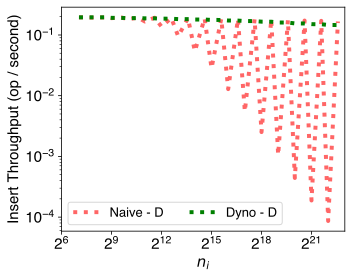

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


s {'Naive - A': {132: 4.927180218120355, 256: 4.927180218120355, 384: 4.927180218120355, 512: 4.927180218120355, 768: 4.903501300972453, 1024: 4.903501300972453, 1536: 4.888534806881112, 2048: 4.888534806881112, 3072: 4.85975476705495, 4096: 4.85975476705495, 6144: 4.822800425621777, 8192: 4.822800425621777, 12288: 4.778506202644415, 16384: 4.778506202644415, 24576: 4.751130103806497, 32768: 4.751130103806497, 49152: 4.700593134943545, 65536: 4.700593134943545, 98304: 4.640191435737868, 131072: 4.640191435737868, 196608: 4.603614306799498, 262144: 4.603614306799498, 393216: 4.531258729753143, 524288: 4.531258729753143, 786432: 4.447953781134339, 1048576: 4.447953781134339, 1572864: 4.36314413751373, 2097152: 4.36314413751373, 3145728: 4.314187801944618, 4194304: 4.314187801944618, 6291456: 4.215578087071001}, 'Naive - D': {132: 4.732044367897767, 256: 4.672823960622641, 384: 4.732044367897767, 512: 4.594923605677279, 768: 4.709303229646811, 1024: 4.399124407469225, 1536: 4.694929467994

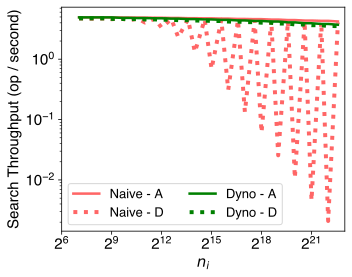

In [115]:
gens = {
    'a': WLGen({
        's': 1.0,
    }),
    'd': WLGen({
        'i': 0.05,
        's': 0.95,
    }),
}

wls = {
    'A': ''.join(gens['a'].genAll(opcount)),
    'D': ''.join(gens['d'].genAll(opcount)),
}

for op in ops:
  opname = opnames[op]
  runs = {
      f'{scheme} - {wl}':
      sims[scheme](op).do(pattern, 1)
      for scheme, (wl, pattern) in itertools.product(schemes, wls.items()) if op in pattern
  }
  print(op, runs)
  stats(runs)
  plotycsb(opname, runs)

#### Latencies

In [42]:
def plotlatrun(group: str, runs, naiveruns, idealruns, sgx=True) -> None:
  print(group)
  _, ax1 = plt.subplots(figsize=(8, 3))

  l = [x for x in runs.items() if len(x[1])]
  nl = [x for x in naiveruns.items() if len(x[1])]
  il = [x for x in idealruns.items() if len(x[1])]

  batches = [
      {'dfs': l, 'prefix': 'Dyno', 'lc': 'g', 'ls': '-', 'ms': ''},
      {'dfs': nl, 'prefix': 'Naive', 'lc': 'r', 'ls': ':', 'ms': 's'},
      {'dfs': il, 'prefix': 'Ideal', 'lc': 'b', 'ls': '-', 'ms': ''},
  ]

  for batch in batches:
    lc = batch['lc']
    ls = batch['ls']
    ms = batch['ms']
    for op, run in batch['dfs']:
      label = f'{batch["prefix"]}'
      x, y = zip(*sorted(run.items()))
      y = 1 / np.array(y)  # Throughput to Latency
      ax1.plot(x, y, label=label, lw=1.5, color=lc, linestyle=ls, marker=ms)

  ax1.set_xlabel(f'$n_i$', fontsize=14, labelpad=5)
  ax1.set_ylabel('Time', fontsize=11, labelpad=10)
  ax1.tick_params(axis='x', which='both', labelsize=12)
  ax1.tick_params(axis='y', which='both', labelsize=11)
  ax1.set_xscale('log', base=2)
  ax1.set_yscale('log')
  ax1.grid()
  ax1.legend(loc='upper left', fontsize=12)
  plt.tight_layout()
  plt.savefig(
      f'plots_usenix/latency_{group.replace(":", "-").replace(" ", "")}_{"no" if not sgx else ""}sgx.eps', bbox_inches='tight')
  plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Local (SGX) - Insert Time


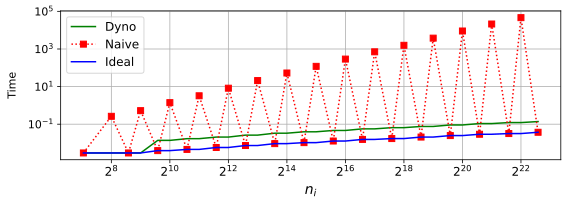

Local (SGX) - Delete Time


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


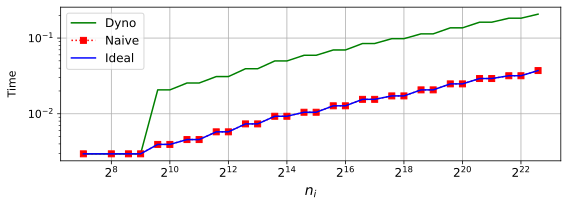

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Local (SGX) - Search Time


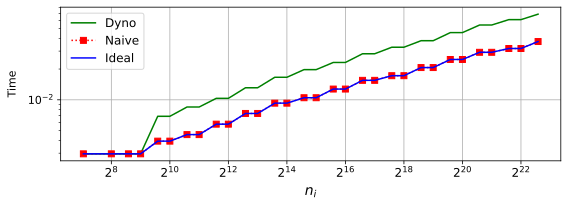

100.0 ms (SGX) - Insert Time


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


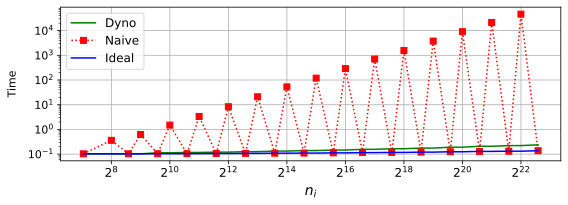

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


100.0 ms (SGX) - Delete Time


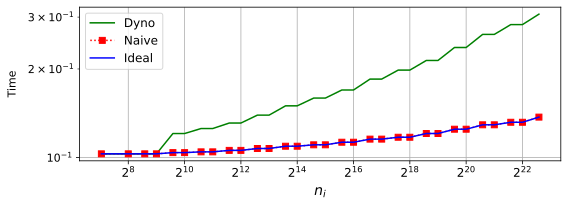

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


100.0 ms (SGX) - Search Time


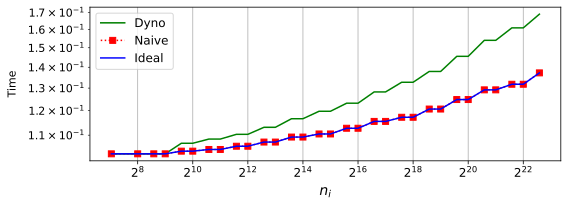

In [43]:
rtts = [0, 0.1]
patterns = {'i': 'Insert', 'd': 'Delete', 's': 'Search'}
reps = 1

for rtt in rtts:
  for op, pname in patterns.items():
    group = f'{"Local" if rtt == 0 else f"{rtt * 1000} ms"} (SGX) - {pname} Time'
    runs = {op: SimSgx(op).do(op, reps)}
    nruns = {op: SimNaive(op).do(op, reps)}
    iruns = {op: SimIdeal(op).do(op, reps)}
    plotlatrun(group, runs, nruns, iruns)

# VLDB

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


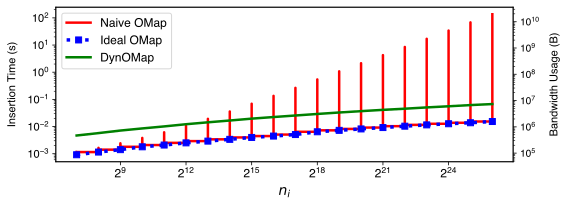

In [36]:
fig, ax1 = plt.subplots(figsize=(8, 3))
show_bw = False
ax2 = ax1.twinx()
bs = mbs[0]

ls, ms = '-', ''
ax1.plot(gte_cutoff(nomap_ram[bs])['n'], gte_cutoff(nomap_ram[bs])[
         'insert'], label=f'Naive OMap', linestyle=ls, marker=ms, color='red', lw=2.5)
if not show_bw:
  ls, ms = '', ''
ax2.plot(gte_cutoff(nomap_ram[bs])['n'], gte_cutoff(nomap_ram[bs])[
         'insert_bytes'], label=f'Naive OMap', linestyle=ls, marker=ms, color='red')

ls, ms = ':', 's'
ax1.plot(gte_cutoff(somap_ram[bs])['n'], gte_cutoff(somap_ram[bs])[
         'insert'], label=f'Ideal OMap', linestyle=ls, color='blue', marker=ms, lw=3.5)
if not show_bw:
  ls, ms = '', ''
ax2.plot(gte_cutoff(somap_ram[bs])['n'], gte_cutoff(somap_ram[bs])[
         'insert_bytes'], label=f'Naive OMap', linestyle=ls, marker=ms, color='blue')

ls, ms = '-', ''
ax1.plot(gte_cutoff(domap_ram[bs])['n'], gte_cutoff(domap_ram[bs])[
         'insert'], label=f'DynOMap', linestyle=ls, marker=ms, color='green', lw=2.5)
if not show_bw:
  ls, ms = '', ''
ax2.plot(gte_cutoff(domap_ram[bs])['n'], gte_cutoff(domap_ram[bs])[
         'insert_bytes'], label=f'DynoMap', linestyle=ls, marker=ms, color='green', lw=2.5)


ax1.set_xlabel(f'$n_i$', fontsize=14, labelpad=5)
ax1.set_ylabel('Insertion Time (s)', fontsize=11, labelpad=10)
ax2.set_ylabel('Bandwidth Usage (B)', fontsize=11, labelpad=10)
ax1.tick_params(axis='x', which='both', labelsize=12)
ax1.tick_params(axis='y', which='both', labelsize=11)
ax2.tick_params(axis='y', which='both', labelsize=10)
ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
ax2.set_yscale('log')
ax1.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.savefig('plots_vldb/omap_insert.eps', bbox_inches='tight')
plt.show()

In [45]:
div = gte_cutoff(domap_ram[bs])['insert'].to_numpy(
) / gte_cutoff(somap_ram[bs])['insert'].to_numpy()
print(div.min(), div.max(), div.mean())
print(
    gte_cutoff(nomap_ram[bs])['insert_bytes'][gte_cutoff(
        nomap_ram[bs])['n'] == 67108864],
    gte_cutoff(domap_ram[bs])['insert_bytes'][gte_cutoff(
        domap_ram[bs])['n'] == 67108864]
)

4.3913832614074835 5.112230994969257 4.727665367536236
16777215    1.932853e+10
Name: insert_bytes, dtype: float64 743    5054400
Name: insert_bytes, dtype: int64


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


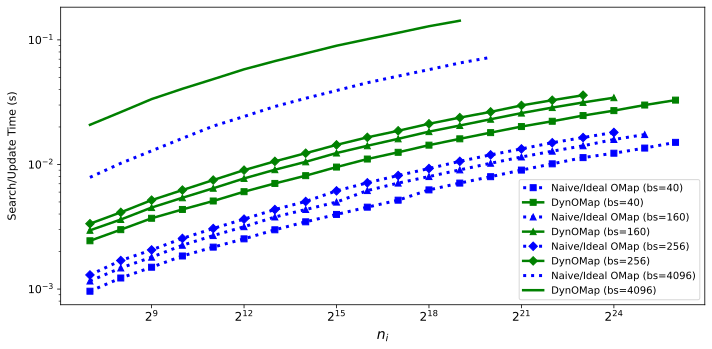

2.540086382341276 2.641103383129299
2.165708413713104 2.641103383129299


In [46]:
# Map Search Times

fig, ax1 = plt.subplots(figsize=(10, 5))

markers = ['s', '^', 'D', '']

mino, maxo = None, None
minl, maxl = None, None

for idx, bs in enumerate(mbs):
  bs = mbs[idx]
  ax1.plot(gte_cutoff(somap_ram[bs])['n'], gte_cutoff(somap_ram[bs])[
           'search'], label=f'Naive/Ideal OMap (bs={bss[idx]})', linestyle=':', color='blue', marker=markers[idx], lw=3)
  ax1.plot(gte_cutoff(domap_ram[bs])['n'], gte_cutoff(domap_ram[bs])[
           'search'], label=f'DynOMap (bs={bss[idx]})', linestyle='-', color='green', marker=markers[idx], lw=2.5)
  dd = gte_cutoff(domap_ram[bs])['search'].to_numpy()
  ss = gte_cutoff(somap_ram[bs])['search'].to_numpy()
  m = (dd[0] / ss[0])
  if not mino or mino > m.min():
    mino = m.min()
  if not maxo or maxo < m.max():
    maxo = m.max()
  ll = min(len(dd), len(ss))
  mm = dd[:ll] / ss[:ll]
  mi, ma = mm.min(), mm.max()
  if not minl or minl > mi:
    minl = mi
  if not maxl or maxl < ma:
    maxl = ma


ax1.set_xlabel(f'$n_i$', fontsize=14, labelpad=5)
ax1.set_ylabel('Search/Update Time (s)', fontsize=11, labelpad=10)
ax1.tick_params(axis='x', which='both', labelsize=12)
ax1.tick_params(axis='y', which='both', labelsize=11)
ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
# ax1.legend(loc='lower right', fontsize=12)
# ax1.legend(loc='upper left')
ax1.legend(loc='lower right')

plt.tight_layout()
plt.savefig('plots_vldb/omap_search_update.eps', bbox_inches='tight')
plt.show()
print(mino, maxo)
print(minl, maxl)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


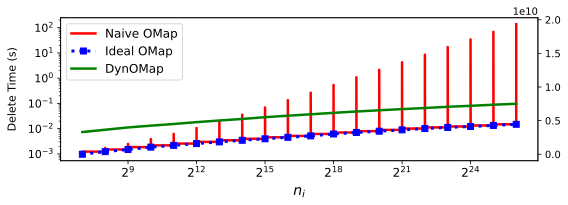

6.489469131580535 7.579325379180871 6.942386475883225


In [47]:
fig, ax1 = plt.subplots(figsize=(8, 3))
ax2 = ax1.twinx()
bs = mbs[0]
ax1.plot(gte_cutoff(nomap_ram[bs])['n'], gte_cutoff(nomap_ram[bs])[
         'delete'], label=f'Naive OMap', linestyle='-', color='red', lw=2.5)
ax2.plot(gte_cutoff(nomap_ram[bs])['n'], gte_cutoff(nomap_ram[bs])[
         'delete_bytes'], label=f'Naive OMap', linestyle='', color='red')
ax1.plot(gte_cutoff(somap_ram[bs])['n'], gte_cutoff(somap_ram[bs])[
         'delete'], label=f'Ideal OMap', linestyle=':', color='blue', marker='s', lw=3)
ax2.plot(gte_cutoff(somap_ram[bs])['n'], gte_cutoff(somap_ram[bs])[
         'delete_bytes'], label=f'Ideal OMap', linestyle='', color='blue', marker='', lw=3)
ax1.plot(gte_cutoff(domap_ram[bs])['n'], gte_cutoff(domap_ram[bs])[
         'delete'], label=f'DynOMap', linestyle='-', color='green', lw=2.5)
ax2.plot(gte_cutoff(domap_ram[bs])['n'], gte_cutoff(domap_ram[bs])[
         'delete_bytes'], label=f'DynOMap', linestyle='', color='green', lw=2.5)

ax1.set_xlabel(f'$n_i$', fontsize=14, labelpad=5)
ax1.set_ylabel('Delete Time (s)', fontsize=11, labelpad=10)
# ax2.set_ylabel('Bandwidth Usage (B)', fontsize=11, labelpad=10)
ax1.tick_params(axis='x', which='both', labelsize=12)
ax1.tick_params(axis='y', which='both', labelsize=11)
# ax2.tick_params(axis='y', which='both', labelsize=10)
ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
ax1.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.savefig('plots_vldb/omap_delete.eps', bbox_inches='tight')
plt.show()

div = gte_cutoff(domap_ram[bs])['delete'].to_numpy(
) / gte_cutoff(somap_ram[bs])['delete'].to_numpy()
print(div.min(), div.max(), div.mean())

## VLDB Appendix
### RAM

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


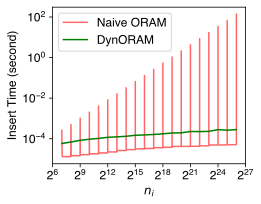

In [48]:
fig, ax1 = plt.subplots(figsize=(3.75, 3))
# ax2 = ax1.twinx()
lw = 1.5
fontsize = 12
bs = rbs[0]
show_bw_lines = False
bw_ls = '-.' if show_bw_lines else ''
ax1.plot(gte_cutoff(noram[bs])['n'], gte_cutoff(noram[bs])[
         'insert'], label=f'Naive ORAM', linestyle='-', color='#FF6666', lw=lw, marker='')
ax1.plot(gte_cutoff(doram[bs])['n'], gte_cutoff(doram[bs])[
         'insert'], label=f'DynORAM', linestyle='-', color='green', lw=lw, marker='')

ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
xticks = [2**x for x in range(6, 28, 3)]
ax1.set_xticks(xticks)
ax1.set_xlim((xticks[0], xticks[-1]))
ax1.set_xlabel(f'$n_i$', fontsize=fontsize)
ax1.set_ylabel('Insert Time (second)', fontsize=fontsize)
# ax2.set_ylabel('Bandwidth Usage (B)', fontsize=11, labelpad=10)
ax1.tick_params(axis='x', labelsize=fontsize)
ax1.tick_params(axis='y', labelsize=fontsize)
# ax2.tick_params(axis='y', which='both', labelsize=10)
# ax2.set_yscale('log')
ax1.legend(loc='upper left', fontsize=fontsize)
# ax2.legend()
plt.tight_layout()
plt.savefig('plots_vldb/oram_insert.eps', bbox_inches='tight')
plt.show()

In [38]:
div = gte_cutoff(doram[bs])['insert'].to_numpy() / \
    gte_cutoff(soram[bs])['insert'].to_numpy()
print(div.min(), div.max(), div.mean())

4.673532957000155 5.899665551839465 5.297949956945889


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


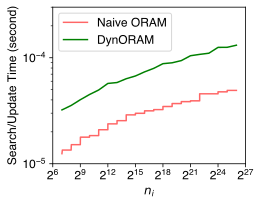

In [44]:
fig, ax1 = plt.subplots(figsize=(3.75, 3))
# ax2 = ax1.twinx()
lw = 1.5
fontsize = 12
bs = rbs[0]
show_bw_lines = False
bw_ls = '-.' if show_bw_lines else ''
ax1.plot(gte_cutoff(noram[bs])['n'], gte_cutoff(noram[bs])[
         'search'], label=f'Naive ORAM', linestyle='-', color='#FF6666', lw=lw, marker='')
ax1.plot(gte_cutoff(doram[bs])['n'], gte_cutoff(doram[bs])[
         'search'], label=f'DynORAM', linestyle='-', color='green', lw=lw, marker='')

ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
xticks = [2**x for x in range(6, 28, 3)]
ax1.set_xticks(xticks)
ax1.set_xlim((xticks[0], xticks[-1]))
ax1.set_ylim((1E-5, 3E-4))
ax1.set_xlabel(f'$n_i$', fontsize=fontsize)
ax1.set_ylabel('Search/Update Time (second)', fontsize=fontsize)
# ax2.set_ylabel('Bandwidth Usage (B)', fontsize=11, labelpad=10)
ax1.tick_params(axis='x', labelsize=fontsize)
ax1.tick_params(axis='y', labelsize=fontsize)
# ax2.tick_params(axis='y', which='both', labelsize=10)
# ax2.set_yscale('log')
ax1.legend(loc='upper left', fontsize=fontsize)
# ax2.legend()
plt.tight_layout()
plt.savefig('plots_vldb/oram_search_update.eps', bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


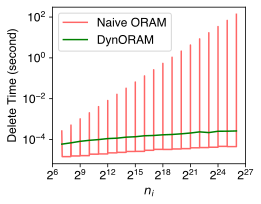

In [47]:
fig, ax1 = plt.subplots(figsize=(3.75, 3))
# ax2 = ax1.twinx()
lw = 1.5
fontsize = 12
bs = rbs[0]
show_bw_lines = False
bw_ls = '-.' if show_bw_lines else ''
ax1.plot(gte_cutoff(noram[bs])['n'], gte_cutoff(noram[bs])[
         'delete'], label=f'Naive ORAM', linestyle='-', color='#FF6666', lw=lw, marker='')
ax1.plot(gte_cutoff(doram[bs])['n'], gte_cutoff(doram[bs])[
         'delete'], label=f'DynORAM', linestyle='-', color='green', lw=lw, marker='')

ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
xticks = [2**x for x in range(6, 28, 3)]
ax1.set_xticks(xticks)
ax1.set_xlim((xticks[0], xticks[-1]))
# ax1.set_ylim((1E-5, 3E-4))
ax1.set_xlabel(f'$n_i$', fontsize=fontsize)
ax1.set_ylabel('Delete Time (second)', fontsize=fontsize)
# ax2.set_ylabel('Bandwidth Usage (B)', fontsize=11, labelpad=10)
ax1.tick_params(axis='x', labelsize=fontsize)
ax1.tick_params(axis='y', labelsize=fontsize)
# ax2.tick_params(axis='y', which='both', labelsize=10)
# ax2.set_yscale('log')
ax1.legend(loc='upper left', fontsize=fontsize)
# ax2.legend()
plt.tight_layout()
plt.savefig('plots_vldb/oram_delete.eps', bbox_inches='tight')
plt.show()

### Heap

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


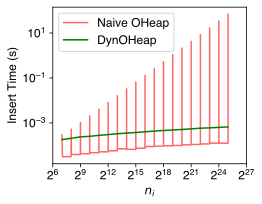

In [49]:
fig, ax1 = plt.subplots(figsize=(3.75, 3))
lw = 1.5
fontsize = 12
bs = hbs[0]
ax1.plot(lte_cutoff(gte_cutoff(noheap[bs]), 2**25)['n'], lte_cutoff(gte_cutoff(
    noheap[bs]), 2**25)['insert'], label=f'Naive OHeap', linestyle='-', color='#FF6666', lw=lw)
ax1.plot(lte_cutoff(gte_cutoff(doheap[bs]), 2**25)['n'], lte_cutoff(gte_cutoff(
    doheap[bs]), 2**25)['insert'], label=f'DynOHeap', linestyle='-', color='green', lw=lw)

ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
xticks = [2**x for x in range(6, 28, 3)]
ax1.set_xticks(xticks)
ax1.set_xlim((xticks[0], xticks[-1]))
ax1.set_xlabel(f'$n_i$',                 fontsize=fontsize)
ax1.set_ylabel('Insert Time (s)',        fontsize=fontsize)
ax1.tick_params(axis='x', which='both', labelsize=fontsize)
ax1.tick_params(axis='y', which='both', labelsize=fontsize)
ax1.legend(loc='upper left', fontsize=fontsize)
plt.tight_layout()
plt.savefig('plots_vldb/oheap_insert.eps', bbox_inches='tight')
plt.show()

In [53]:
x1 = gte_cutoff(doheap[bs])['insert'].to_numpy()
x2 = gte_cutoff(soheap[bs])['insert'].to_numpy()
xl = min(len(x1), len(x2))

div = x1[:xl] / x2[:xl]
print(div.min(), div.max(), div.mean())

4.13786782396693 6.56629099658098 5.378682008372997


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


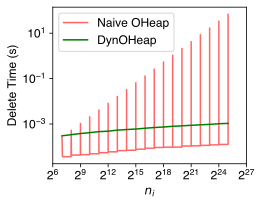

In [63]:
fig, ax1 = plt.subplots(figsize=(3.75, 3))
lw = 1.5
fontsize = 12
bs = hbs[0]
ax1.plot(lte_cutoff(gte_cutoff(noheap[bs]), 2**25)['n'], lte_cutoff(gte_cutoff(
    noheap[bs]), 2**25)['delete'], label=f'Naive OHeap', linestyle='-', color='#FF6666', lw=lw)
ax1.plot(lte_cutoff(gte_cutoff(doheap[bs]), 2**25)['n'], lte_cutoff(gte_cutoff(
    doheap[bs]), 2**25)['delete'], label=f'DynOHeap', linestyle='-', color='green', lw=lw)

ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
xticks = [2**x for x in range(6, 28, 3)]
ax1.set_xticks(xticks)
ax1.set_xlim((xticks[0], xticks[-1]))
# ax1.set_ylim((3E-5, 2E-3))
ax1.set_xlabel(f'$n_i$',                 fontsize=fontsize)
ax1.set_ylabel('Delete Time (s)',        fontsize=fontsize)
ax1.tick_params(axis='x', which='both', labelsize=fontsize)
ax1.tick_params(axis='y', which='both', labelsize=fontsize)
ax1.legend(loc='upper left', fontsize=fontsize)
plt.tight_layout()
plt.savefig('plots_vldb/oheap_delete.eps', bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


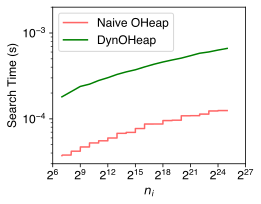

In [64]:
fig, ax1 = plt.subplots(figsize=(3.75, 3))
lw = 1.5
fontsize = 12
bs = hbs[0]
ax1.plot(lte_cutoff(gte_cutoff(noheap[bs]), 2**25)['n'], lte_cutoff(gte_cutoff(
    noheap[bs]), 2**25)['search'], label=f'Naive OHeap', linestyle='-', color='#FF6666', lw=lw)
ax1.plot(lte_cutoff(gte_cutoff(doheap[bs]), 2**25)['n'], lte_cutoff(gte_cutoff(
    doheap[bs]), 2**25)['insert'], label=f'DynOHeap', linestyle='-', color='green', lw=lw)

ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
xticks = [2**x for x in range(6, 28, 3)]
ax1.set_xticks(xticks)
ax1.set_xlim((xticks[0], xticks[-1]))
ax1.set_ylim((3E-5, 2E-3))
ax1.set_xlabel(f'$n_i$',                 fontsize=fontsize)
ax1.set_ylabel('Search Time (s)',        fontsize=fontsize)
ax1.tick_params(axis='x', which='both', labelsize=fontsize)
ax1.tick_params(axis='y', which='both', labelsize=fontsize)
ax1.legend(loc='upper left', fontsize=fontsize)
plt.tight_layout()
plt.savefig('plots_vldb/oheap_search.eps', bbox_inches='tight')
plt.show()

### LazyPathORAM

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


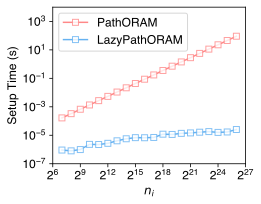

2.5400863827077607 2.6411033776577466
None None


In [158]:
fig, ax1 = plt.subplots(figsize=(3.75, 3))
lw = 1.5
fontsize = 12

minl, maxl = None, None

bs = rbs[0]
ax1.plot(gte_cutoff(soram[bs])['n'], gte_cutoff(soram[bs])['alloc'] + gte_cutoff(soram[bs])['init'],
         label=f'PathORAM', linestyle='-', marker='s', mfc=(1, 1, 1, .8), color='#ff8888', lw=lw)
ax1.plot(gte_cutoff(soram[bs])['n'], gte_cutoff(soram[bs])['alloc'],
         label=f'LazyPathORAM', linestyle='-', marker='s', mfc=(1, 1, 1, .8), color='#66b2f1', lw=lw)

ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
xticks = [2**x for x in range(6, 28, 3)]
ax1.set_xticks(xticks)
ax1.set_xlim((xticks[0], xticks[-1]))
ax1.set_ylim((1E-7, 1E4))
ax1.set_xlabel(f'$n_i$',                 fontsize=fontsize)
ax1.set_ylabel('Setup Time (s)',         fontsize=fontsize)
ax1.tick_params(axis='x', which='both', labelsize=fontsize)
ax1.tick_params(axis='y', which='both', labelsize=fontsize)
ax1.legend(loc='upper left', fontsize=fontsize)

plt.tight_layout()
plt.savefig('plots_vldb/lazy_path_oram_setup.eps', bbox_inches='tight')
plt.show()
print(mino, maxo)
print(minl, maxl)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


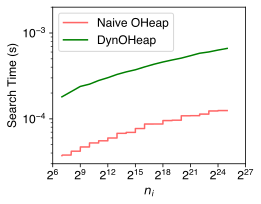

In [ ]:
fig, ax1 = plt.subplots(figsize=(3.75, 3))
lw = 1.5
fontsize = 12
bs = hbs[0]
ax1.plot(lte_cutoff(gte_cutoff(noheap[bs]), 2**25)['n'], lte_cutoff(gte_cutoff(
    noheap[bs]), 2**25)['search'], label=f'Naive OHeap', linestyle='-', color='#FF6666', lw=lw)
ax1.plot(lte_cutoff(gte_cutoff(doheap[bs]), 2**25)['n'], lte_cutoff(gte_cutoff(
    doheap[bs]), 2**25)['insert'], label=f'DynOHeap', linestyle='-', color='green', lw=lw)

ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
xticks = [2**x for x in range(6, 28, 3)]
ax1.set_xticks(xticks)
ax1.set_xlim((xticks[0], xticks[-1]))
ax1.set_ylim((3E-5, 2E-3))
ax1.set_xlabel(f'$n_i$',                 fontsize=fontsize)
ax1.set_ylabel('Search Time (s)',        fontsize=fontsize)
ax1.tick_params(axis='x', which='both', labelsize=fontsize)
ax1.tick_params(axis='y', which='both', labelsize=fontsize)
ax1.legend(loc='upper left', fontsize=fontsize)
plt.tight_layout()
plt.savefig('plots_vldb/oheap_search.eps', bbox_inches='tight')
plt.show()

### Stack/Queue

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


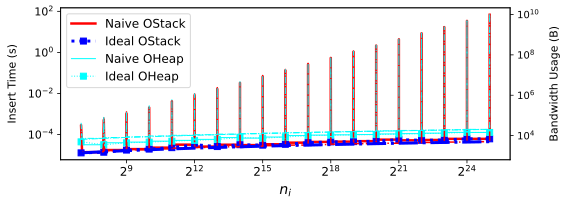

In [57]:
fig, ax1 = plt.subplots(figsize=(8, 3))
ax2 = ax1.twinx()
bs = hbs[0]
show_bw_lines = True
bw_ls = '-.' if show_bw_lines else ''

ax1.plot(lte_cutoff(gte_cutoff(nostack[bs]), 2**25)['n'], lte_cutoff(gte_cutoff(
    nostack[bs]), 2**25)['insert'], label=f'Naive OStack', linestyle='-', color='red', lw=2.5)
ax2.plot(lte_cutoff(gte_cutoff(nostack[bs]), 2**25)['n'], lte_cutoff(gte_cutoff(
    nostack[bs]), 2**25)['insert_bytes'], label=f'Naive OStack', linestyle=bw_ls, color='red')
ax1.plot(lte_cutoff(gte_cutoff(sostack[bs]), 2**25)['n'], lte_cutoff(gte_cutoff(sostack[bs]), 2**25)[
         'insert'], label=f'Ideal OStack', linestyle=':', color='blue', marker='s', lw=3)
ax2.plot(lte_cutoff(gte_cutoff(sostack[bs]), 2**25)['n'], lte_cutoff(gte_cutoff(sostack[bs]), 2**25)[
         'insert_bytes'], label=f'Ideal OStack', linestyle=bw_ls, color='blue', marker='', lw=3)

ax1.plot(lte_cutoff(gte_cutoff(noheap[bs]), 2**25)['n'], lte_cutoff(gte_cutoff(
    noheap[bs]), 2**25)['insert'], label=f'Naive OHeap', linestyle='-', color='cyan', lw=1)
ax2.plot(lte_cutoff(gte_cutoff(noheap[bs]), 2**25)['n'], lte_cutoff(gte_cutoff(noheap[bs]), 2**25)[
         'insert_bytes'], label=f'Naive OHeap', linestyle=bw_ls, color='cyan', lw=1)
ax1.plot(lte_cutoff(gte_cutoff(soheap[bs]), 2**25)['n'], lte_cutoff(gte_cutoff(soheap[bs]), 2**25)[
         'insert'], label=f'Ideal OHeap', linestyle=':', color='cyan', marker='s', lw=1)
ax2.plot(lte_cutoff(gte_cutoff(soheap[bs]), 2**25)['n'], lte_cutoff(gte_cutoff(soheap[bs]), 2**25)[
         'insert_bytes'], label=f'Ideal OHeap', linestyle=bw_ls, color='cyan', marker='', lw=1)

# ax1.plot(lte_cutoff(gte_cutoff(doheap[bs]), 2**25)['n'], lte_cutoff(gtafari
# e_cutoff(doheap[bs]), 2**25)['insert'], label=f'DynOHeap', linestyle='-', color='green', lw=2.5)
# ax2.plot(lte_cutoff(gte_cutoff(doheap[bs]), 2**25)['n'], lte_cutoff(gte_cutoff(doheap[bs]), 2**25)['insert_bytes'], label=f'DynOHeap', linestyle=bw_ls, color='cyan', lw=2.5)

ax1.set_xlabel(f'$n_i$', fontsize=14, labelpad=5)
ax1.set_ylabel('Insert Time (s)', fontsize=11, labelpad=10)
ax2.set_ylabel('Bandwidth Usage (B)', fontsize=11, labelpad=10)
ax1.tick_params(axis='x', which='both', labelsize=12)
ax1.tick_params(axis='y', which='both', labelsize=11)
ax2.tick_params(axis='y', which='both', labelsize=10)
ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
ax2.set_yscale('log')
ax1.legend(loc='upper left', fontsize=12)
# ax2.legend()
plt.tight_layout()
plt.savefig('plots_vldb/ostack_insert.eps', bbox_inches='tight')
plt.show()

# OLD

## RAM

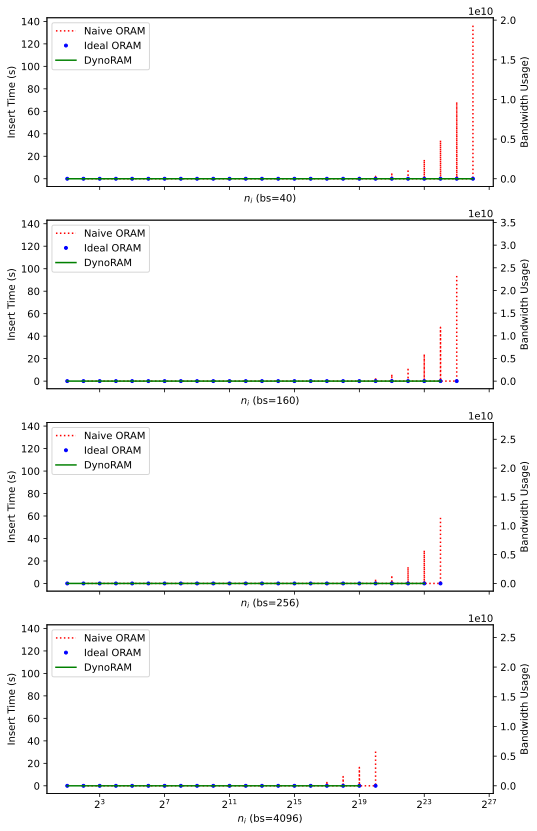

In [58]:
# RAM Insert Time

fig, axs = plt.subplots(len(rbs), sharex=True, sharey=True, figsize=(8, 14))

for idx, bs in enumerate(rbs):
  ax1 = axs[idx]
  ax2 = ax1.twinx()
  ax1.plot(noram[bs]['n'], noram[bs]['insert'],
           label=f'Naive ORAM', linestyle=':', color='red')
  ax2.plot(noram[bs]['n'], noram[bs]['insert_bytes'],
           label=f'Naive ORAM', linestyle='', color='red')
  ax1.plot(soram[bs]['n'], soram[bs]['insert'],
           label=f'Ideal ORAM', linestyle='', color='blue', marker='.')
  ax1.plot(doram[bs]['n'], doram[bs]['insert'],
           label=f'DynoRAM', linestyle='-', color='green')

  ax1.set_xlabel(f'$n_i$ (bs={bss[idx]})')
  ax1.set_ylabel('Insert Time (s)')
  ax2.set_ylabel('Bandwidth Usage)')
  ax1.set_xscale('log', base=2)
#     axs[idx].set_yscale('log')
  axs[idx].legend(loc='upper left')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


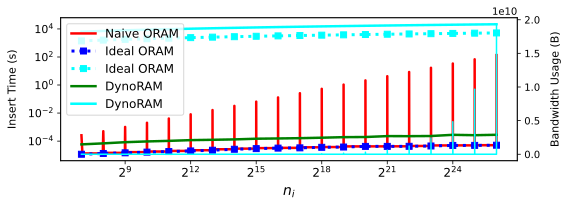

In [59]:
fig, ax1 = plt.subplots(figsize=(8, 3))
ax2 = ax1.twinx()
bs = rbs[0]
ax1.plot(gte_cutoff(noram[bs])['n'], gte_cutoff(noram[bs])[
         'insert'], label=f'Naive ORAM', linestyle='-', color='red', lw=2.5)
ax2.plot(gte_cutoff(noram[bs])['n'], gte_cutoff(noram[bs])[
         'insert_bytes'], label=f'Naive ORAM', linestyle='-', color='cyan')
ax1.plot(gte_cutoff(soram[bs])['n'], gte_cutoff(soram[bs])[
         'insert'], label=f'Ideal ORAM', linestyle=':', color='blue', marker='s', lw=3)
ax1.plot(gte_cutoff(soram[bs])['n'], gte_cutoff(soram[bs])[
         'insert_bytes'], label=f'Ideal ORAM', linestyle=':', color='cyan', marker='s', lw=3)
ax1.plot(gte_cutoff(doram[bs])['n'], gte_cutoff(doram[bs])[
         'insert'], label=f'DynoRAM', linestyle='-', color='green', lw=2.5)
ax1.plot(gte_cutoff(doram[bs])['n'], gte_cutoff(doram[bs])[
         'insert_bytes'], label=f'DynoRAM', linestyle='-', color='cyan', lw=2.5)

ax1.set_xlabel(f'$n_i$', fontsize=14, labelpad=5)
ax1.set_ylabel('Insert Time (s)', fontsize=11, labelpad=10)
ax2.set_ylabel('Bandwidth Usage (B)', fontsize=11, labelpad=10)
ax1.tick_params(axis='x', which='both', labelsize=12)
ax1.tick_params(axis='y', which='both', labelsize=11)
ax2.tick_params(axis='y', which='both', labelsize=10)
ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
ax1.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.savefig('plots_vldb/oram_insert.eps', bbox_inches='tight')
plt.show()

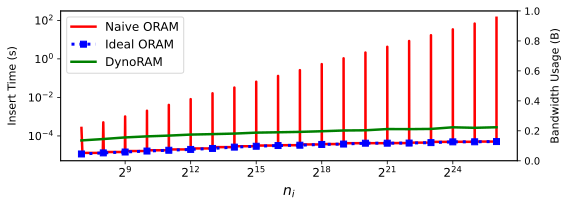

In [60]:
fig, ax1 = plt.subplots(figsize=(8, 3))
ax2 = ax1.twinx()
bs = rbs[0]
ax1.plot(gte_cutoff(noram[bs])['n'], gte_cutoff(noram[bs])[
         'insert'], label=f'Naive ORAM', linestyle='-', color='red', lw=2.5)
# ax2.plot(gte_cutoff(noram[bs])['n'], gte_cutoff(noram[bs])['insert_bytes'], label=f'Naive ORAM', linestyle='-', color='cyan')
ax1.plot(gte_cutoff(soram[bs])['n'], gte_cutoff(soram[bs])[
         'insert'], label=f'Ideal ORAM', linestyle=':', color='blue', marker='s', lw=3)
# ax1.plot(gte_cutoff(soram[bs])['n'], gte_cutoff(soram[bs])['insert_bytes'], label=f'Ideal ORAM', linestyle=':', color='cyan', marker='s', lw=3)
ax1.plot(gte_cutoff(doram[bs])['n'], gte_cutoff(doram[bs])[
         'insert'], label=f'DynoRAM', linestyle='-', color='green', lw=2.5)
# ax1.plot(gte_cutoff(doram[bs])['n'], gte_cutoff(doram[bs])['insert_bytes'], label=f'DynoRAM', linestyle='-', color='cyan', lw=2.5)

ax1.set_xlabel(f'$n_i$', fontsize=14, labelpad=5)
ax1.set_ylabel('Insert Time (s)', fontsize=11, labelpad=10)
ax2.set_ylabel('Bandwidth Usage (B)', fontsize=11, labelpad=10)
ax1.tick_params(axis='x', which='both', labelsize=12)
ax1.tick_params(axis='y', which='both', labelsize=11)
ax2.tick_params(axis='y', which='both', labelsize=10)
ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
ax1.legend(loc='upper left', fontsize=12)
plt.tight_layout()
# plt.savefig('plots/oram_insert.eps', bbox_inches='tight')
plt.show()

In [61]:
print(
    f"Naive ORAM Max BW: {noram[rbs[0]]['insert_bytes'].iloc[-1]} for $n_i$: $2^{{{noram[rbs[0]]['nlg'].iloc[-1]}}}$")
print(
    f"DynoRAM Max BW: {doram[rbs[0]]['insert_bytes'].iloc[-1]} for $n_i$: $2^{{{doram[rbs[0]]['nlg'].iloc[-1]}}}$")

Naive ORAM Max BW: 19327357744.0 for $n_i$: $2^{26}$
DynoRAM Max BW: 21600 for $n_i$: $2^{26}$


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


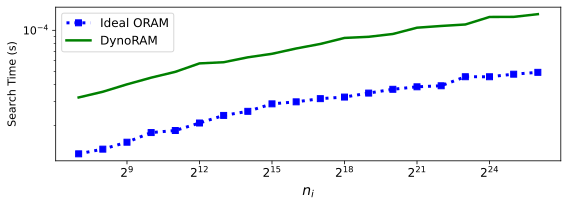

In [62]:
fig, ax1 = plt.subplots(figsize=(8, 3))
# ax2 = ax1.twinx()
bs = rbs[0]
ax1.plot(gte_cutoff(soram[bs])['n'], gte_cutoff(soram[bs])[
         'search'], label=f'Ideal ORAM', linestyle=':', color='blue', marker='s', lw=3)
ax1.plot(gte_cutoff(doram[bs])['n'], gte_cutoff(doram[bs])[
         'search'], label=f'DynoRAM', linestyle='-', color='green', lw=2.5)

ax1.set_xlabel(f'$n_i$', fontsize=14, labelpad=5)
ax1.set_ylabel('Search Time (s)', fontsize=11, labelpad=5)
ax1.tick_params(axis='x', which='both', labelsize=12)
ax1.tick_params(axis='y', which='both', labelsize=11)
ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
ax1.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.savefig('plots/oram_update.eps', bbox_inches='tight')
plt.show()

In [63]:
print(
    f"Naive ORAM search time: {soram[rbs[0]]['search'].iloc[-1]} for $n_i$: $2^{{{soram[rbs[0]]['nlg'].iloc[-1]}}}$")
print(
    f"DynoRAM search time: {doram[rbs[0]]['search'].iloc[-1]} for $n_i$: $2^{{{doram[rbs[0]]['nlg'].iloc[-1]}}}$")
print(doram[rbs[0]]['search'].iloc[-1]/soram[rbs[0]]['search'].iloc[-1])

Naive ORAM search time: 4.92093e-05 for $n_i$: $2^{26}$
DynoRAM search time: 0.000131313 for $n_i$: $2^{26}$
2.6684590107967394


KeyError: 3

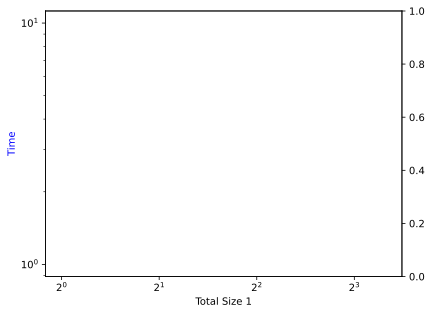

In [64]:
bslgs = bslgs = sorted(list(set(data['bslg'])))
bslg = bslgs[0]

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax1.set_xlabel('Total Size 1')
ax1.set_ylabel('Time', color='b')
ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
ax1.plot(noram[bslg]['total_size'], noram[bslg]['insert'],
         label='Naive ORAM Insert Time', linestyle='-', color='b')

ax2.set_ylabel('bytes', color='r')
ax2.plot(noram[bslg]['total_size'], noram[bslg]['insert_bytes'],
         label='Naive ORAM Insert Bytes', linestyle=':', color='r')

plt.legend(loc='upper left')
plt.show()

In [ ]:
bslgs = bslgs = sorted(list(set(data['bslg'])))
bslg = bslgs[0]

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax1.set_xlabel('Total Size 1')
ax1.set_ylabel('Time', color='b')
ax1.set_xscale('log', base=2)
# ax1.set_yscale('log')
ax1.plot(soram[bslg]['total_size'], soram[bslg]['search'],
         label='Static ORAM Search Time', linestyle='-', color='b')

ax2.set_ylabel('bytes', color='r')
# ax2.set_yscale('log')
ax2.plot(soram[bslg]['total_size'], soram[bslg]['search_bytes'],
         label='Static ORAM Search Bytes', linestyle=':', color='r')

plt.legend(loc='upper left')
plt.show()

In [ ]:
# RAM Insert Bytes

bslgs = sorted(list(set(data['bslg'])))
fig, axs = plt.subplots(len(bslgs), sharex=True, sharey=True, figsize=(8, 14))

for idx, bslg in enumerate(bslgs):
  axs[idx].plot(noram[bslg]['total_size'], noram[bslg]['insert_bytes'],
                label=f'Naive ORAM', linestyle=':', color='red')
  axs[idx].plot(soram[bslg]['total_size'], soram[bslg]['insert_bytes'],
                label=f'Ideal ORAM', linestyle='', color='blue', marker='.')
  axs[idx].plot(doram[bslg]['total_size'], doram[bslg]['insert_bytes'],
                label=f'DynoRAM ORAM', linestyle='-', color='green')

  axs[idx].set_xlabel(f'Total Size (bs=$2^{{{bslg}}}B$, varying $n_i$)')
  axs[idx].set_ylabel('Insert Bandwidth Usage (B)')
  axs[idx].set_xscale('log', base=2)
#     axs[idx].set_yscale('log')
  axs[idx].legend(loc='upper left')
plt.show()

In [ ]:
# RAM Search Time

bslgs = sorted(list(set(data['bslg'])))
fig, axs = plt.subplots(len(bslgs), sharex=True, sharey=True, figsize=(8, 14))

for idx, bslg in enumerate(bslgs):
  axs[idx].plot(soram[bslg]['total_size'], soram[bslg]['search'],
                label=f'Ideal ORAM', linestyle='', color='blue', marker='.')
  axs[idx].plot(doram[bslg]['total_size'], doram[bslg]['search'],
                label=f'DynoRAM', linestyle='-', color='green')

  axs[idx].set_xlabel(f'Total Size (bs=$2^{{{bslg}}}B$, varying $n_i$)')
  axs[idx].set_ylabel('Search Time (s)')
  axs[idx].set_xscale('log', base=2)
  axs[idx].set_yscale('log')
  axs[idx].legend(loc='upper left')
plt.show()

In [ ]:
# RAM Delete Time

bslgs = sorted(list(set(data['bslg'])))
fig, axs = plt.subplots(len(bslgs), sharex=True, sharey=True, figsize=(8, 14))

for idx, bslg in enumerate(bslgs):
  axs[idx].plot(soram[bslg]['total_size'], soram[bslg]['delete'],
                label=f'Ideal ORAM', linestyle='', color='blue', marker='.')
  axs[idx].plot(doram[bslg]['total_size'], doram[bslg]['delete'],
                label=f'DynoRAM', linestyle='-', color='green')

  axs[idx].set_xlabel(f'Total Size (bs=$2^{{{bslg}}}B$, varying $n_i$)')
  axs[idx].set_ylabel('Delete Time (s)')
  axs[idx].set_xscale('log', base=2)
  axs[idx].set_yscale('log')
  axs[idx].legend(loc='upper left')
plt.show()

## Map

In [ ]:
# Map Insert Time

fig, axs = plt.subplots(len(bss), sharex=True, sharey=True, figsize=(8, 24))

for idx, bs in enumerate(mbs):
  axs[idx].plot(nomap_ram[bs]['n'], nomap_ram[bs]['insert'],
                label=f'Naive OMap (Mem)', linestyle=':', color='red')
  axs[idx].plot(nomap_disk[bs]['n'], nomap_disk[bs]['insert'],
                label=f'Naive OMap (Disk)', linestyle='-.', color='cyan')

  axs[idx].plot(somap_ram[bs]['n'], somap_ram[bs]['insert'],
                label=f'Ideal OMap (Mem)', linestyle='', color='blue', marker='.')
  axs[idx].plot(somap_disk[bs]['n'], somap_disk[bs]['insert'],
                label=f'Ideal OMap (Disk)', linestyle='', color='m', marker='+')

  axs[idx].plot(domap_ram[bs]['n'], domap_ram[bs]['insert'],
                label=f'DynoMap (Mem)', linestyle='-', color='green')
  axs[idx].plot(domap_disk[bs]['n'], domap_disk[bs]['insert'],
                label=f'DynoMap (Disk)', linestyle='--', color='k')

  axs[idx].set_xlabel(f'Total Size (bs={bs}, varying $n_i$)')
  axs[idx].set_ylabel('Insert Time (s)')
  axs[idx].set_xscale('log', base=2)
  axs[idx].set_yscale('log')
  axs[idx].legend(loc='upper left')
plt.show()

In [ ]:
mbs

In [ ]:
# Map Insert Time

fig, axs = plt.subplots(len(bslgs), sharex=True, sharey=True, figsize=(8, 12))

for idx, bslg in enumerate(bslgs):
  axs[idx].plot(nomap_ram[bslg]['total_size'], nomap_ram[bslg]['insert'],
                label=f'Naive OMap (Mem)', linestyle=':', color='red')
  axs[idx].plot(nomap_disk[bslg]['total_size'], nomap_disk[bslg]['insert'],
                label=f'Naive OMap (Disk)', linestyle='-.', color='cyan')

  axs[idx].plot(somap_ram[bslg]['total_size'], somap_ram[bslg]['insert'],
                label=f'Ideal OMap (Mem)', linestyle='', color='blue', marker='.')
  axs[idx].plot(somap_disk[bslg]['total_size'], somap_disk[bslg]['insert'],
                label=f'Ideal OMap (Disk)', linestyle='', color='m', marker='+')

  axs[idx].plot(domap_ram[bslg]['total_size'], domap_ram[bslg]['insert'],
                label=f'DynoMap (Mem)', linestyle='-', color='green')
  axs[idx].plot(domap_disk[bslg]['total_size'], domap_disk[bslg]['insert'],
                label=f'DynoMap (Disk)', linestyle='--', color='k')

  axs[idx].set_xlabel(f'Total Size (bs=$2^{{{bslg}}}B$, varying $n_i$)')
  axs[idx].set_ylabel('Insert Time (s)')
  axs[idx].set_xscale('log', base=2)
  axs[idx].set_yscale('log')
  axs[idx].legend(loc='upper left')
plt.show()

In [ ]:
# Map Insert Bytes

bslgs = sorted(list(set(data['bslg'])))
fig, axs = plt.subplots(len(bslgs), sharex=True, sharey=True, figsize=(8, 14))

for idx, bslg in enumerate(bslgs):
  axs[idx].plot(nomap_ram[bslg]['total_size'], nomap_ram[bslg]['insert_bytes'],
                label=f'Naive OMAP', linestyle=':', color='red')

  axs[idx].plot(somap_ram[bslg]['total_size'], somap_ram[bslg]['insert_bytes'],
                label=f'Ideal OMap', linestyle='', color='blue', marker='.')

  axs[idx].plot(domap_ram[bslg]['total_size'], domap_ram[bslg]['insert_bytes'],
                label=f'DynoMap', linestyle='-', color='green')

  axs[idx].set_xlabel(f'Total Size (bs=$2^{{{bslg}}}B$, varying $n_i$)')
  axs[idx].set_ylabel('Insert Bandwidth Usage (B)')
  axs[idx].set_xscale('log', base=2)
  axs[idx].set_yscale('log')
  axs[idx].legend(loc='upper left')
plt.show()

In [ ]:
# Map Search Time

bslgs = sorted(list(set(data['bslg'])))
fig, axs = plt.subplots(len(bslgs), sharex=True, sharey=True, figsize=(8, 14))

for idx, bslg in enumerate(bslgs):
  axs[idx].plot(somap_ram[bslg]['total_size'], somap_ram[bslg]['search'],
                label=f'Ideal OMap (Mem)', linestyle='', color='blue', marker='.')
  axs[idx].plot(somap_disk[bslg]['total_size'], somap_disk[bslg]['search'],
                label=f'Ideal OMap (Disk)', linestyle='', color='m', marker='+')

  axs[idx].plot(domap_ram[bslg]['total_size'], domap_ram[bslg]['search'],
                label=f'DynoMap (Mem)', linestyle='-', color='green')
  axs[idx].plot(domap_disk[bslg]['total_size'], domap_disk[bslg]['search'],
                label=f'DynoMap (Disk)', linestyle='--', color='k')

  axs[idx].set_xlabel(f'Total Size (bs=$2^{{{bslg}}}B$, varying $n_i$)')
  axs[idx].set_ylabel('Search Time (s)')
  axs[idx].set_xscale('log', base=2)
  axs[idx].set_yscale('log')
  axs[idx].legend(loc='upper left')
plt.show()

In [ ]:
# Map Search Time

fig, axs = plt.subplots(len(bss), sharex=False, sharey=True, figsize=(8, 12))
plt.subplots_adjust(hspace=.45)

l = ['A', 'B', 'C', 'D']

for idx, bs in enumerate(mbs):
  #     axs[idx].plot(somap_ram[bs]['n'], somap_ram[bs]['search'],
  #                   label=f'Naive/Ideal OMap', linestyle='', color='blue', marker='.')
  #     axs[idx].plot(domap_ram[bs]['n'], domap_ram[bs]['search'],
  #                   label=f'DynoMap', linestyle='-', color='green')
  axs[idx].plot(gte_cutoff(somap_ram[bs])['n'], gte_cutoff(somap_ram[bs])[
                'search'], label=f'Naive/Ideal OMap', linestyle=':', color='blue', marker='s', lw=3)
  axs[idx].plot(gte_cutoff(domap_ram[bs])['n'], gte_cutoff(domap_ram[bs])[
                'search'], label=f'DynoMap', linestyle='-', color='green', lw=2.5)

  axs[idx].set_title(f'{l[idx]}: BlockSize={bss[idx]}B')
  axs[idx].set_xlabel(f'$n_i$', fontsize=14, labelpad=5)
  axs[idx].set_ylabel('Search Time (s)', fontsize=11, labelpad=10)
  axs[idx].tick_params(axis='x', which='both', labelsize=12)
  axs[idx].tick_params(axis='y', which='both', labelsize=11)
  axs[idx].set_xscale('log', base=2)
  axs[idx].set_yscale('log')
  axs[idx].legend(loc='lower right', fontsize=12)

plt.tight_layout()
plt.savefig('plots/omap-update-var-bs.eps', bbox_inches='tight')
plt.show()

In [ ]:
# Map Search Time

fig, axs = plt.subplots(1, sharex=False, sharey=True, figsize=(8, 3))
# plt.subplots_adjust(hspace=.45)

# l = ['A', 'B', 'C', 'D']

for idx, bs in enumerate(mbs):
  ax = axs
#     axs[idx].plot(somap_ram[bs]['n'], somap_ram[bs]['search'],
#                   label=f'Naive/Ideal OMap', linestyle='', color='blue', marker='.')
#     axs[idx].plot(domap_ram[bs]['n'], domap_ram[bs]['search'],
#                   label=f'DynoMap', linestyle='-', color='green')
  ax.plot(gte_cutoff(somap_ram[bs])['n'], gte_cutoff(somap_ram[bs])[
          'search'], label=f'Naive/Ideal OMap', linestyle=':', color='blue', marker='s', lw=3)
  ax.plot(gte_cutoff(domap_ram[bs])['n'], gte_cutoff(domap_ram[bs])[
          'search'], label=f'DynoMap', linestyle='-', color='green', lw=2.5)

  ax.set_title(f'BlockSize={bss[idx]}B')
  ax.set_xlabel(f'$n_i$', fontsize=14, labelpad=5)
  ax.set_ylabel('Search Time (s)', fontsize=11, labelpad=10)
  ax.tick_params(axis='x', which='both', labelsize=12)
  ax.tick_params(axis='y', which='both', labelsize=11)
  ax.set_xscale('log', base=2)
  ax.set_yscale('log')
  ax.legend(loc='lower right', fontsize=12)
  break

plt.tight_layout()
plt.savefig('plots/omap-update-var-bs-1.eps', bbox_inches='tight')
plt.show()

In [ ]:
# Map Search Time

fig, axs = plt.subplots(len(bss)-1, sharex=False, sharey=True, figsize=(8, 9))
plt.subplots_adjust(hspace=.45)

l = ['A', 'B', 'C', 'D']

for idx, bs in enumerate(mbs):
  bs = mbs[idx+1]
#     axs[idx].plot(somap_ram[bs]['n'], somap_ram[bs]['search'],
#                   label=f'Naive/Ideal OMap', linestyle='', color='blue', marker='.')
#     axs[idx].plot(domap_ram[bs]['n'], domap_ram[bs]['search'],
#                   label=f'DynoMap', linestyle='-', color='green')
  axs[idx].plot(gte_cutoff(somap_ram[bs])['n'], gte_cutoff(somap_ram[bs])[
                'search'], label=f'Naive/Ideal OMap', linestyle=':', color='blue', marker='s', lw=3)
  axs[idx].plot(gte_cutoff(domap_ram[bs])['n'], gte_cutoff(domap_ram[bs])[
                'search'], label=f'DynoMap', linestyle='-', color='green', lw=2.5)

  axs[idx].set_title(f'{l[idx]}: BlockSize={bss[idx+1]}B')
  axs[idx].set_xlabel(f'$n_i$', fontsize=14, labelpad=5)
  axs[idx].set_ylabel('Search Time (s)', fontsize=11, labelpad=10)
  axs[idx].tick_params(axis='x', which='both', labelsize=12)
  axs[idx].tick_params(axis='y', which='both', labelsize=11)
  axs[idx].set_xscale('log', base=2)
  axs[idx].set_yscale('log')
  axs[idx].legend(loc='lower right', fontsize=12)
  if idx == 2:
    break

plt.tight_layout()
plt.savefig('plots/omap-update-var-bs-2.eps', bbox_inches='tight')
plt.show()

In [ ]:
# Map Delete Time

bslgs = sorted(list(set(data['bslg'])))
fig, axs = plt.subplots(len(bslgs), sharex=True, sharey=True, figsize=(8, 14))

for idx, bslg in enumerate(bslgs):
  axs[idx].plot(somap_ram[bslg]['total_size'], somap_ram[bslg]['delete'],
                label=f'Ideal OMap (Mem)', linestyle='', color='blue', marker='.')
  axs[idx].plot(somap_disk[bslg]['total_size'], somap_disk[bslg]['delete'],
                label=f'Ideal OMap (Disk)', linestyle='', color='m', marker='+')

  axs[idx].plot(domap_ram[bslg]['total_size'], domap_ram[bslg]['delete'],
                label=f'DynoMap (Mem)', linestyle='-', color='green')
  axs[idx].plot(domap_disk[bslg]['total_size'], domap_disk[bslg]['delete'],
                label=f'DynoMap (Disk)', linestyle='--', color='k')

  axs[idx].set_xlabel(f'Total Size (bs=$2^{{{bslg}}}B$, varying $n_i$)')
  axs[idx].set_ylabel('Delete Time (s)')
  axs[idx].set_xscale('log', base=2)
  axs[idx].set_yscale('log')
  axs[idx].legend(loc='upper left')
plt.show()

## Heap

In [ ]:
# Heap Insert Time

fig, axs = plt.subplots(len(bss), sharex=True, sharey=True, figsize=(8, 14))

for idx, bslg in enumerate(bslgs):
  axs[idx].plot(noheap[bslg]['total_size'], noheap[bslg]['insert'],
                label=f'Naive OHeap', linestyle=':', color='red')
  axs[idx].plot(soheap[bslg]['total_size'], soheap[bslg]['insert'],
                label=f'Ideal OHeap', linestyle='', color='blue', marker='.')
  axs[idx].plot(doheap[bslg]['total_size'], doheap[bslg]['insert'],
                label=f'DynoHeap', linestyle='-', color='green')

  axs[idx].set_xlabel(f'Total Size (bs=$2^{{{bslg}}}B$, varying $n_i$)')
  axs[idx].set_ylabel('Insert Time (s)')
  axs[idx].set_xscale('log', base=2)
#     axs[idx].set_yscale('log')
  axs[idx].legend(loc='upper left')
plt.show()

In [ ]:
# Heap Insert Bytes

bslgs = sorted(list(set(data['bslg'])))
fig, axs = plt.subplots(len(bslgs), sharex=True, sharey=True, figsize=(8, 14))

for idx, bslg in enumerate(bslgs):
  axs[idx].plot(noheap[bslg]['total_size'], noheap[bslg]['insert_bytes'],
                label=f'Naive OHeap', linestyle=':', color='red')
  axs[idx].plot(soheap[bslg]['total_size'], soheap[bslg]['insert_bytes'],
                label=f'Ideal OHeap', linestyle='', color='blue', marker='.')
  axs[idx].plot(doheap[bslg]['total_size'], doheap[bslg]['insert_bytes'],
                label=f'DynoHeap OHeap', linestyle='-', color='green')

  axs[idx].set_xlabel(f'Total Size (bs=$2^{{{bslg}}}B$, varying $n_i$)')
  axs[idx].set_ylabel('Insert Bandwidth Usage (B)')
  axs[idx].set_xscale('log', base=2)
#     axs[idx].set_yscale('log')
  axs[idx].legend(loc='upper left')
plt.show()

In [ ]:
# Heap Search Time

bslgs = sorted(list(set(data['bslg'])))
fig, axs = plt.subplots(len(bslgs), sharex=True, sharey=True, figsize=(8, 14))

for idx, bslg in enumerate(bslgs):
  axs[idx].plot(soheap[bslg]['total_size'], soheap[bslg]['search'],
                label=f'Ideal OHeap', linestyle='', color='blue', marker='.')
  axs[idx].plot(doheap[bslg]['total_size'], doheap[bslg]['search'],
                label=f'DynoHeap', linestyle='-', color='green')

  axs[idx].set_xlabel(f'Total Size (bs=$2^{{{bslg}}}B$, varying $n_i$)')
  axs[idx].set_ylabel('Search Time (s)')
  axs[idx].set_xscale('log', base=2)
  axs[idx].set_yscale('log')
  axs[idx].legend(loc='upper left')
plt.show()

In [ ]:
# Heap Delete Time

bslgs = sorted(list(set(data['bslg'])))
fig, axs = plt.subplots(len(bslgs), sharex=True, sharey=True, figsize=(8, 14))

for idx, bslg in enumerate(bslgs):
  axs[idx].plot(soheap[bslg]['total_size'], soheap[bslg]['delete'],
                label=f'Ideal OHeap', linestyle='', color='blue', marker='.')
  axs[idx].plot(doheap[bslg]['total_size'], doheap[bslg]['delete'],
                label=f'DynoHeap', linestyle='-', color='green')

  axs[idx].set_xlabel(f'Total Size (bs=$2^{{{bslg}}}B$, varying $n_i$)')
  axs[idx].set_ylabel('Delete Time (s)')
  axs[idx].set_xscale('log', base=2)
  axs[idx].set_yscale('log')
  axs[idx].legend(loc='upper left')
plt.show()

## Stack

In [ ]:
# Sanity Check

plt.xscale('log', base=2)
plt.yscale('log')
x = dfselect(data, 'test', 'pstack').copy(deep=True)
x.set_index('total_size', inplace=True)
x.groupby('bslg')['insert'].plot(legend=True)
plt.show()

In [ ]:
# Stack Insert Time

fig, axs = plt.subplots(len(sbs), sharex=True, sharey=True, figsize=(8, 14))

for idx, bs in enumerate(sbs):
  axs[idx].plot(nostack[bs]['n'], nostack[bs]['insert'],
                label=f'Naive OStack', linestyle=':', color='red')
  axs[idx].plot(pstack[bs]['n'], pstack[bs]['insert'],
                label=f'Simple Stack + Encryption', linestyle='', color='blue', marker='.')
  axs[idx].plot(doheap[bs]['n'], doheap[bs]['insert'],
                label=f'DynoStack', linestyle='-', color='green')

  axs[idx].set_xlabel(f'Total Size (bs={bs}B$, varying $n_i$)')
  axs[idx].set_ylabel('Insert Time (s)')
  axs[idx].set_xscale('log', base=2)
  axs[idx].set_yscale('log')
  axs[idx].legend(loc='upper left')
plt.show()

In [ ]:
# Stack Insert Bytes

bslgs = sorted(list(set(data['bslg'])))
fig, axs = plt.subplots(len(bslgs), sharex=True, sharey=True, figsize=(8, 14))

for idx, bslg in enumerate(bslgs):
  axs[idx].plot(nostack[bslg]['total_size'], nostack[bslg]['insert_bytes'],
                label=f'Naive OStack', linestyle=':', color='red')
  axs[idx].plot(pstack[bslg]['total_size'], pstack[bslg]['insert_bytes'],
                label=f'Simple Stack + Encryption', linestyle='', color='blue', marker='.')
  axs[idx].plot(doheap[bslg]['total_size'], doheap[bslg]['insert_bytes'],
                label=f'DynoStack', linestyle='-', color='green')

  axs[idx].set_xlabel(f'Total Size (bs=$2^{{{bslg}}}B$, varying $n_i$)')
  axs[idx].set_ylabel('Insert Bandwidth Usage (B)')
  axs[idx].set_xscale('log', base=2)
  axs[idx].set_yscale('log')
  axs[idx].legend(loc='upper left')
plt.show()

In [ ]:
# Stack Search Time

bslgs = sorted(list(set(data['bslg'])))
fig, axs = plt.subplots(len(bslgs), sharex=True, sharey=True, figsize=(8, 14))

for idx, bslg in enumerate(bslgs):
  axs[idx].plot(sostack[bslg]['total_size'], sostack[bslg]['search'],
                label=f'Ideal OStack', linestyle='', color='blue', marker='.')
  axs[idx].plot(pstack[bslg]['total_size'], pstack[bslg]['search'],
                label=f'Simple Stack + Encryption', linestyle='-', color='green')

  axs[idx].set_xlabel(f'Total Size (bs=$2^{{{bslg}}}B$, varying $n_i$)')
  axs[idx].set_ylabel('Search Time (s)')
  axs[idx].set_xscale('log', base=2)
  axs[idx].set_yscale('log')
  axs[idx].legend(loc='upper left')
plt.show()

In [ ]:
# Stack Delete Time

bslgs = sorted(list(set(data['bslg'])))
fig, axs = plt.subplots(len(bslgs), sharex=True, sharey=True, figsize=(8, 14))

for idx, bslg in enumerate(bslgs):
  axs[idx].plot(sostack[bslg]['total_size'], sostack[bslg]['delete'],
                label=f'Ideal OStack', linestyle='', color='blue', marker='.')
  axs[idx].plot(pstack[bslg]['total_size'], pstack[bslg]['delete'],
                label=f'Simple Stack + Encryption', linestyle='-', color='green')

  axs[idx].set_xlabel(f'Total Size (bs=$2^{{{bslg}}}B$, varying $n_i$)')
  axs[idx].set_ylabel('Delete Time (s)')
  axs[idx].set_xscale('log', base=2)
  axs[idx].set_yscale('log')
  axs[idx].legend(loc='upper left')
plt.show()

## Heaps, Stacks, Queues

In [ ]:
# Map Search Time

fig, axs = plt.subplots(len(bss), sharex=False, sharey=True, figsize=(8, 14))
plt.subplots_adjust(hspace=.45)

l = ['A', 'B', 'C', 'D']

for idx, bs in enumerate(mbs):
  #     axs[idx].plot(somap_ram[bs]['n'], somap_ram[bs]['search'],
  #                   label=f'Naive/Ideal OMap', linestyle='', color='blue', marker='.')
  #     axs[idx].plot(domap_ram[bs]['n'], domap_ram[bs]['search'],
  #                   label=f'DynoMap', linestyle='-', color='green')
  axs[idx].plot(gte_cutoff(somap_ram[bs])['n'], gte_cutoff(somap_ram[bs])[
                'search'], label=f'Naive/Ideal OMap', linestyle=':', color='blue', marker='s', lw=3.5)
  axs[idx].plot(gte_cutoff(domap_ram[bs])['n'], gte_cutoff(domap_ram[bs])[
                'search'], label=f'DynoMap', linestyle='-', color='green', lw=2.5)

  axs[idx].set_title(f'{l[idx]}: BlockSize={bss[idx]}B')
  axs[idx].set_xlabel(f'$n_i$', fontsize=14, labelpad=5)
  axs[idx].set_ylabel('Search Time (s)', fontsize=11, labelpad=10)
  axs[idx].tick_params(axis='x', which='both', labelsize=12)
  axs[idx].tick_params(axis='y', which='both', labelsize=11)
  axs[idx].set_xscale('log', base=2)
  axs[idx].set_yscale('log')
  axs[idx].legend(loc='lower right', fontsize=12)

plt.tight_layout()
plt.savefig('plots/omap-update-var-bs.eps', bbox_inches='tight')
plt.show()

In [ ]:
fig, axs = plt.subplots(2, sharex=True, sharey=True, figsize=(8, 6))
plt.subplots_adjust(hspace=.3)

ax = axs[0]
ax.plot(gte_cutoff(soheap[hbs[0]])['n'], gte_cutoff(soheap[hbs[0]])['insert'],
        label=f'Naive/Ideal OHeap', linestyle=':', color='blue', marker='s', lw=3)
ax.plot(gte_cutoff(sostack[sbs[0]])['n'], gte_cutoff(sostack[sbs[0]])['insert'],
        label='Naive/Ideal OStack/OQueue', linestyle=':', color='m', marker='D', lw=2.5)
ax.plot(gte_cutoff(doheap[hbs[0]])['n'], gte_cutoff(doheap[hbs[0]])['insert'],
        label='DynoHeap', linestyle='-', color='g', lw=2.5)
# ax.plot(soheap[hbs[0]]['n'], soheap[hbs[0]]['insert'],
#         label=f'Naive/Ideal OHeap', linestyle='', color='blue', marker='.')
# ax.plot(sostack[sbs[0]]['n'], sostack[sbs[0]]['insert'],
#         label='Naive/Ideal OStack/OQueue', linestyle='', color='b', marker='+')
# ax.plot(doheap[hbs[0]]['n'], doheap[hbs[0]]['insert'],
#         label='DynoHeap', linestyle='-', color='g')
# ax.plot(pstack[sbs[1]]['n'], pstack[sbs[1]]['insert'],
#         label='Simple Stack/Queue', linestyle='', color='c', marker='*')
ax.set_title('A')
ax.set_xlabel('$n_i$')
ax.set_ylabel('Insert Time (s)')
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.legend(loc='lower right')

ax = axs[1]
ax.plot(gte_cutoff(soheap[hbs[0]])['n'], gte_cutoff(soheap[hbs[0]])['search'],
        label=f'Naive/Ideal OHeap', linestyle=':', color='blue', marker='s', lw=3)
ax.plot(gte_cutoff(sostack[sbs[0]])['n'], gte_cutoff(sostack[sbs[0]])['search'],
        label='Naive/Ideal OStack/OQueue', linestyle=':', color='m', marker='D', lw=2.5)
ax.plot(gte_cutoff(doheap[hbs[0]])['n'], gte_cutoff(doheap[hbs[0]])['search'],
        label='DynoHeap', linestyle='-', color='g', lw=2.5)
ax.set_title('B')
ax.set_xlabel('$n_i$')
ax.set_ylabel('Search/Update Time (s)')
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('plots/heaps-insert-update.eps', bbox_inches='tight')
plt.show()

## Hiding ODS Type

In [27]:
hb = hbs[0]
mb = mbs[0]
n = 2 ** 25


def hdget(op):
  return doheap[hb][doheap[hb]['n'] == n][op].iloc[0]


def hsget(op):
  return soheap[hb][soheap[hb]['n'] == n][op].iloc[0]


def mdget(op):
  return domap_ram[mb][domap_ram[mb]['n'] == n][op].iloc[0]


def msget(op):
  return somap_ram[mb][somap_ram[mb]['n'] == n][op].iloc[0]


groups = ['OHeap', 'OMap']

l = [
    'III: Insert',
    'III: Delete',
    'III: Search+',
    'III*: Insert',
    'III*: Delete',
    'III*: Search+',
    'II-INS: Insert',
    'II-INS: Search+',
    'I: All',
]

h = [
    3 * hsget('insert'),
    (2 * hsget('search')) + (4 * hdget('insert')),
    2 * hsget('search'),
    3 * msget('insert'),
    (2 * msget('search')) + (4 * msget('insert')),
    2 * msget('search'),
    3 * hsget('insert'),
    (2 * hsget('search')) + (4 * hdget('insert')),
    (2 * hsget('search')) + (4 * hdget('insert')),
]

m = [
    4 * msget('insert'),
    (2 * msget('search')) + (4 * msget('insert')),
    2 * msget('search'),
    4 * msget('insert'),
    (2 * msget('search')) + (4 * msget('insert')),
    2 * msget('search'),
    4 * msget('insert'),
    (2 * msget('search')) + (4 * msget('insert')),
    (2 * msget('search')) + (4 * msget('insert')),
]


def shuff(x):
  return x[0:1] + x[2:3] + x[1:2] + x[6:9] + x[3:4] + x[5:6] + x[4:5]


h, m, l = shuff(h), shuff(m), shuff(l)

df = pd.DataFrame([h, m], columns=l)

In [32]:
[hdget(op) for op in ['insert', 'delete', 'search']]

[0.000661876, 0.001062612, 1.275e-06]

In [35]:
[hsget(op) for op in ['insert', 'delete', 'search']]

[0.000125592, 0.000126084, 0.00012494]

In [33]:
[mdget(op) for op in ['insert', 'delete', 'search']]

[0.0617098, 0.0888594, 0.0299801]

In [36]:
[msget(op) for op in ['insert', 'delete', 'search']]

[0.0137969, 0.0134008, 0.0135359]

In [29]:
op = 'insert'
print(
    hsget(op)*4,
    hdget(op)
)

0.000502368 0.000661876


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


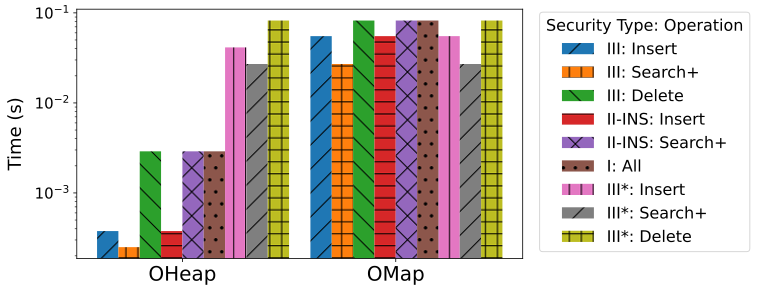

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))

patterns = ["/", "+", "\\", "-", "x", ".", "|", "/", "+", "\\"]

# /   - diagonal hatching
# \   - back diagonal
# |   - vertical
# -   - horizontal
# +   - crossed
# x   - crossed diagonal
# o   - small circle
# O   - large circle
# .   - dots
# *   - stars

x = np.arange(len(groups))
width = 0.1

dist = -3.5 * width
for i in range(len(l)):
  ax.bar(x+dist, df[l[i]], width=width, label=l[i], hatch=patterns[i])
  dist += width
ax.set_ylabel("Time (s)",
              fontsize=18,
              labelpad=10)
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_yscale('log')
lgd = ax.legend(title="Security Type: Operation",
                fontsize=16,
                title_fontsize=16,
                bbox_to_anchor=(1.02, 1.02))
ax.tick_params(axis="x",
               which="both",
               labelsize=20)
ax.tick_params(axis="y",
               which="both",
               labelsize=15)

plt.savefig('plots/sec-levels.eps',
            bbox_extra_artists=(lgd,), bbox_inches='tight')
plt.show()

In [ ]:
df

,III: Insert,III: Search+,III: Delete,II-INS: Insert,II-INS: Search+,I: All,III*: Insert,III*: Search+,III*: Delete
0,0.000377,0.000250,0.002897,0.000377,0.002897,0.002897,0.041391,0.027072,0.082259
1,0.055188,0.027072,0.082259,0.055188,0.082259,0.082259,0.055188,0.027072,0.082259


## Disk

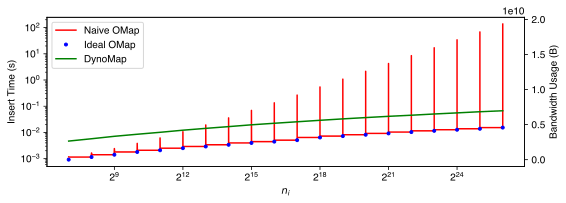

In [198]:
fig, ax1 = plt.subplots(figsize=(8, 3))
ax2 = ax1.twinx()
bs = mbs[0]
ax1.plot(gte_cutoff(nomap_ram[bs])['n'], gte_cutoff(nomap_ram[bs])['insert'],
         label=f'Naive OMap', linestyle='-', color='red')
ax2.plot(gte_cutoff(nomap_ram[bs])['n'], gte_cutoff(nomap_ram[bs])['insert_bytes'],
         label=f'Naive OMap', linestyle='', color='red')
ax1.plot(gte_cutoff(somap_ram[bs])['n'], gte_cutoff(somap_ram[bs])['insert'],
         label=f'Ideal OMap', linestyle='', color='blue', marker='.')
ax1.plot(gte_cutoff(domap_ram[bs])['n'], gte_cutoff(domap_ram[bs])['insert'],
         label=f'DynoMap', linestyle='-', color='green')

ax1.set_xlabel(f'$n_i$')
ax1.set_ylabel('Insert Time (s)')
ax2.set_ylabel('Bandwidth Usage (B)')
ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
ax1.legend(loc='upper left')
plt.tight_layout()
plt.show()

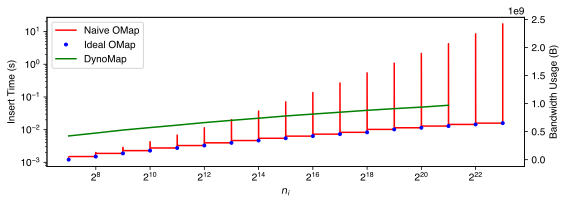

In [199]:
fig, ax1 = plt.subplots(figsize=(8, 3))
ax2 = ax1.twinx()
bs = mbs[0]
ax1.plot(gte_cutoff(nomap_disk[bs])['n'], gte_cutoff(nomap_disk[bs])['insert'],
         label=f'Naive OMap', linestyle='-', color='red')
ax2.plot(gte_cutoff(nomap_disk[bs])['n'], gte_cutoff(nomap_disk[bs])['insert_bytes'],
         label=f'Naive OMap', linestyle='', color='red')
ax1.plot(gte_cutoff(somap_disk[bs])['n'], gte_cutoff(somap_disk[bs])['insert'],
         label=f'Ideal OMap', linestyle='', color='blue', marker='.')
ax1.plot(gte_cutoff(domap_disk[bs])['n'], gte_cutoff(domap_disk[bs])['insert'],
         label=f'DynoMap', linestyle='-', color='green')

ax1.set_xlabel(f'$n_i$')
ax1.set_ylabel('Insert Time (s)')
ax2.set_ylabel('Bandwidth Usage (B)')
ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
ax1.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Hybrid Store

In [266]:
disker = pd.read_csv('data/disker.csv')
disker['nlg'] = disker['n']
disker['n'] = 2 ** disker['n']
dis = dfselect(disker, 'test', 'domap')
# dis

In [267]:
hy = pd.read_csv('data/hybrid.csv')
hy['nlg'] = hy['n']
hy['n'] = 2 ** hy['n']

shy = dfselect(hy, 'test', 'somap')
dhy = dfselect(hy, 'test', 'domap')

shy100 = dfselect(shy, 'disk', 0)
dhy100 = dfselect(dhy, 'disk', 0)
shy50 = dfselect(shy, 'max_mem_level', 22)
dhy50 = dfselect(dhy, 'max_mem_level', 21)
shy25 = dfselect(shy, 'max_mem_level', 21)
dhy25 = dfselect(dhy, 'max_mem_level', 20)
shy12 = dfselect(shy, 'max_mem_level', 20)
dhy12 = dfselect(dhy, 'max_mem_level', 19)

In [268]:
cutoff = 255


def lt_cutoff(df, v=cutoff):
  return df[df['nlg'] < v]


def concat(dd, d, k):
  return pd.concat([dd[k], d[k]], axis=0, ignore_index=True)

In [269]:
h50 = shy50['search'].iloc[-1]
h25 = shy25['search'].iloc[-1]
h12 = shy12['search'].iloc[-1]

In [270]:
import matplotlib.ticker as mtick

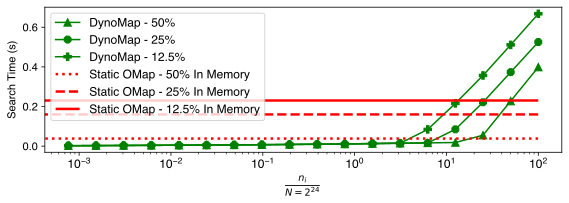

In [271]:
fig, ax = plt.subplots(figsize=(8, 3))

xmax = (2**24)

d = dhy50
dd = lt_cutoff(gte_cutoff(dhy100), d['nlg'].min())
ax.plot(concat(dd, d, 'n')/xmax*100, concat(dd, d, 'search'), linestyle='-',
        color='g', marker='^', label='DynoMap - 50%', lw=lw, ms=ms)

d = dhy25
dd = lt_cutoff(gte_cutoff(dhy100), d['nlg'].min())
ax.plot(concat(dd, d, 'n')/xmax*100, concat(dd, d, 'search'), linestyle='-',
        color='g', marker='8', label='DynoMap - 25%', lw=lw, ms=ms)

d = dhy12
dd = lt_cutoff(gte_cutoff(dhy100), d['nlg'].min())
ax.plot(concat(dd, d, 'n')/xmax*100, concat(dd, d, 'search'), linestyle='-',
        color='g', marker='P', label='DynoMap - 12.5%', lw=lw, ms=ms)


ax.hlines(y=h50, xmin=0, xmax=100, colors='r', linestyles=':',
          label='Static OMap - 50% In Memory', lw=2.5)
ax.hlines(y=h25, xmin=0, xmax=100, colors='r', linestyles='--',
          label='Static OMap - 25% In Memory', lw=2.5)
ax.hlines(y=h12, xmin=0, xmax=100, colors='r', linestyles='-',
          label='Static OMap - 12.5% In Memory', lw=2.5)


ax.set_xlabel('$\\frac{n_i}{N=2^{24}}$', fontsize=14, labelpad=5)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('Search Time (s)', fontsize=11, labelpad=5)
ax.tick_params(axis='x', which='both', labelsize=12)
ax.tick_params(axis='y', which='both', labelsize=11)
ax.set_xscale('log')
# ax.set_yscale('log')
ax.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


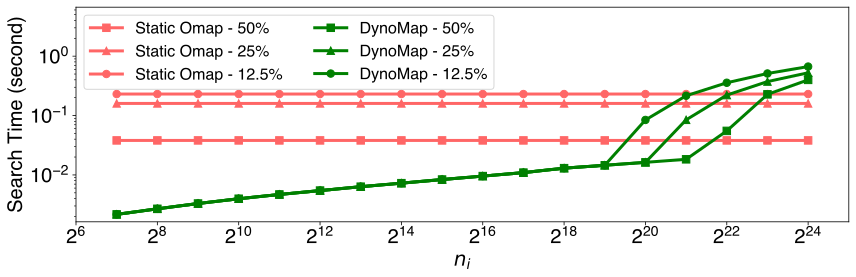

In [276]:
fig, ax = plt.subplots(figsize=(12, 4))
lw = 3.0
fontsize = 16
largefont = 20
ms = 7.5

maxy = 0
miny = 1

xmin = 7
xmax = 24
xlist = [2**x for x in range(xmin, xmax+1)]
r = '#FF6666'

ax.plot(xlist, [h50]*len(xlist), linestyle='-', marker='s',
        label='Static Omap - 50%', lw=lw, color=r, ms=ms)
ax.plot(xlist, [h25]*len(xlist), linestyle='-', marker='^',
        label='Static Omap - 25%', lw=lw, color=r, ms=ms)
ax.plot(xlist, [h12]*len(xlist), linestyle='-', marker='o',
        label='Static Omap - 12.5%', lw=lw, color=r, ms=ms)

d = dhy50
dd = lt_cutoff(gte_cutoff(dhy100), d['nlg'].min())
maxy = max(maxy, concat(dd, d, 'search').max())
miny = min(miny, concat(dd, d, 'search').min())
ax.plot(concat(dd, d, 'n'), concat(dd, d, 'search'), linestyle='-',
        color='g', marker='s', label='DynoMap - 50%', lw=lw, ms=ms)

d = dhy25
dd = lt_cutoff(gte_cutoff(dhy100), d['nlg'].min())
maxy = max(maxy, concat(dd, d, 'search').max())
miny = min(miny, concat(dd, d, 'search').min())
ax.plot(concat(dd, d, 'n'), concat(dd, d, 'search'), linestyle='-',
        color='g', marker='^', label='DynoMap - 25%', lw=lw, ms=ms)

d = dhy12
dd = lt_cutoff(gte_cutoff(dhy100), d['nlg'].min())
maxy = max(maxy, concat(dd, d, 'search').max())
miny = min(miny, concat(dd, d, 'search').min())
ax.plot(concat(dd, d, 'n'), concat(dd, d, 'search'), linestyle='-',
        color='g', marker='o', label='DynoMap - 12.5%', lw=lw, ms=ms)

# di = lt_cutoff(gte_cutoff(dis))
# ax.plot(di['n'], di['search'])


ax.set_xscale('log', base=2)
ax.set_yscale('log')
xticks = [2**x for x in range(6, 25, 2)]
ax.set_xticks(xticks)
ax.set_xlim((2**6, 2**25))
ax.set_ylim((miny*.75, 10*maxy))
ax.set_xlabel('$n_i$',                  fontsize=largefont)
ax.set_ylabel('Search Time (second)',   fontsize=largefont)
ax.tick_params(axis='x', which='both', labelsize=largefont)
ax.tick_params(axis='y', which='both', labelsize=largefont)
ax.legend(loc='upper left', fontsize=fontsize, ncols=2)
plt.tight_layout()
plt.savefig('plots_usenix/hybrid-disk.eps')
plt.show()

In [131]:
d = dhy50
dd = lt_cutoff(gte_cutoff(dhy100), d['nlg'].min())
xtmp = concat(dd, d, 'search')

In [132]:
h50

0.0381362

In [133]:
xtmp / h50

0      0.056807
1      0.070507
2      0.086542
3      0.104198
4      0.122949
5      0.142926
6      0.166183
7      0.190540
8      0.219352
9      0.250733
10     0.286940
11     0.340994
12     0.381278
13     0.427402
14     0.480591
15     1.446526
16     5.965146
17    10.460429
Name: search, dtype: float64

In [134]:
h50 / xtmp

0     17.603490
1     14.183089
2     11.555059
3      9.597127
4      8.133432
5      6.996621
6      6.017461
7      5.248243
8      4.558878
9      3.988308
10     3.485050
11     2.932606
12     2.622757
13     2.339716
14     2.080773
15     0.691312
16     0.167640
17     0.095598
Name: search, dtype: float64

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


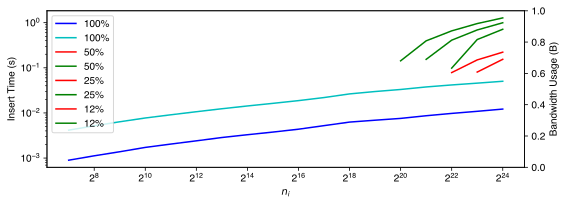

In [210]:
fig, ax1 = plt.subplots(figsize=(8, 3))
ax2 = ax1.twinx()
bs = rbs[0]

ax1.plot(gte_cutoff(shy100)['n'], gte_cutoff(shy100)['insert'],
         label=f'100%', linestyle='-', color='b')
ax1.plot(gte_cutoff(dhy100)['n'], gte_cutoff(dhy100)['insert'],
         label=f'100%', linestyle='-', color='c')

ax1.plot(gte_cutoff(shy50)['n'], gte_cutoff(shy50)['insert'],
         label=f'50%', linestyle='-', color='red')
ax1.plot(gte_cutoff(dhy50)['n'], gte_cutoff(dhy50)['insert'],
         label=f'50%', linestyle='-', color='green')

ax1.plot(gte_cutoff(shy25)['n'], gte_cutoff(shy25)['insert'],
         label=f'25%', linestyle='-', color='red')
ax1.plot(gte_cutoff(dhy25)['n'], gte_cutoff(dhy25)['insert'],
         label=f'25%', linestyle='-', color='green')

ax1.plot(gte_cutoff(shy12)['n'], gte_cutoff(shy12)['insert'],
         label=f'12%', linestyle='-', color='red')
ax1.plot(gte_cutoff(dhy12)['n'], gte_cutoff(dhy12)['insert'],
         label=f'12%', linestyle='-', color='green')

# ax2.plot(gte_cutoff(noram[bs])['n'], gte_cutoff(noram[bs])['insert_bytes'],
#               label=f'Naive ORAM', linestyle='', color='red')
# ax1.plot(gte_cutoff(soram[bs])['n'], gte_cutoff(soram[bs])['insert'],
#               label=f'Ideal ORAM', linestyle='', color='blue', marker='.')

ax1.set_xlabel(f'$n_i$')
ax1.set_ylabel('Insert Time (s)')
ax2.set_ylabel('Bandwidth Usage (B)')
ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
ax1.legend(loc='upper left')
plt.tight_layout()
plt.savefig('plots/oram_insert.eps', bbox_inches='tight')
plt.show()

In [56]:
import subprocess


def makesubfig(op='insert', sgx=False, latency=0.) -> str:
  latint = int(latency*1000)
  return '''\\begin{{subfigure}}{{0.24\\textwidth}}
    \\centering
    \\includegraphics[width=\\textwidth]{{plots/icde-24/{op}_tput{issgx}{latency}}}
    \\caption{{\\revised{{{opcap} Throughput.}}}}\\label{{subfig:tput{issgxd}{latencyd}:{op}}}
  \\end{{subfigure}}'''.format(
      issgx='_omix_sgx'if sgx else '',
      latency=f'_{latint}ms',
      issgxd='-sgx'if sgx else '',
      latencyd=f'-{latint}ms',
      op=op,
      opcap=op.capitalize(),
  )


def makefig(sgx=False, latency=0.) -> str:
  latint = int(latency*1000)
  return '''\\begin{{figure}}[t!]
  \\centering
  {insert_subfig}
  {search_subfig}
  \\caption{{\\revised{{Throughput{issgxs}{latencys}.}}}}\\label{{fig:tput{issgxd}{latencyd}}}
\\end{{figure}}'''.format(
      issgxs=f' with{"out" if not sgx else ""} SGX',
      latencys=f' and {latint}ms latency',
      issgxd='-sgx'if sgx else '',
      latencyd=f'-{latint}ms',
      insert_subfig=makesubfig('insert', sgx, latency),
      search_subfig=makesubfig('search', sgx, latency),
  ) + "\n"*2


res = ''
for latency in (0.02, 0):
  for issgx in (True, False):
    res += makefig(issgx, latency)
print(res)
subprocess.run("pbcopy", text=True, input=res)

\begin{figure}[t!]
  \centering
  \begin{subfigure}{0.24\textwidth}
    \centering
    \includegraphics[width=\textwidth]{plots/icde-24/insert_tput_omix_sgx_20ms}
    \caption{\revised{Insert Throughput.}}\label{subfig:tput-sgx-20ms:insert}
  \end{subfigure}
  \begin{subfigure}{0.24\textwidth}
    \centering
    \includegraphics[width=\textwidth]{plots/icde-24/search_tput_omix_sgx_20ms}
    \caption{\revised{Search Throughput.}}\label{subfig:tput-sgx-20ms:search}
  \end{subfigure}
  \caption{\revised{Throughput with SGX and 20ms latency.}}\label{fig:tput-sgx-20ms}
\end{figure}

\begin{figure}[t!]
  \centering
  \begin{subfigure}{0.24\textwidth}
    \centering
    \includegraphics[width=\textwidth]{plots/icde-24/insert_tput_20ms}
    \caption{\revised{Insert Throughput.}}\label{subfig:tput-20ms:insert}
  \end{subfigure}
  \begin{subfigure}{0.24\textwidth}
    \centering
    \includegraphics[width=\textwidth]{plots/icde-24/search_tput_20ms}
    \caption{\revised{Search Throughput.}}\labe

CompletedProcess(args='pbcopy', returncode=0)

In [58]:
import subprocess


def makesubfig(op='insert', latency=0.) -> str:
  latint = int(latency*1000)
  return '''\\begin{{subfigure}}{{0.24\\textwidth}}
    \\centering
    \\includegraphics[width=\\textwidth]{{plots/icde-24/oram_{op}_tput{latency}}}
    \\caption{{\\revised{{{opcap} Throughput ({latencys}).}}}}\\label{{subfig:oram-tput{latencyd}:{op}}}
  \\end{{subfigure}}'''.format(
      latency=f'_{latint}ms',
      latencyd=f'-{latint}ms',
      latencys=f'{latint}ms',
      op=op,
      opcap=op.capitalize(),
  )


def makefig() -> str:
  return '''\\begin{{figure}}[t!]
  \\centering
  {insert_subfig_0}
  {search_subfig_0}

  {insert_subfig_20}
  {search_subfig_20}
  \\caption{{\\revised{{\\dynoram\\ throughput.}}}}\\label{{fig:oram-tput}}
\\end{{figure}}'''.format(
      insert_subfig_0=makesubfig('insert', 0.),
      search_subfig_0=makesubfig('search', 0.),
      insert_subfig_20=makesubfig('insert', 0.02),
      search_subfig_20=makesubfig('search', 0.02),
  ) + "\n"*2


res = makefig()
print(res)
subprocess.run("pbcopy", text=True, input=res)

\begin{figure}[t!]
  \centering
  \begin{subfigure}{0.24\textwidth}
    \centering
    \includegraphics[width=\textwidth]{plots/icde-24/oram_insert_tput_0ms}
    \caption{\revised{Insert Throughput (0ms).}}\label{subfig:oram-tput-0ms:insert}
  \end{subfigure}
  \begin{subfigure}{0.24\textwidth}
    \centering
    \includegraphics[width=\textwidth]{plots/icde-24/oram_search_tput_0ms}
    \caption{\revised{Search Throughput (0ms).}}\label{subfig:oram-tput-0ms:search}
  \end{subfigure}

  \begin{subfigure}{0.24\textwidth}
    \centering
    \includegraphics[width=\textwidth]{plots/icde-24/oram_insert_tput_20ms}
    \caption{\revised{Insert Throughput (20ms).}}\label{subfig:oram-tput-20ms:insert}
  \end{subfigure}
  \begin{subfigure}{0.24\textwidth}
    \centering
    \includegraphics[width=\textwidth]{plots/icde-24/oram_search_tput_20ms}
    \caption{\revised{Search Throughput (20ms).}}\label{subfig:oram-tput-20ms:search}
  \end{subfigure}
  \caption{\revised{\dynoram\ throughput.}}\label

CompletedProcess(args='pbcopy', returncode=0)